In [5]:
 # Required packages
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns




```
de → 0
es → 1
fr → 2
it → 3
```



#Premilinary Analysis


In [63]:
df = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/New_experiments/Shining-Through-Data.csv")
df.head()


,Unnamed: 0,afile,alang,akorp,astatus,sentlength,ppron,possdet,indef,cconj,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
0,6,9,en,preprocessed,L2,51.875000,0.060241,0.004819,0.002410,2.500000,...,3.939911,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es
1,8,11,en,preprocessed,L2,22.769231,0.064189,0.037162,0.003378,0.538462,...,3.776333,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de
2,9,12,en,preprocessed,L2,21.866667,0.054878,0.006098,0.006098,0.666667,...,3.586628,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de
3,19,22,en,preprocessed,L2,34.916667,0.124105,0.023866,0.004773,1.750000,...,3.641703,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es
4,20,23,en,preprocessed,L2,18.636364,0.039024,0.017073,0.000000,0.909091,...,3.076063,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142540 entries, 0 to 142539
Data columns (total 51 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    142540 non-null  int64  
 1   afile         142540 non-null  int64  
 2   alang         142540 non-null  object 
 3   akorp         142540 non-null  object 
 4   astatus       142540 non-null  object 
 5   sentlength    142397 non-null  float64
 6   ppron         142540 non-null  float64
 7   possdet       142540 non-null  float64
 8   indef         142540 non-null  float64
 9   cconj         142540 non-null  float64
 10  whconj        142540 non-null  float64
 11  relativ       142540 non-null  float64
 12  pied          142540 non-null  float64
 13  correl        142540 non-null  float64
 14  copula        142540 non-null  float64
 15  attrib        142540 non-null  float64
 16  pasttense     142540 non-null  float64
 17  lexdens       142540 non-null  float64
 18  lexT

In [65]:
df = df.drop(columns="sentlength",axis = "columns")

In [66]:
df

,Unnamed: 0,afile,alang,akorp,astatus,ppron,possdet,indef,cconj,whconj,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
0,6,9,en,preprocessed,L2,0.060241,0.004819,0.002410,2.500000,0.375000,...,3.939911,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es
1,8,11,en,preprocessed,L2,0.064189,0.037162,0.003378,0.538462,0.230769,...,3.776333,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de
2,9,12,en,preprocessed,L2,0.054878,0.006098,0.006098,0.666667,0.133333,...,3.586628,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de
3,19,22,en,preprocessed,L2,0.124105,0.023866,0.004773,1.750000,0.500000,...,3.641703,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es
4,20,23,en,preprocessed,L2,0.039024,0.017073,0.000000,0.909091,0.000000,...,3.076063,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142535,171395,995,en,preprocessed,TR,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.333333,1.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it
142536,171396,996,en,preprocessed,TR,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it
142537,171397,997,en,preprocessed,TR,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.090909,3.272727,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it
142538,171398,998,en,preprocessed,TR,0.000000,0.025641,0.000000,0.500000,0.000000,...,3.976623,2.013636,0.875000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,it


In [67]:
df = df.drop(columns=["Unnamed: 0","alang","akorp","afile"],axis = "columns")

In [68]:

df = df.rename(columns={"astatus": "dataset_name"})

In [69]:
num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]

print("Numeric feature columns:", numerical_cols)


Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']


In [70]:
print(df.columns.tolist())
print(df.shape)

['dataset_name', 'ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp', 'L1']
(142540, 46)


## Problem with New dataset - Data Imbalance

In [71]:
l1_values = ["es", "de", "fr", "it"]
df_filtered = df[df["L1"].isin(l1_values)]

# Count of L1 per L2
count_per_L2 = df_filtered.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)



L1               de     es     fr    it
dataset_name                           
L2             1100   1100   1100  1100
TR            27743  18604  89626  2167


##PCA by L1

In [72]:
#Data Imputation

# Columns with NaNs
nan_cols = ['acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']

# Impute NaNs with mean per L1 group
for col in nan_cols:
    df[col] = df[col].fillna(df.groupby('L1')[col].transform('mean'))

# Verify
df[nan_cols].isna().sum()


,0
acl,0
aux,0
aux:pass,0
ccomp,0
nsubj:pass,0
parataxis,0
xcomp,0


<Axes: xlabel='n components=10', ylabel='cumulative variance'>

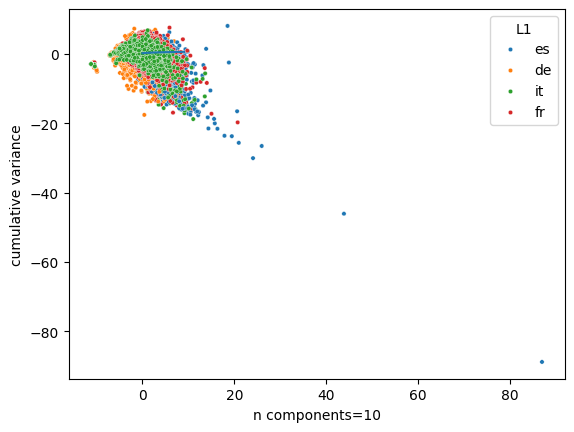

In [98]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X = StandardScaler().fit_transform(df[num_cols])
pca = PCA(n_components=10).fit(X)
plt.plot(pca.explained_variance_ratio_.cumsum()); plt.xlabel('n components=10'); plt.ylabel('cumulative variance')
pc2 = PCA(n_components=2).fit_transform(X)
sns.scatterplot(x=pc2[:,0], y=pc2[:,1], hue=df['L1'], s=10)


<Axes: xlabel='n components=10', ylabel='cumulative variance'>

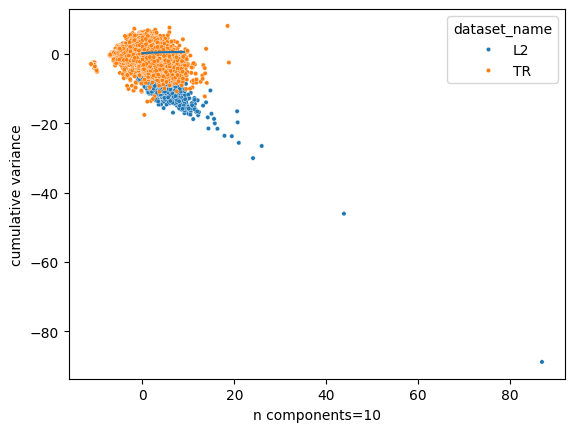

In [99]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X = StandardScaler().fit_transform(df[num_cols])
pca = PCA(n_components=10).fit(X)
plt.plot(pca.explained_variance_ratio_.cumsum()); plt.xlabel('n components=10'); plt.ylabel('cumulative variance')
pc2 = PCA(n_components=2).fit_transform(X)
sns.scatterplot(x=pc2[:,0], y=pc2[:,1], hue=df['dataset_name'], s=10)


#Analysis of Numerical columns

In [31]:
df.describe().T  # numeric overview: mean, std, min, max


,count,mean,std,min,25%,50%,75%,max
sentlength,142540.0,26.794046,8.114647,4.000000,22.266667,26.000000,30.571429,353.000000
ppron,142540.0,0.012159,0.014187,0.000000,0.002899,0.008333,0.017167,0.400000
possdet,142540.0,0.006168,0.007254,0.000000,0.000000,0.004266,0.009132,0.200000
indef,142540.0,0.000207,0.001348,0.000000,0.000000,0.000000,0.000000,0.111111
cconj,142540.0,0.867213,0.518171,0.000000,0.545455,0.800000,1.117647,14.000000
whconj,142540.0,0.033960,0.074458,0.000000,0.000000,0.000000,0.047619,2.000000
relativ,142540.0,0.183717,0.208065,0.000000,0.000000,0.133333,0.263158,7.500000
pied,142540.0,0.016104,0.048912,0.000000,0.000000,0.000000,0.000000,1.000000
correl,142540.0,0.000058,0.003049,0.000000,0.000000,0.000000,0.000000,0.500000
copula,142540.0,0.272293,0.227488,0.000000,0.117647,0.250000,0.379310,9.000000


#Correlation Matrix

<Axes: >

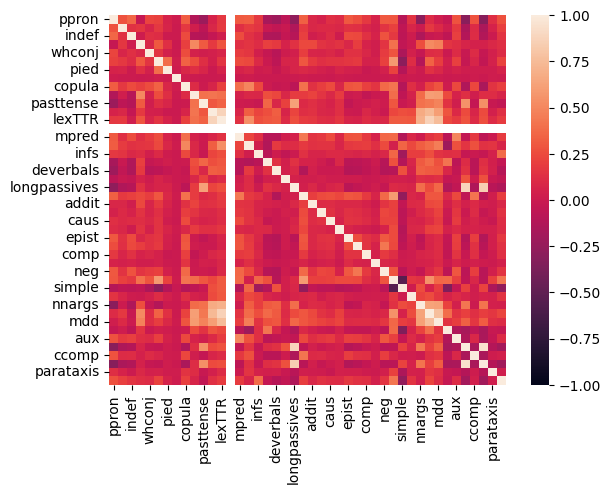

In [100]:
corr = df.select_dtypes('number').corr()
import seaborn as sns
sns.heatmap(corr, vmin=-1, vmax=1)


#Distribution of features

## distribution of features by L2 & TR

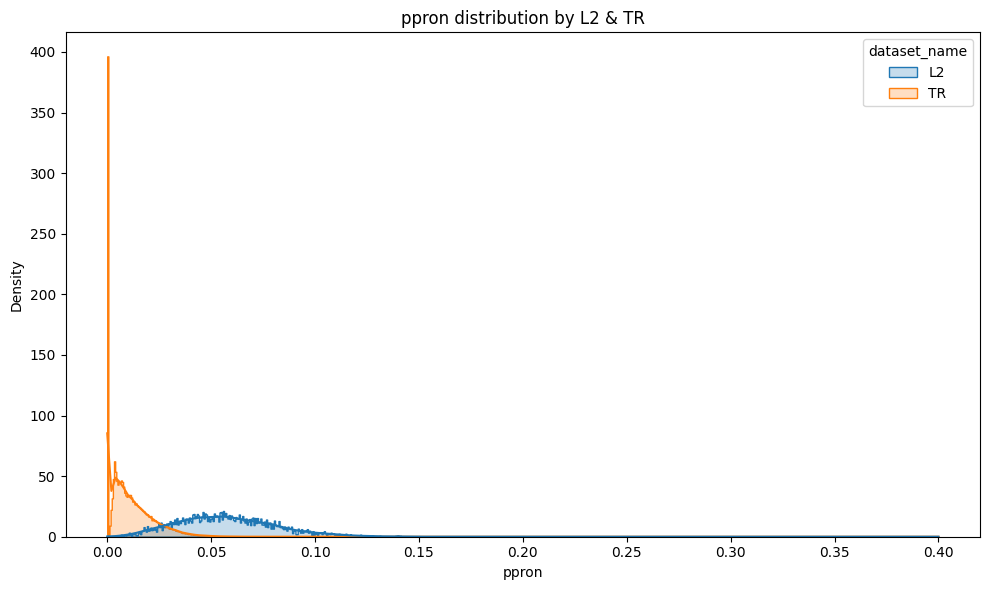

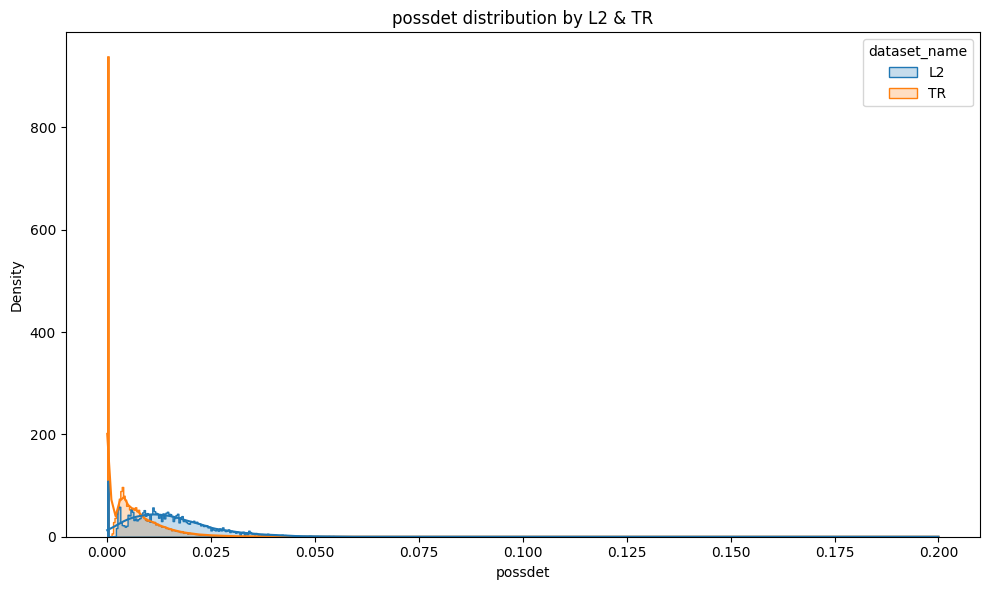

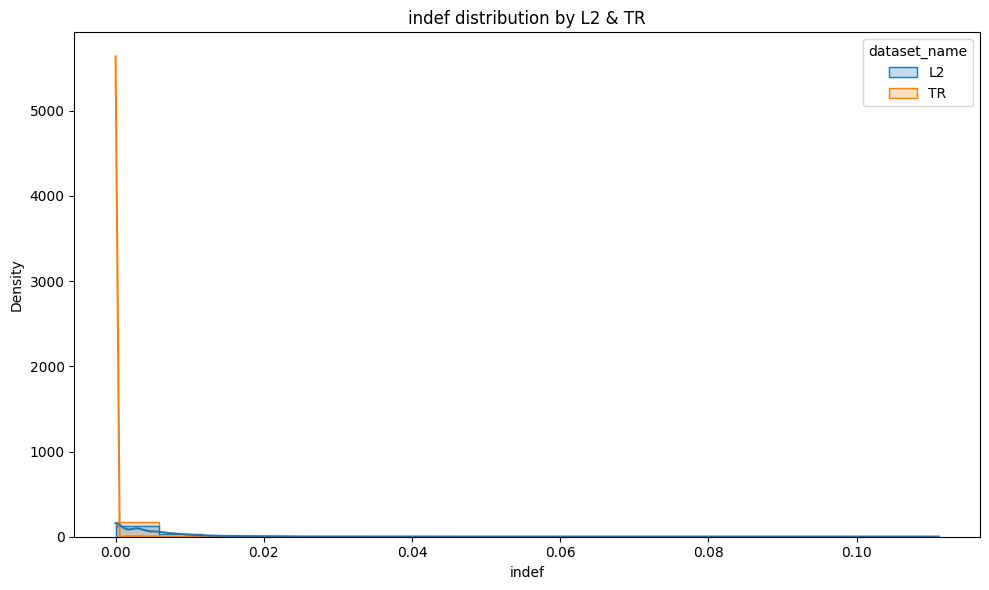

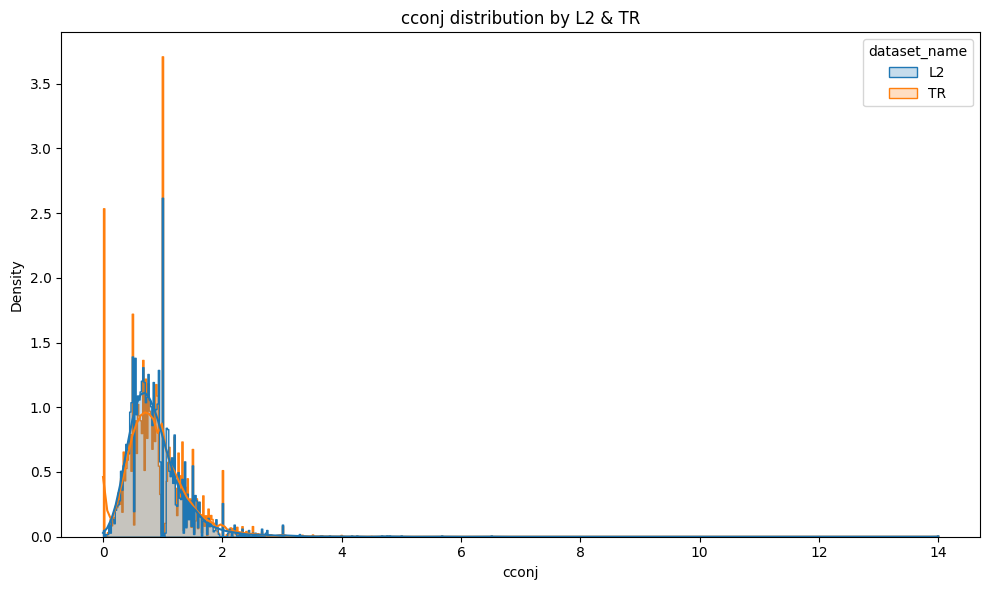

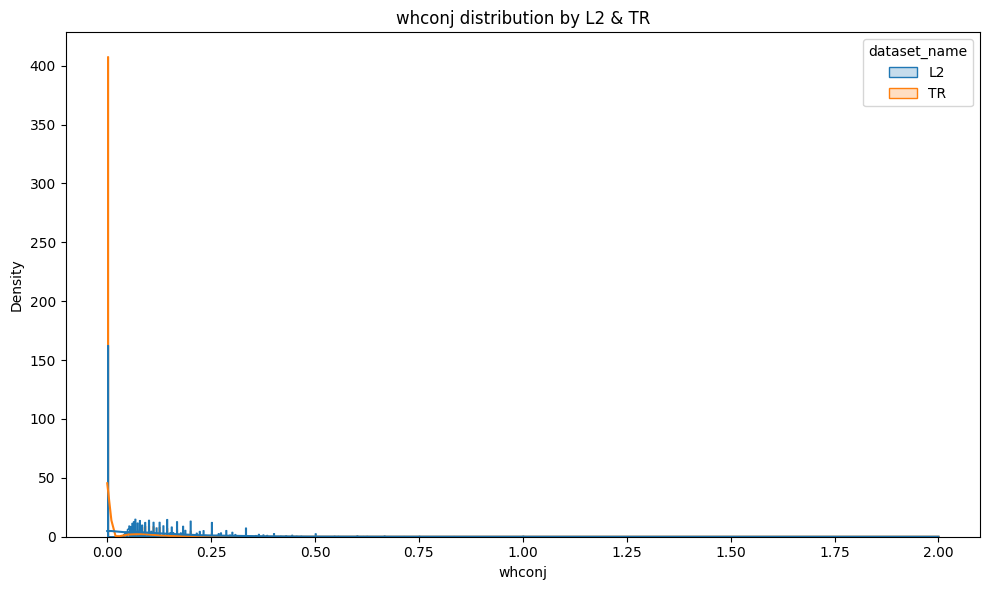

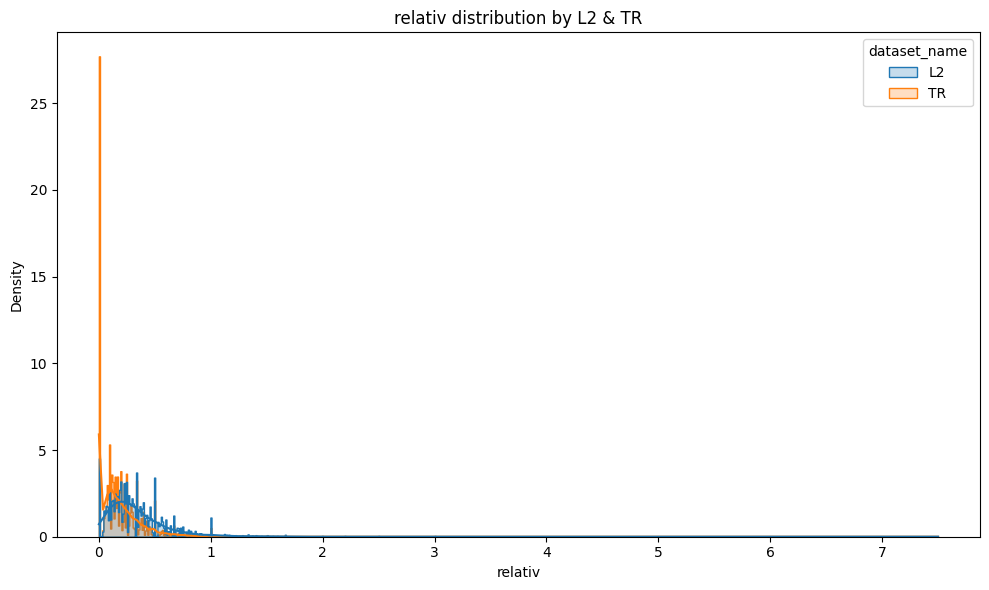

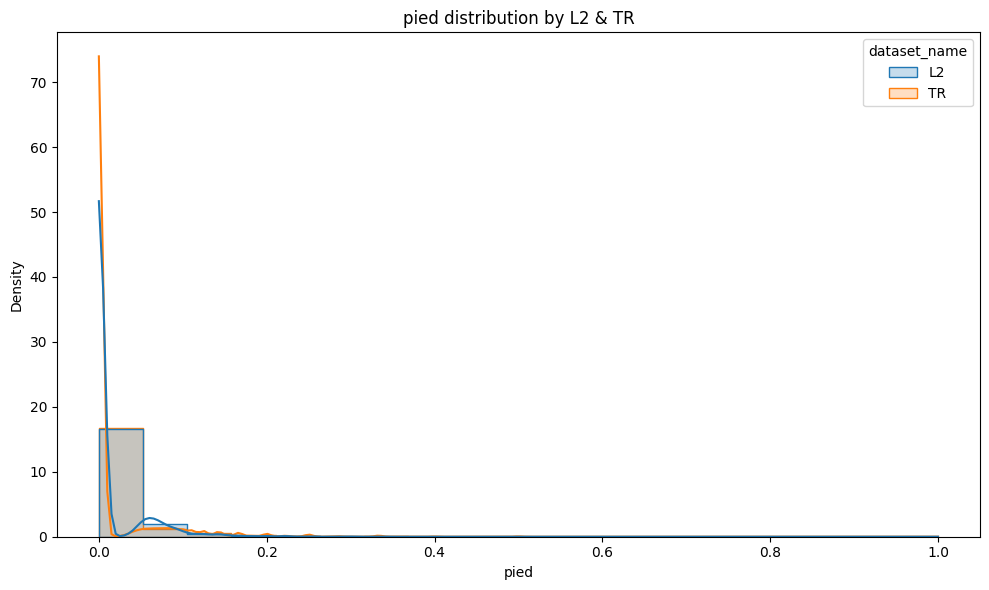

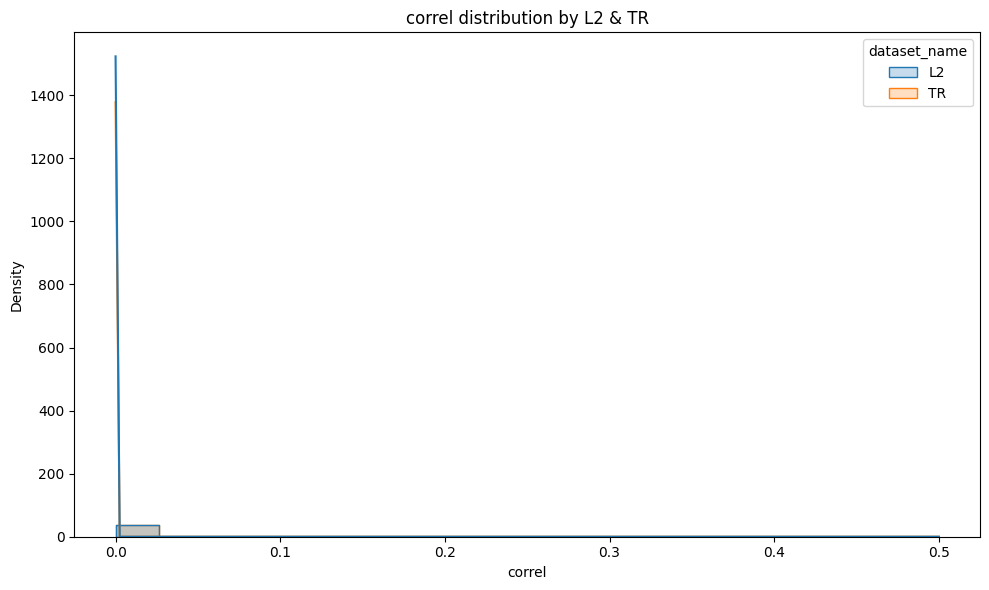

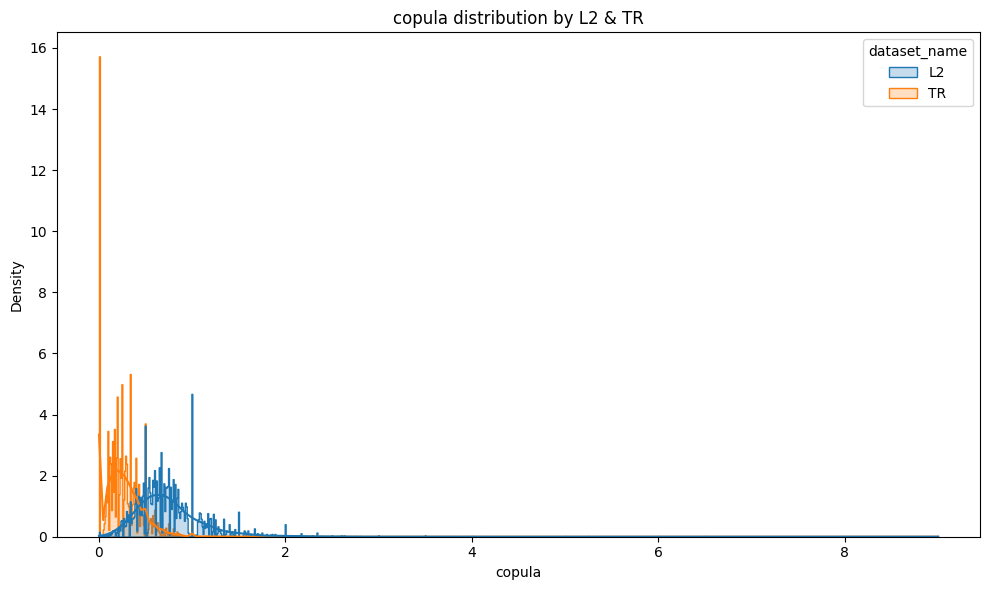

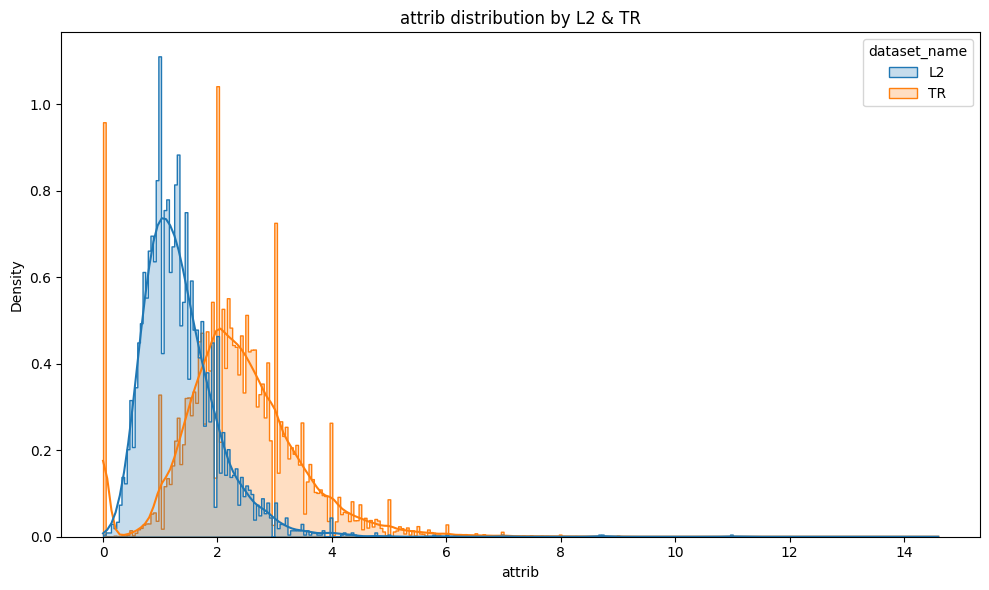

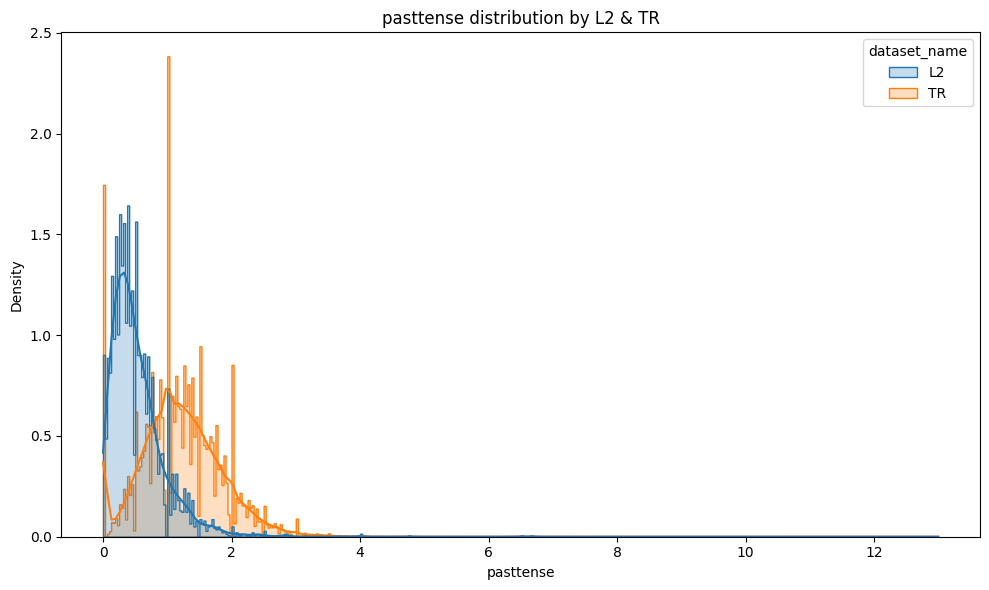

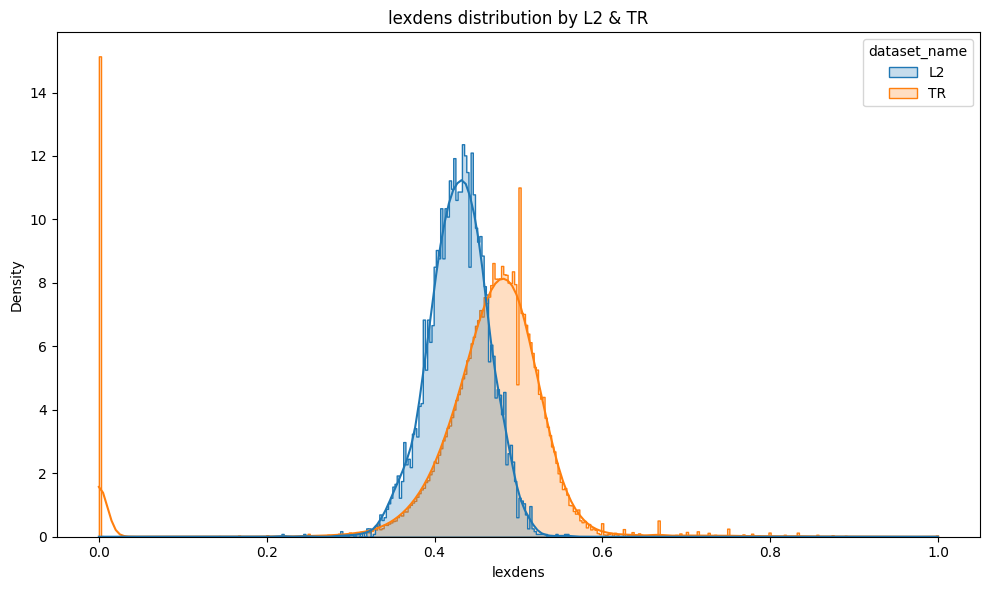

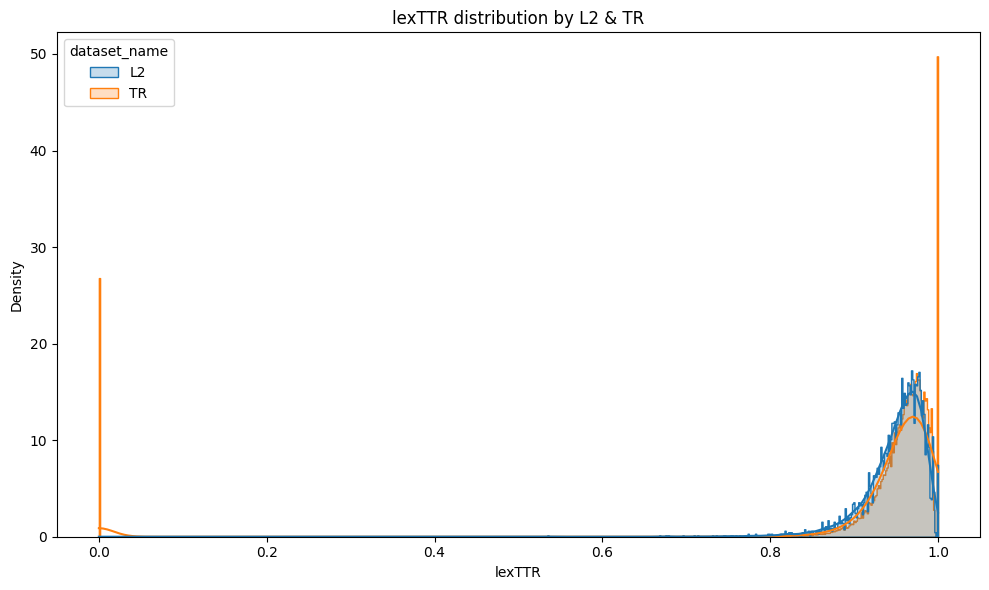

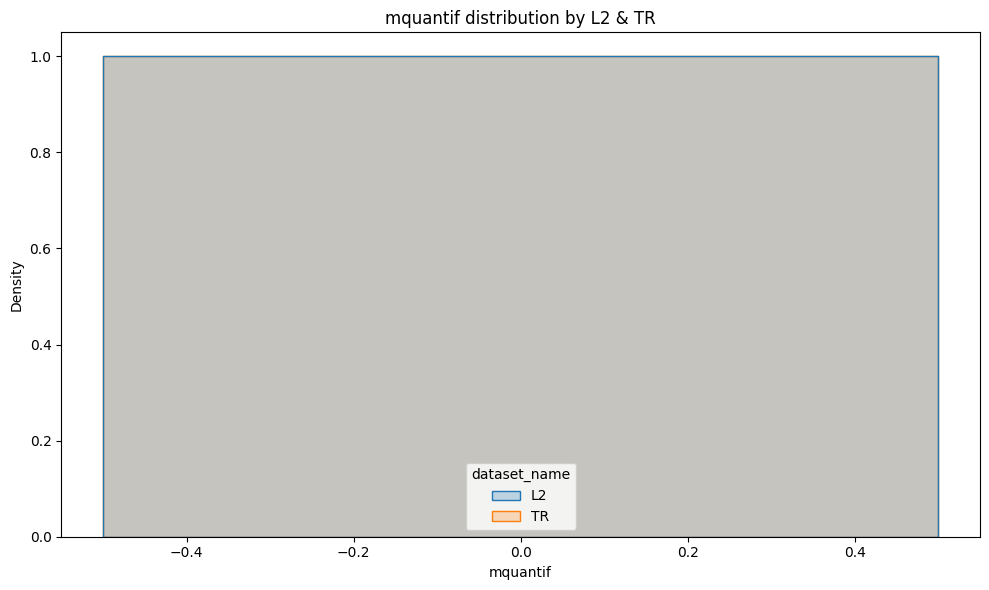

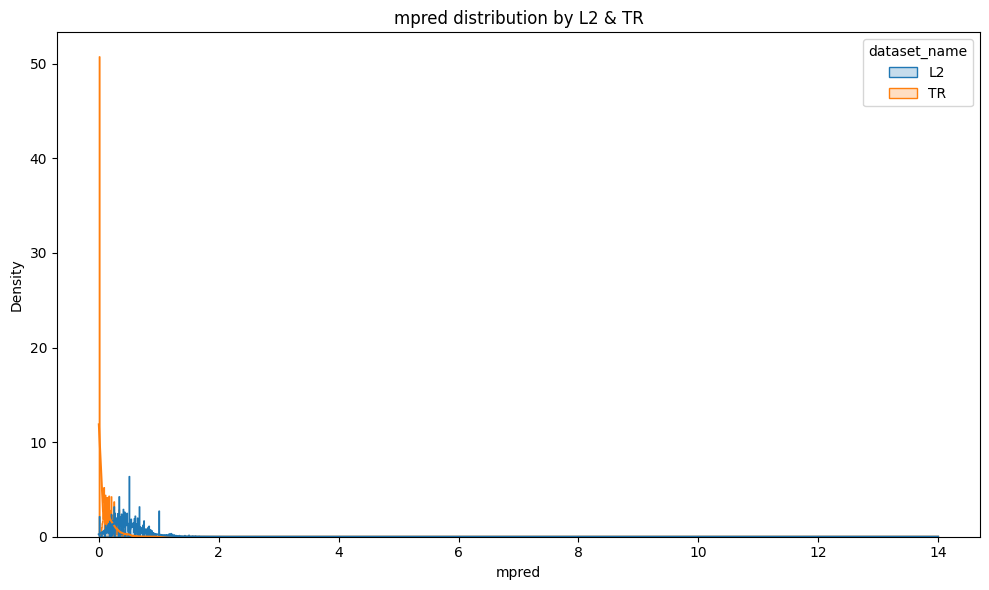

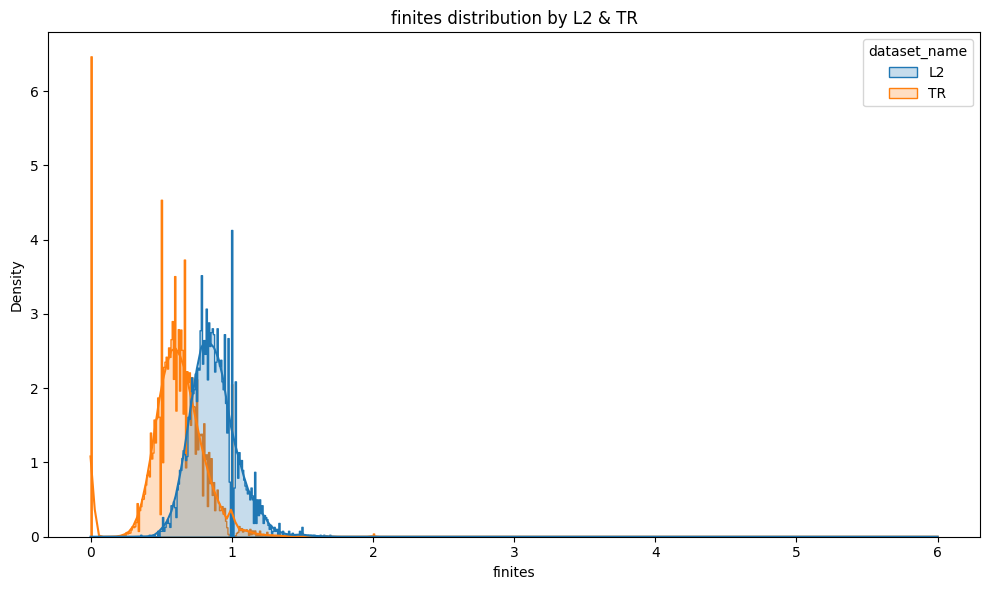

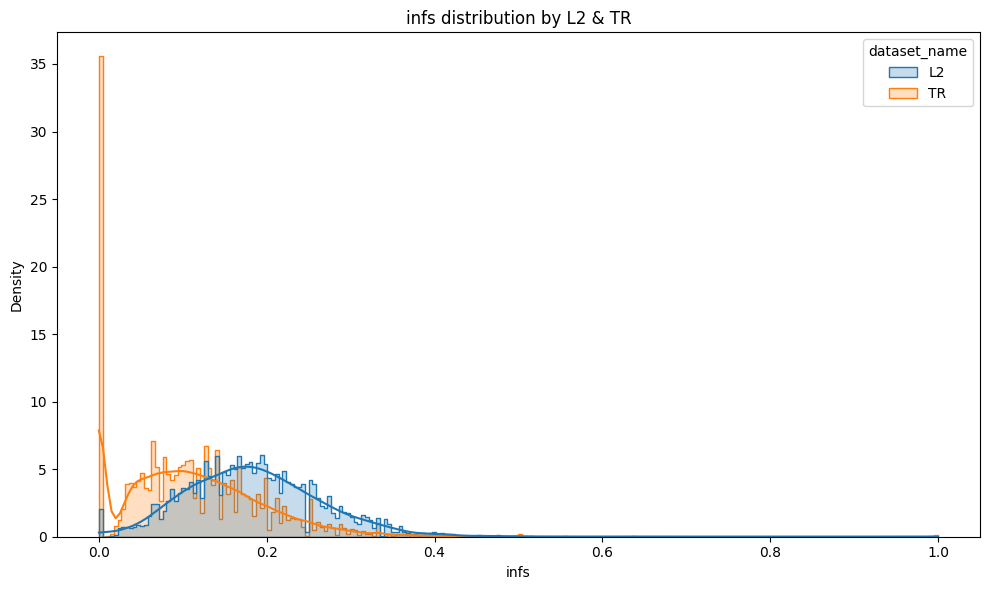

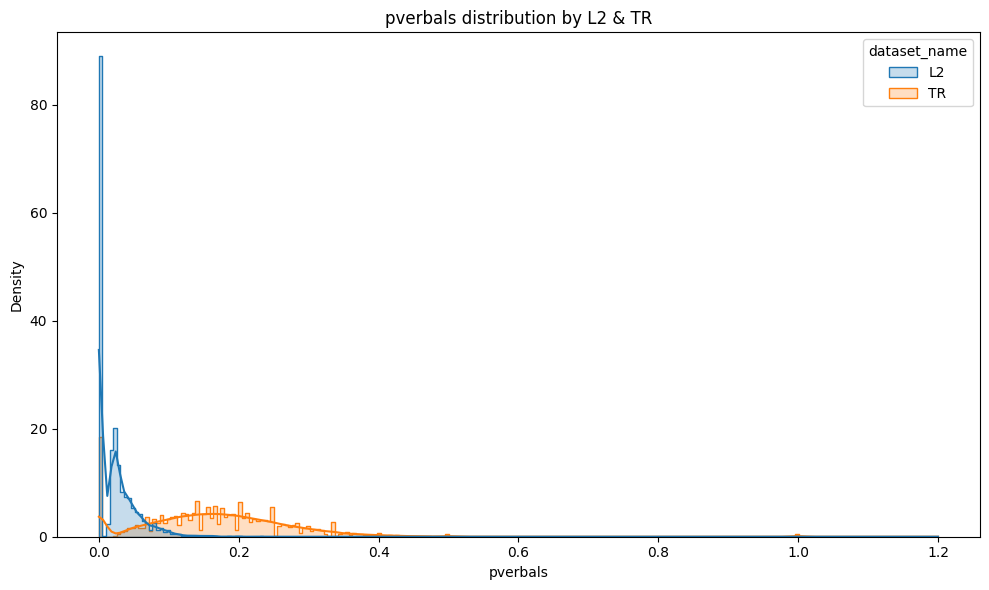

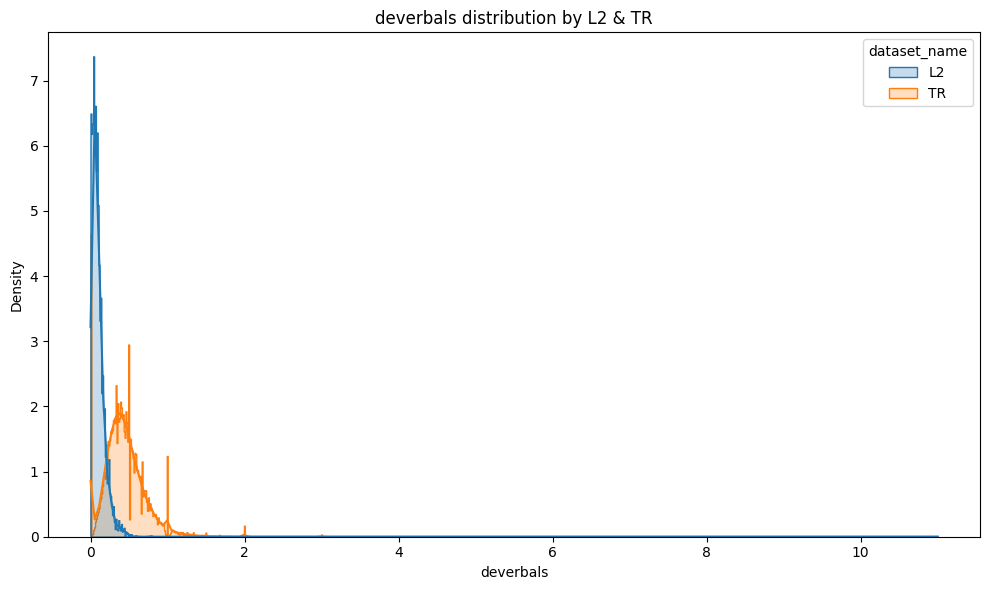

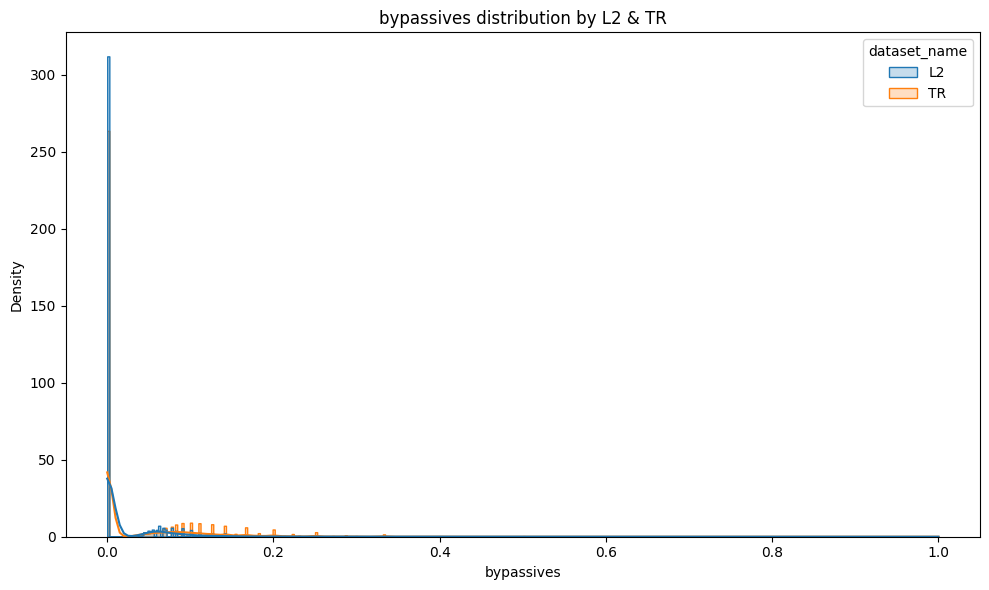

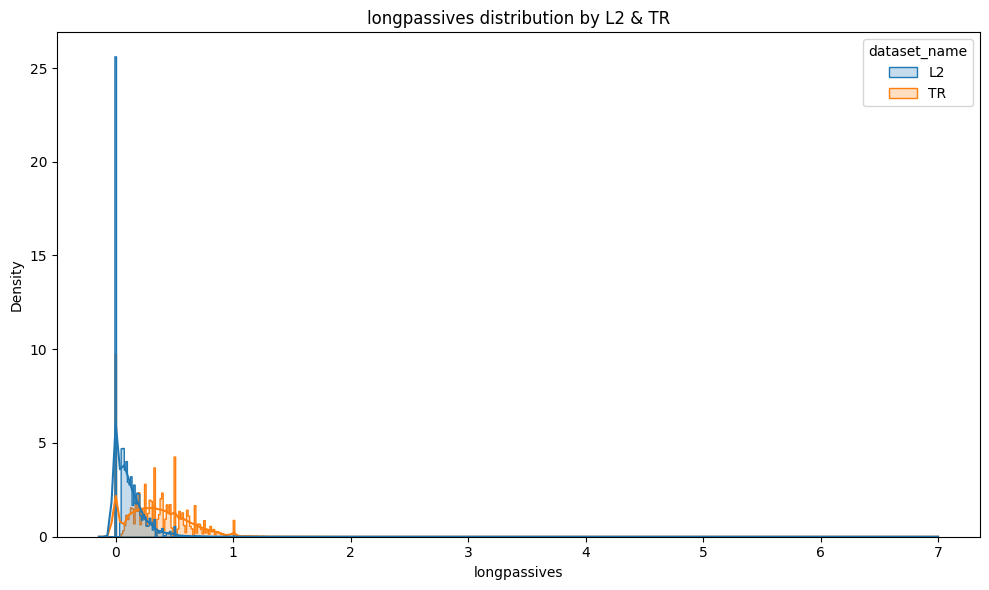

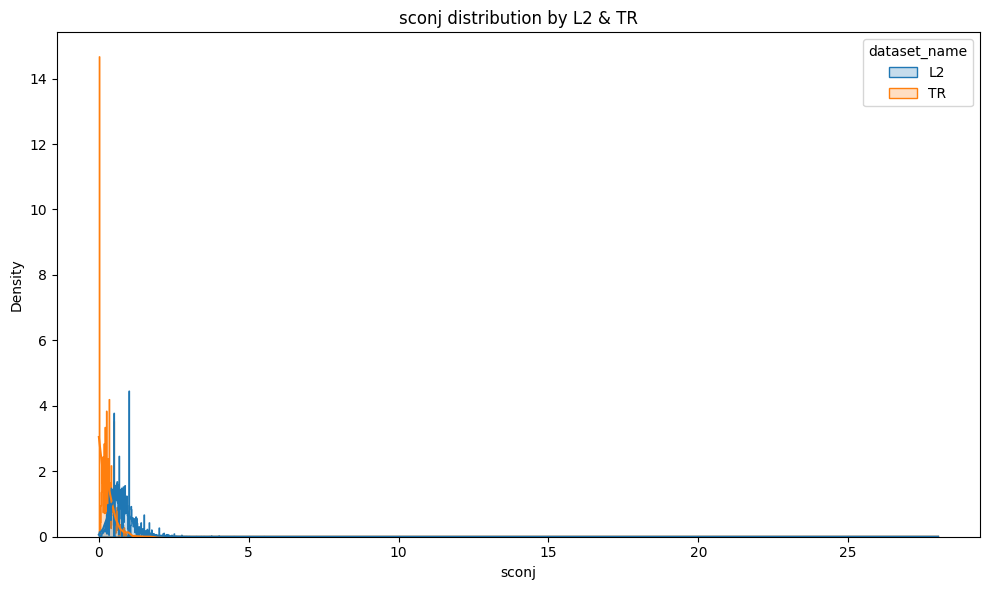

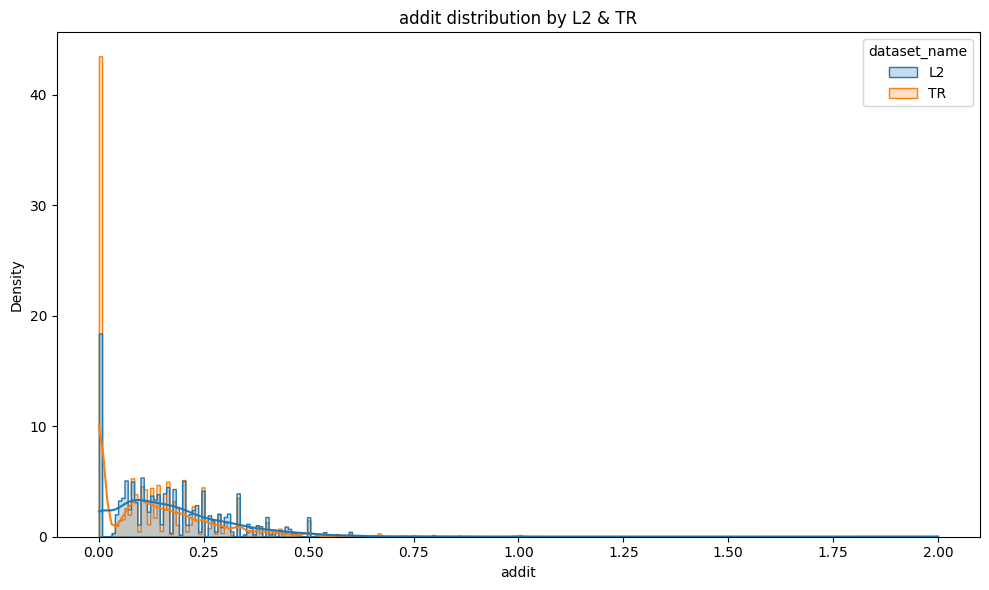

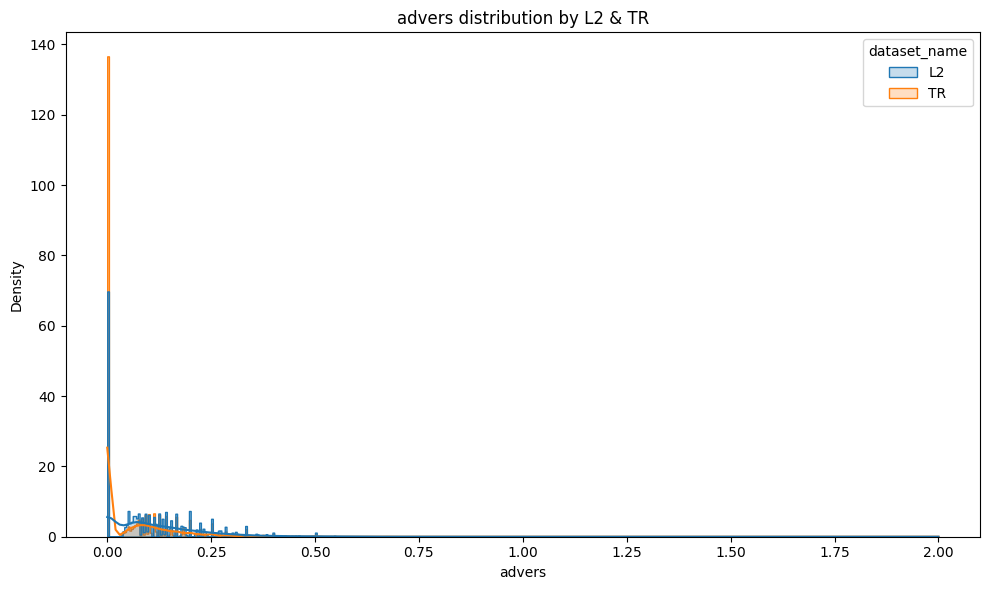

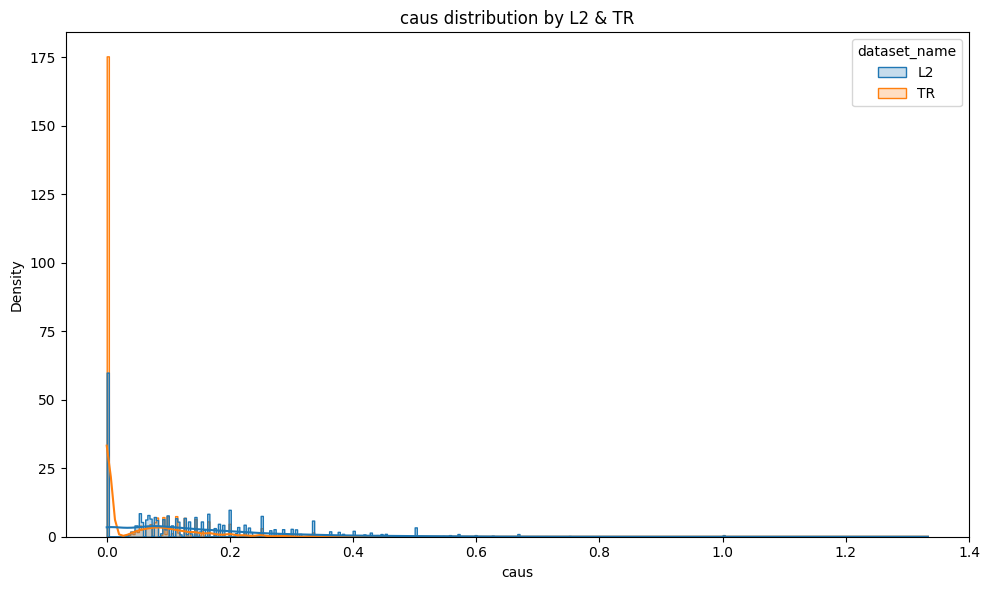

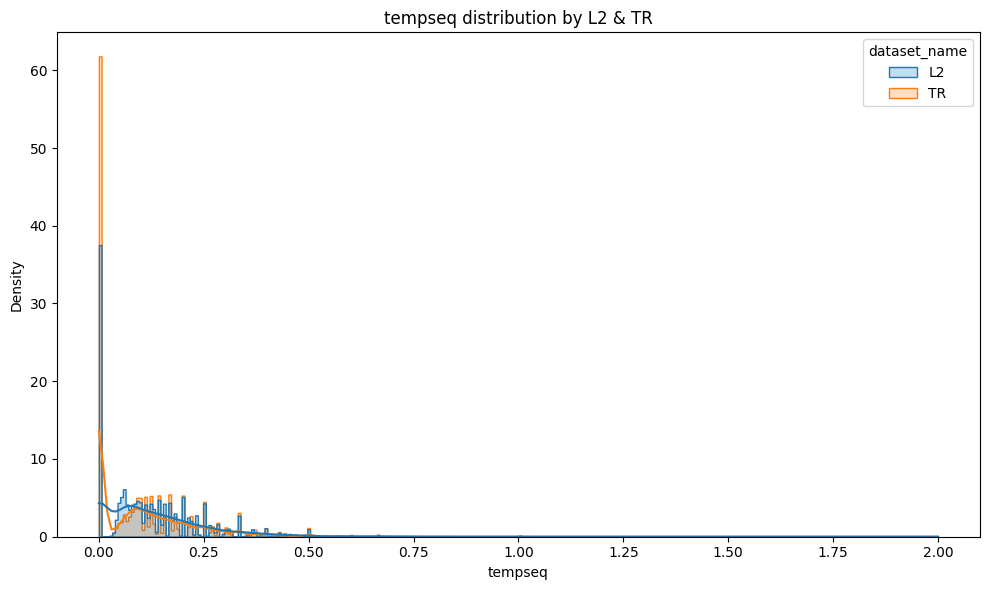

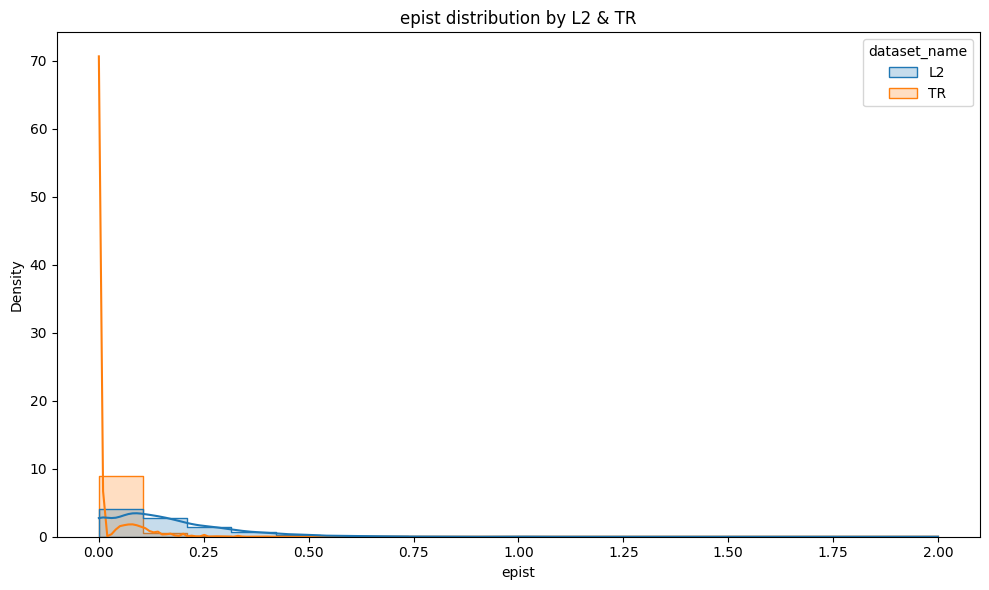

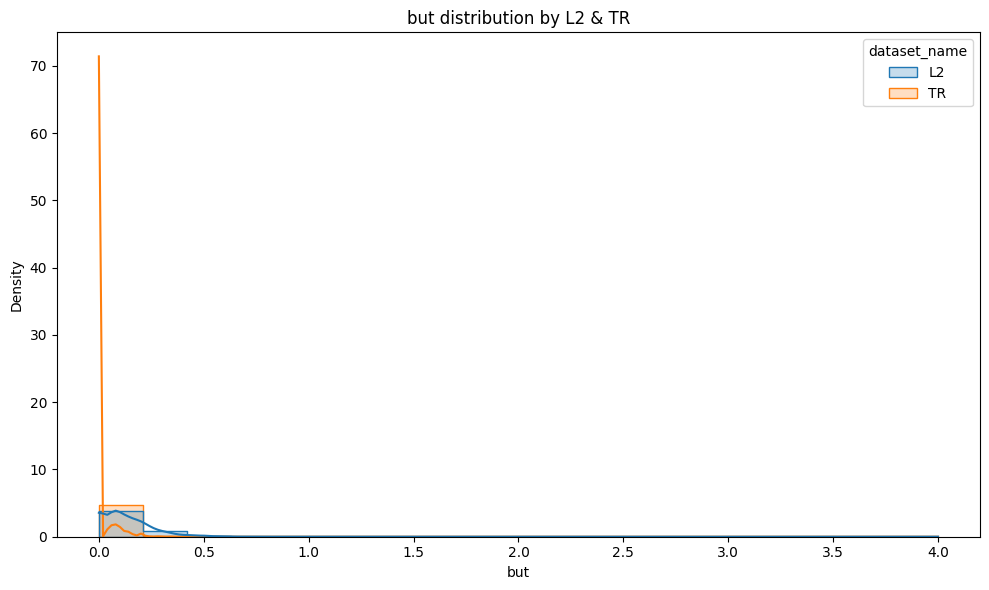

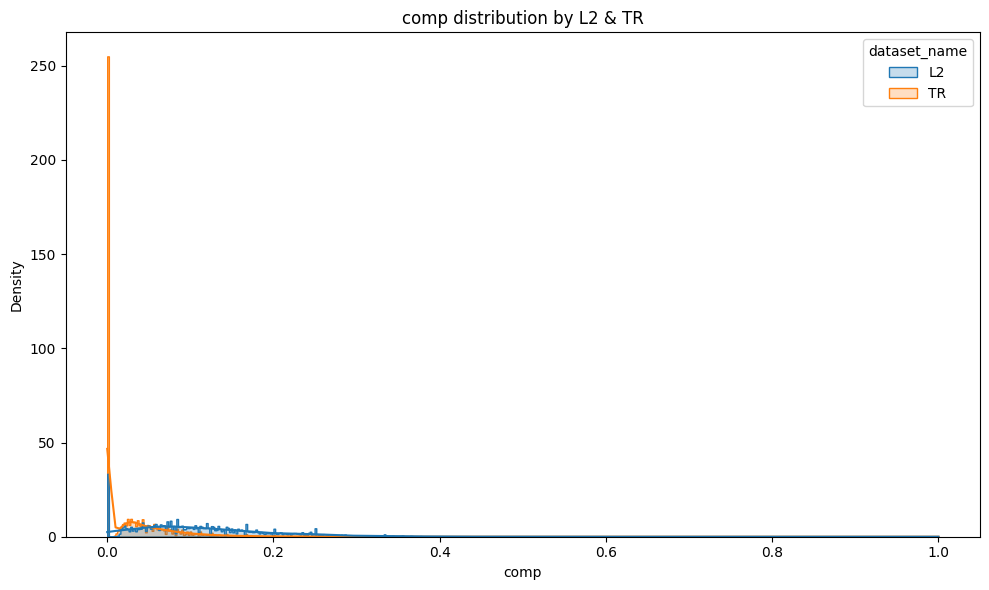

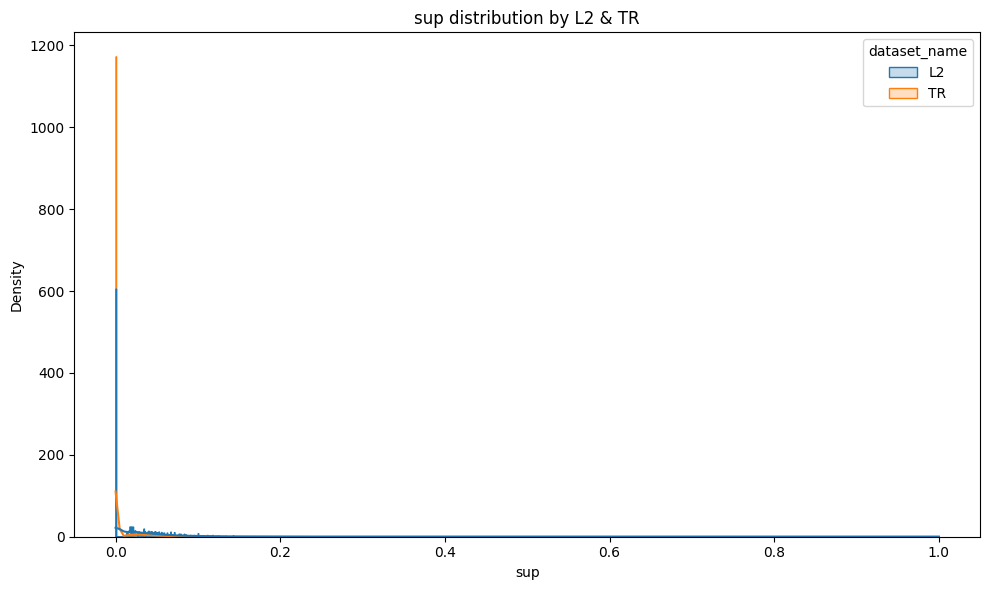

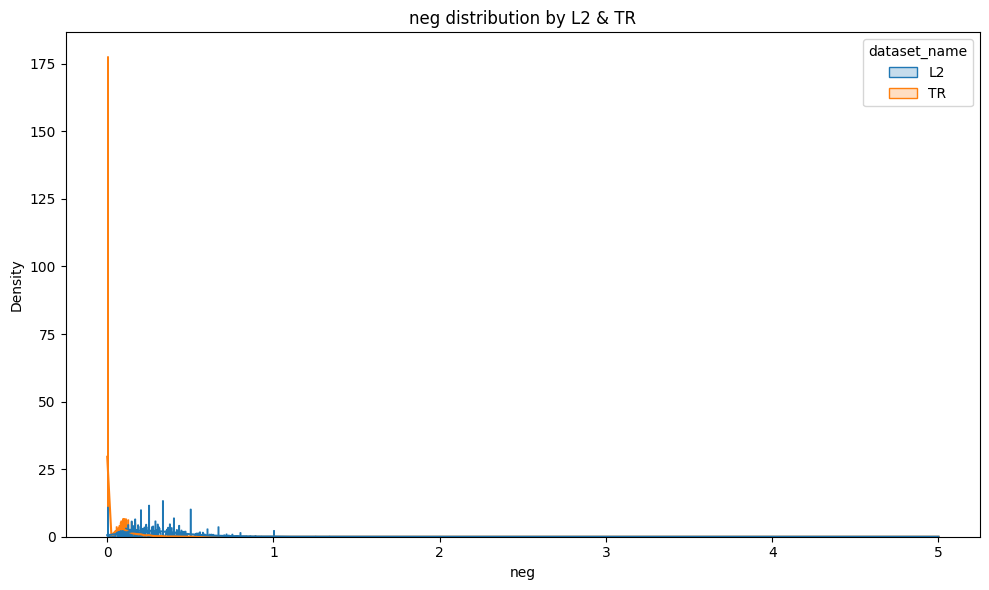

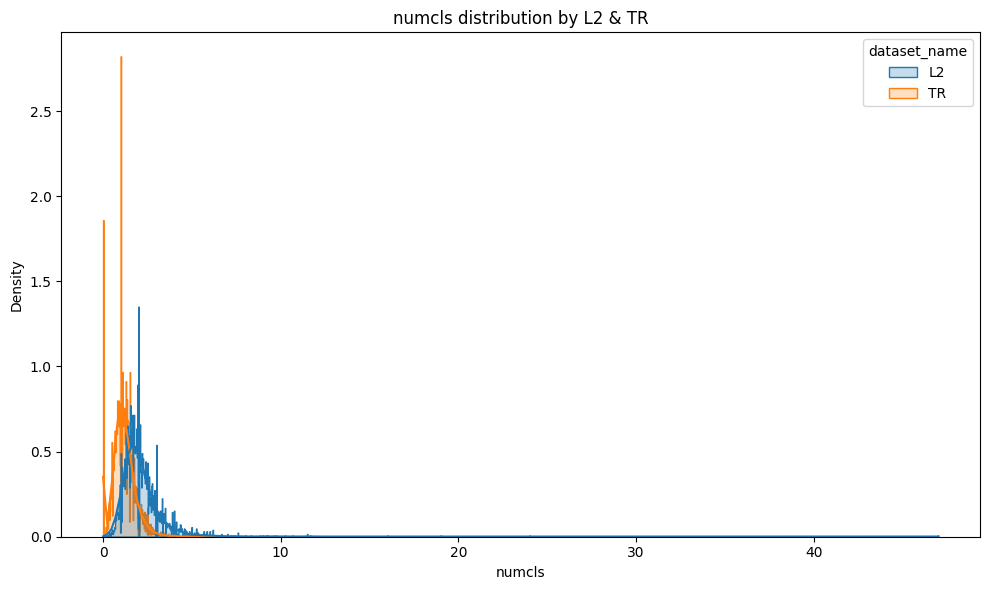

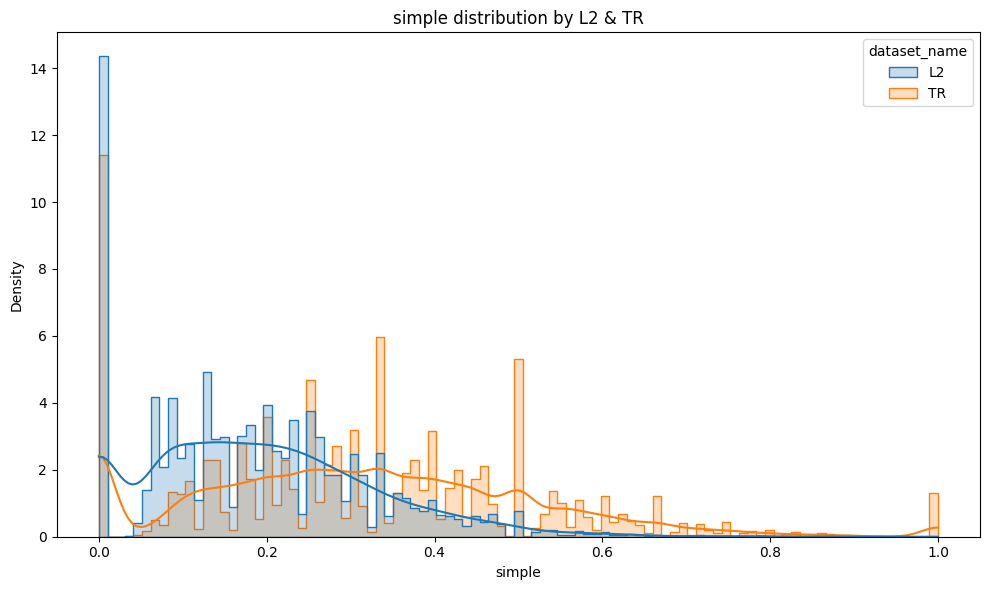

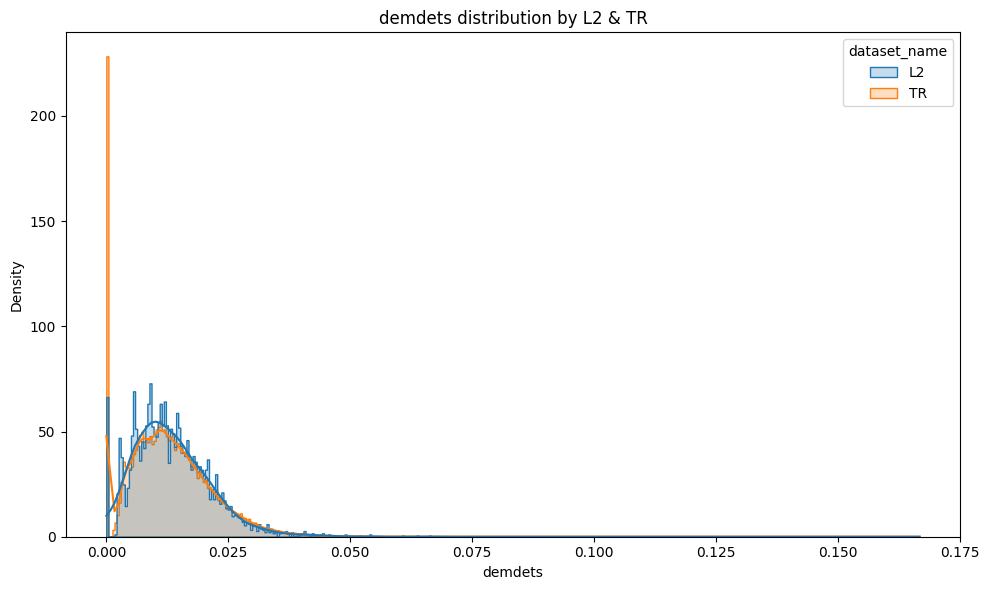

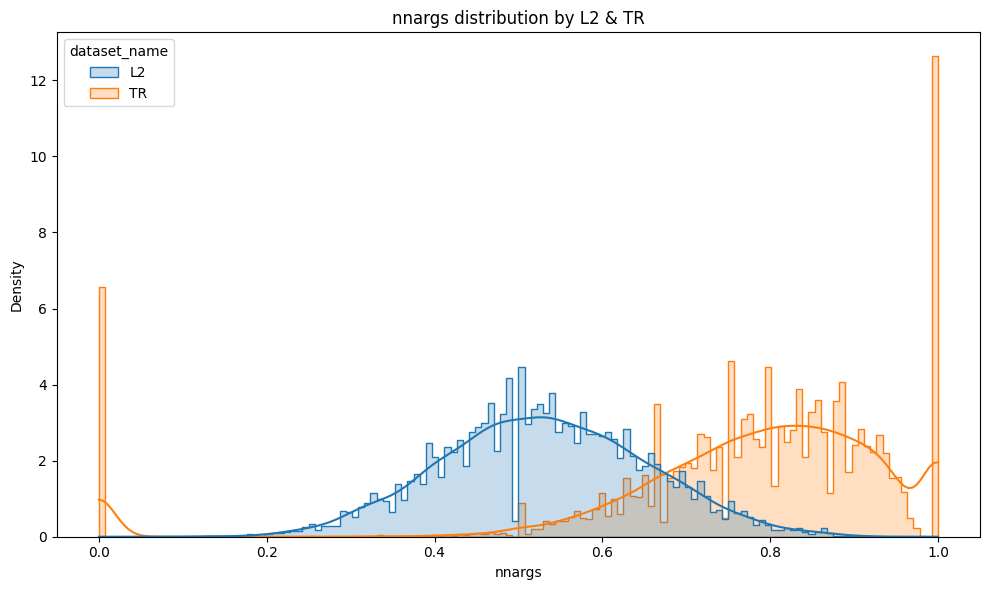

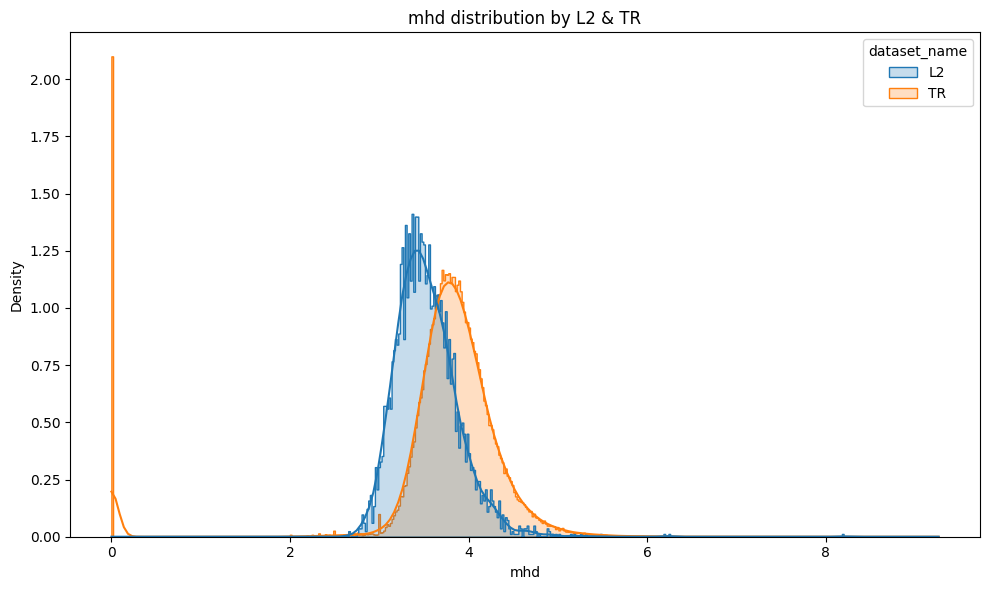

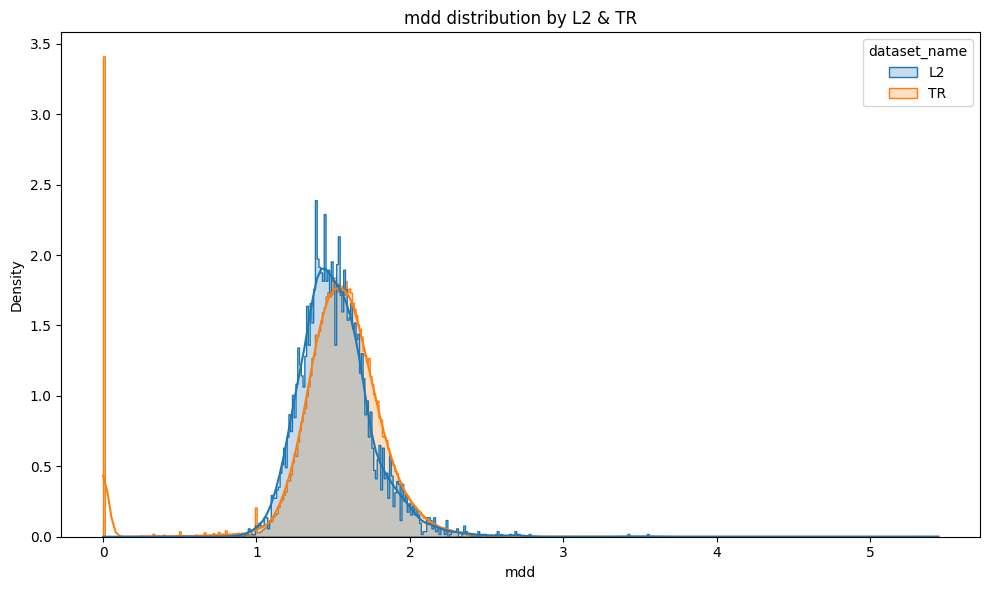

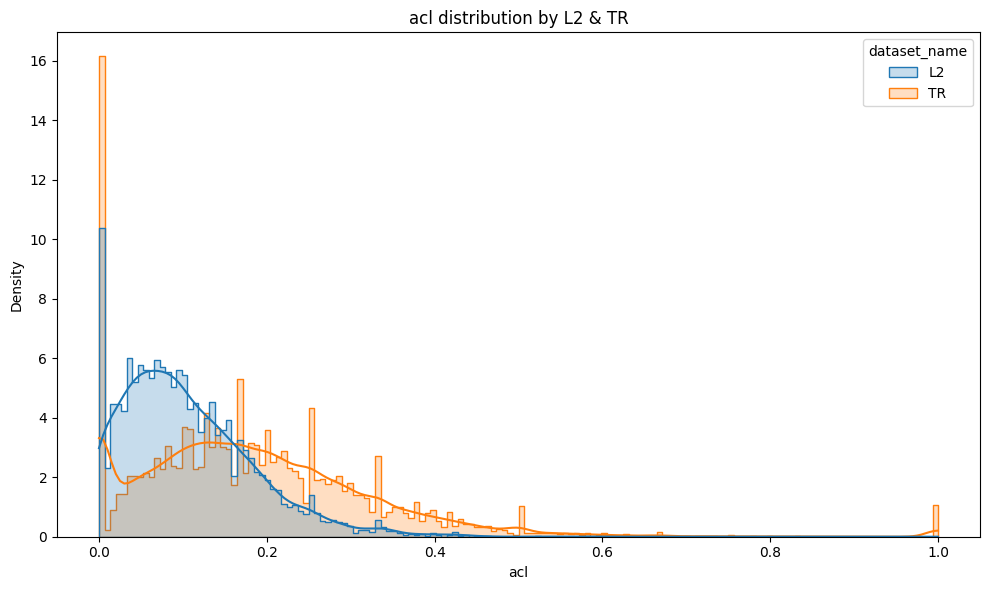

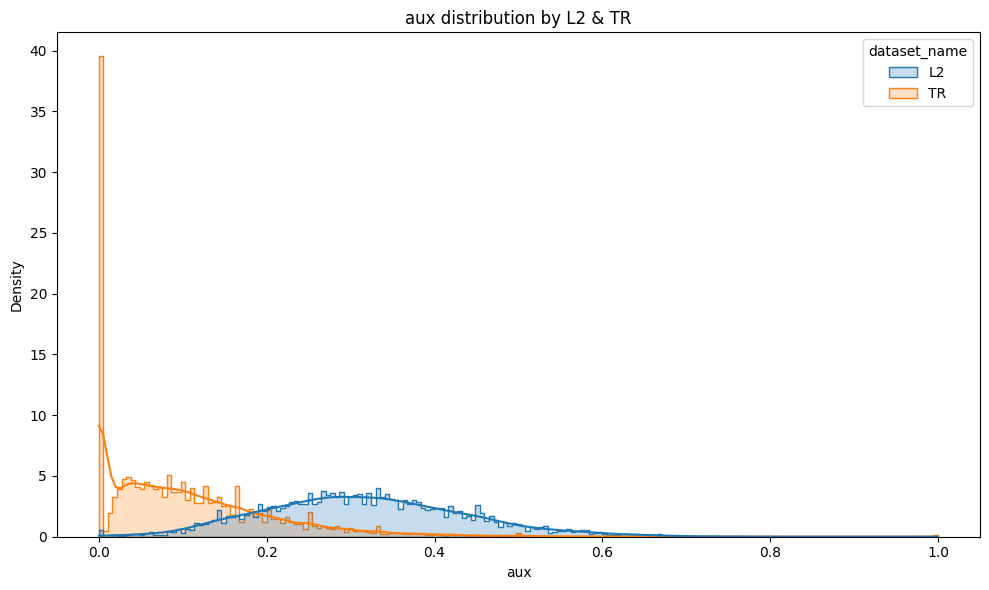

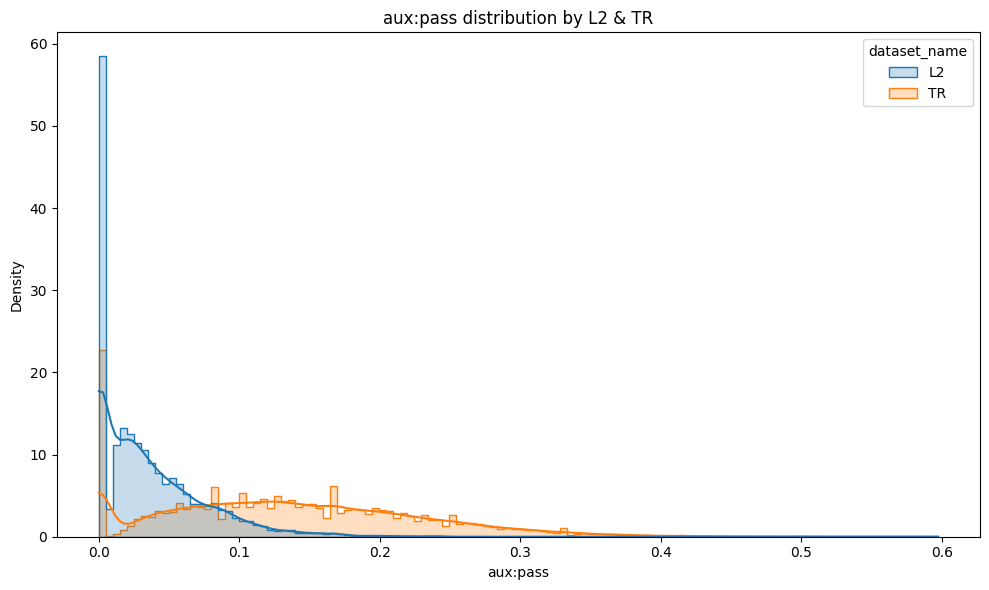

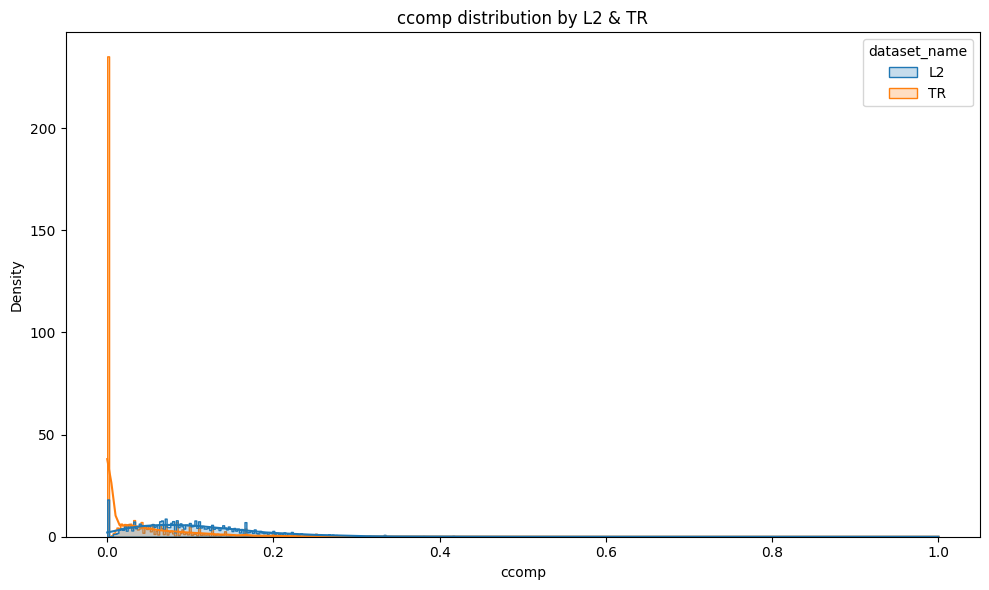

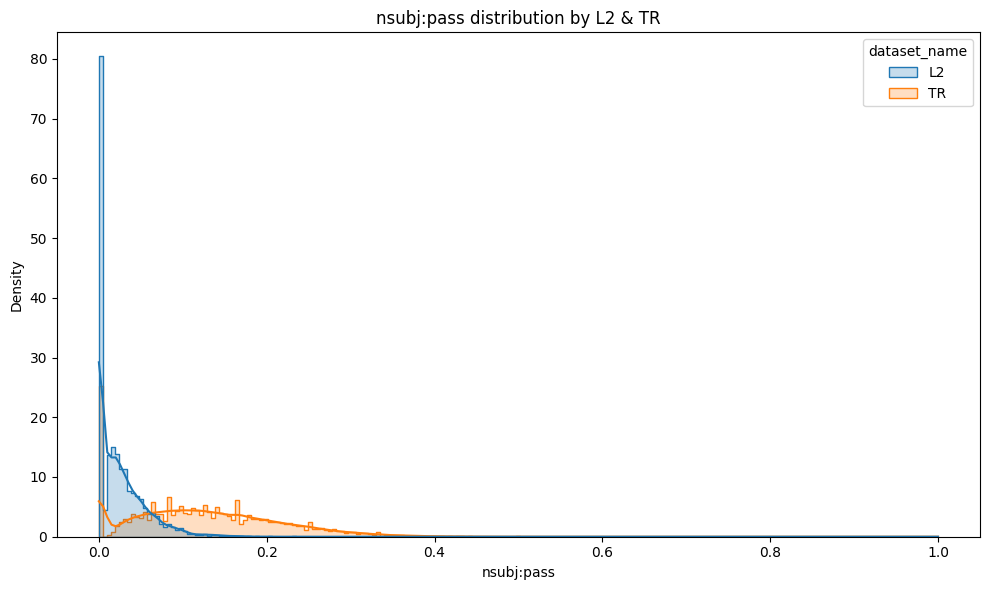

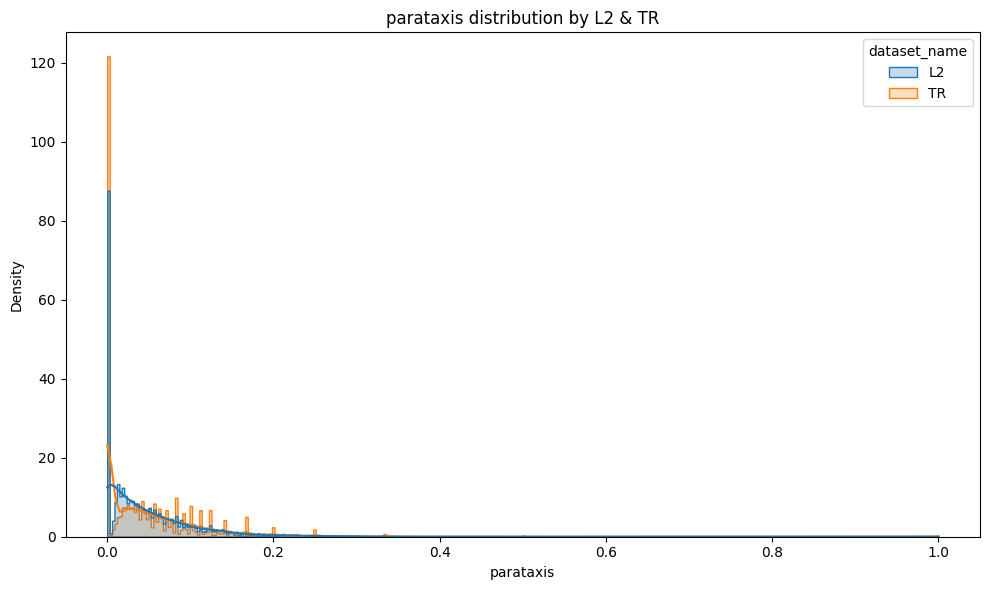

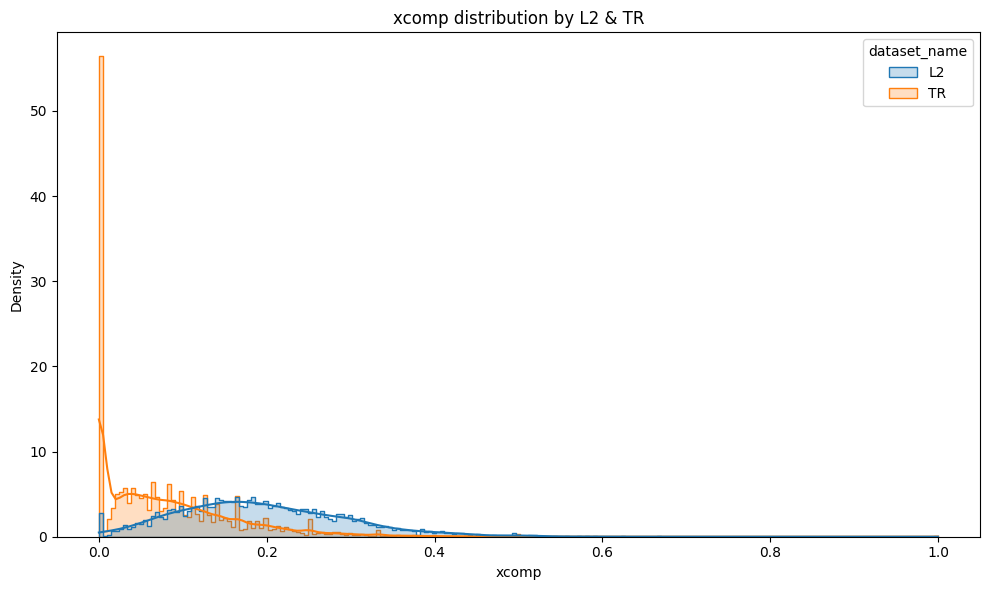

All plots saved and zipped as plots.zip


In [101]:

import os
import zipfile

# only the languages you want
dataset_groups = ["L2","TR"]

plot_dir = "plots_L2_vs_TR"
os.makedirs(plot_dir, exist_ok=True)

for col in num_cols:
    plt.figure(figsize=(10, 6))
    try:
      sns.histplot(
          data=df[df["dataset_name"].isin(dataset_groups)],
          x=col,
          hue="dataset_name",
          kde=True,
          element="step",
          stat="density",
          common_norm=False,
          label = dataset_groups
      )
    except:
      sns.histplot(
          data=df[df["dataset_name"].isin(dataset_groups)],
          x=col,
          hue="dataset_name",
          element="step",
          stat="density",
          common_norm=False,
          label = dataset_groups
      )

    plt.title(f"{col} distribution by L2 & TR")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{col}.png"))
    plt.show()

df = df.drop("dataset_name", axis = 'columns')



# 4️⃣ Create a ZIP file containing all plots
zip_filename = "plots.zip"
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for root, dirs, files in os.walk(plot_dir):
        for file in files:
            zipf.write(os.path.join(root, file), arcname=file)

print(f"All plots saved and zipped as {zip_filename}")

##Distribution of features by L1

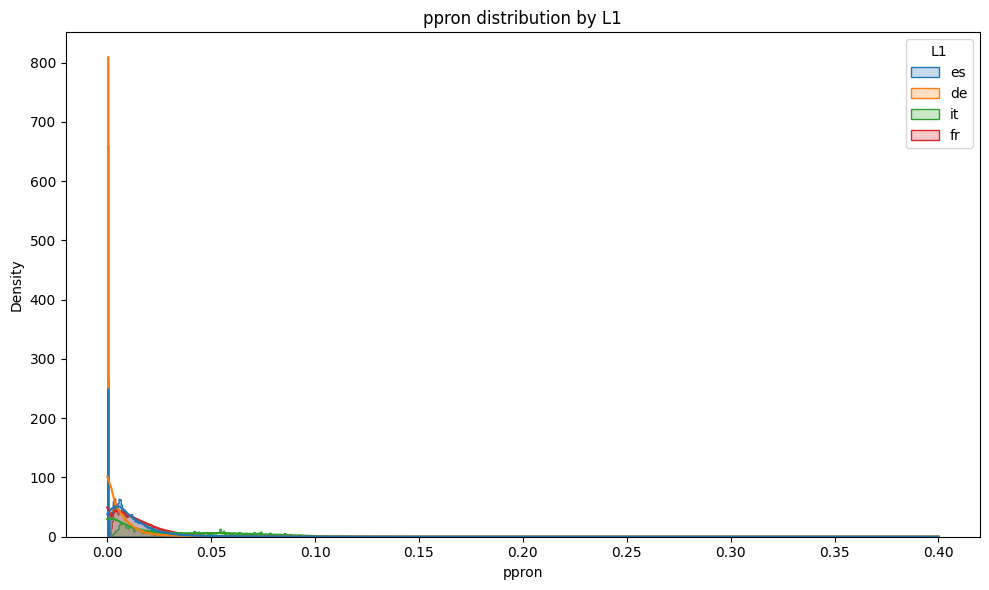

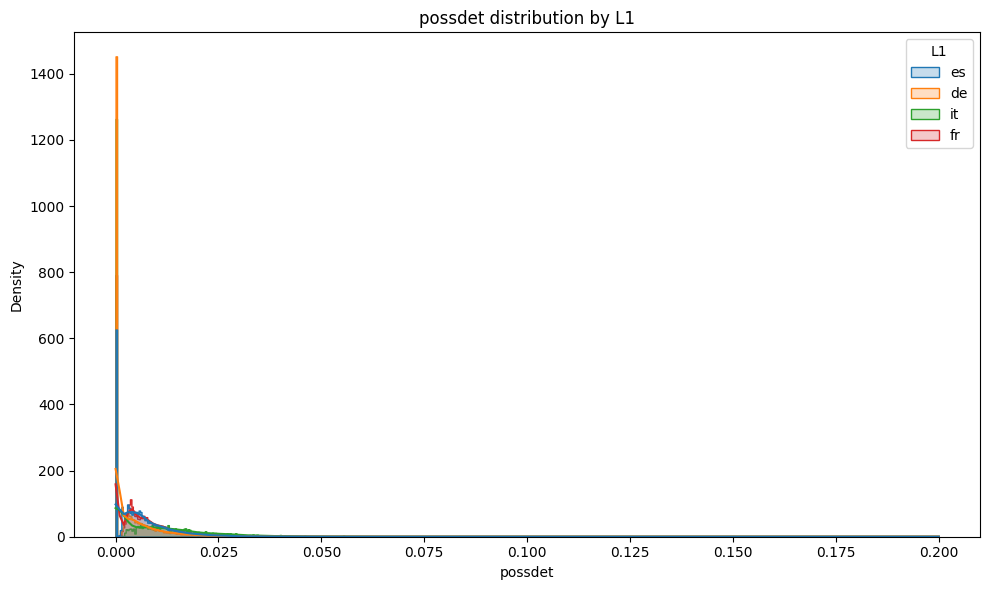

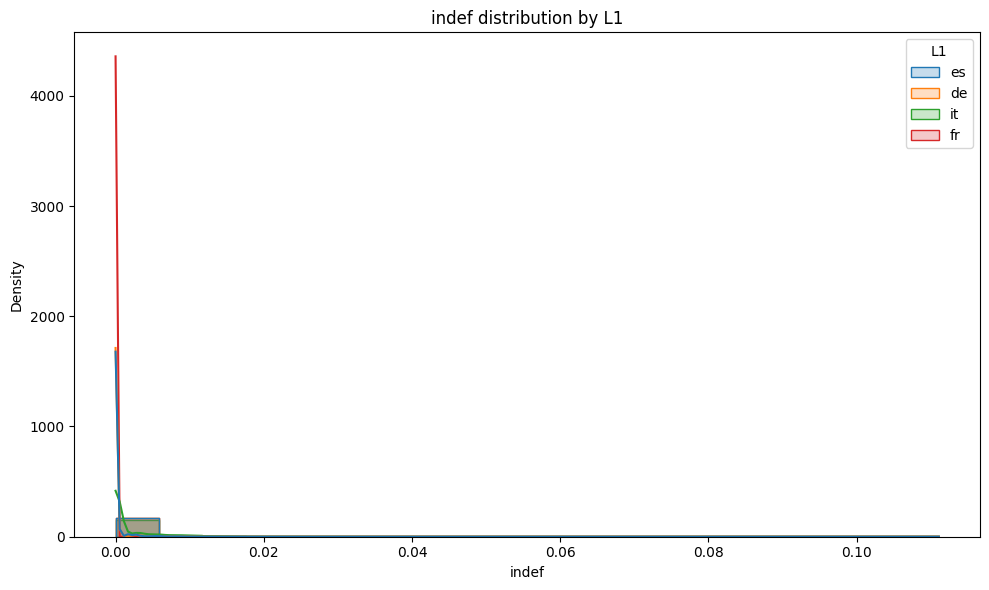

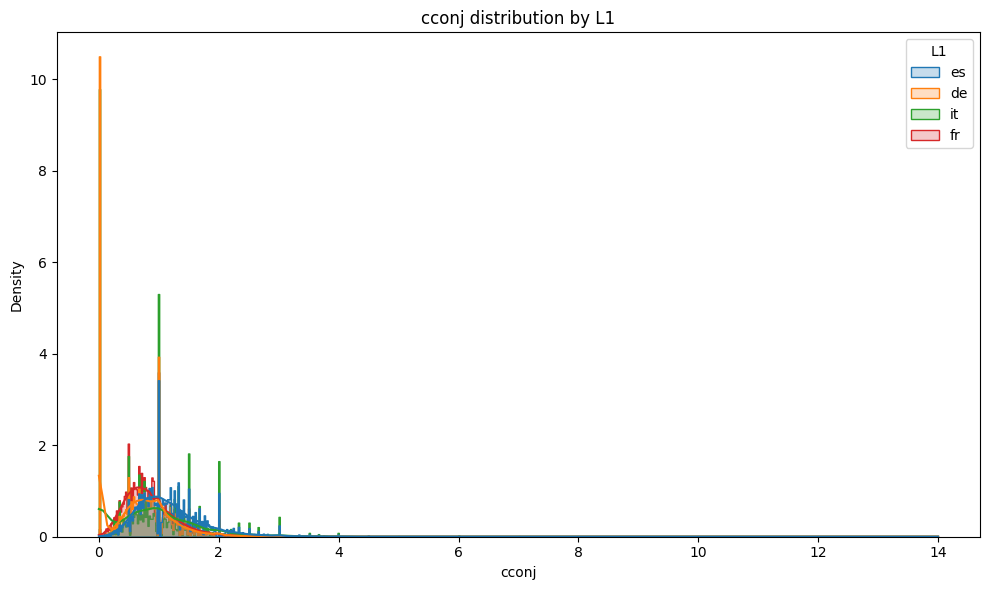

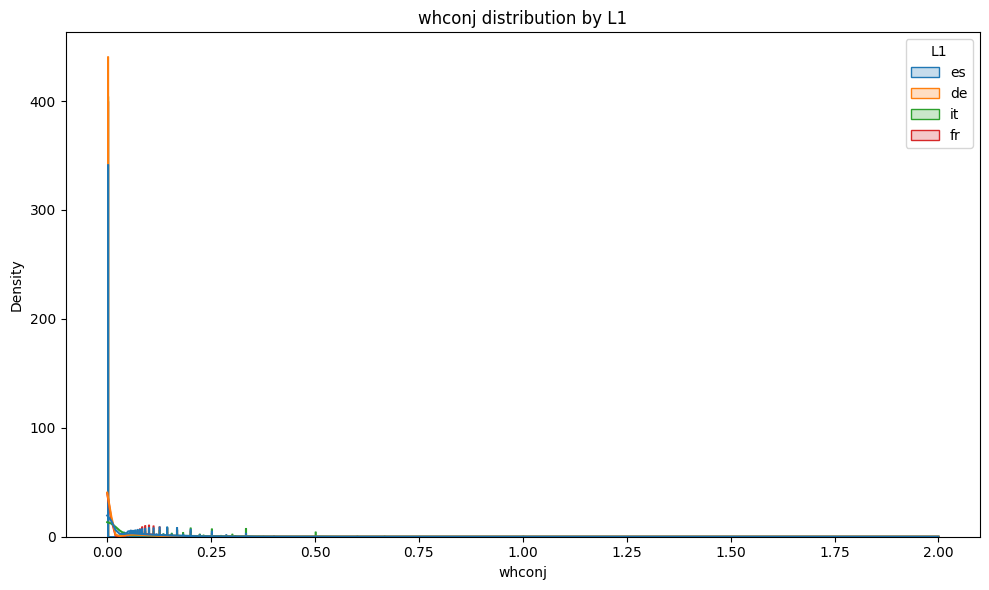

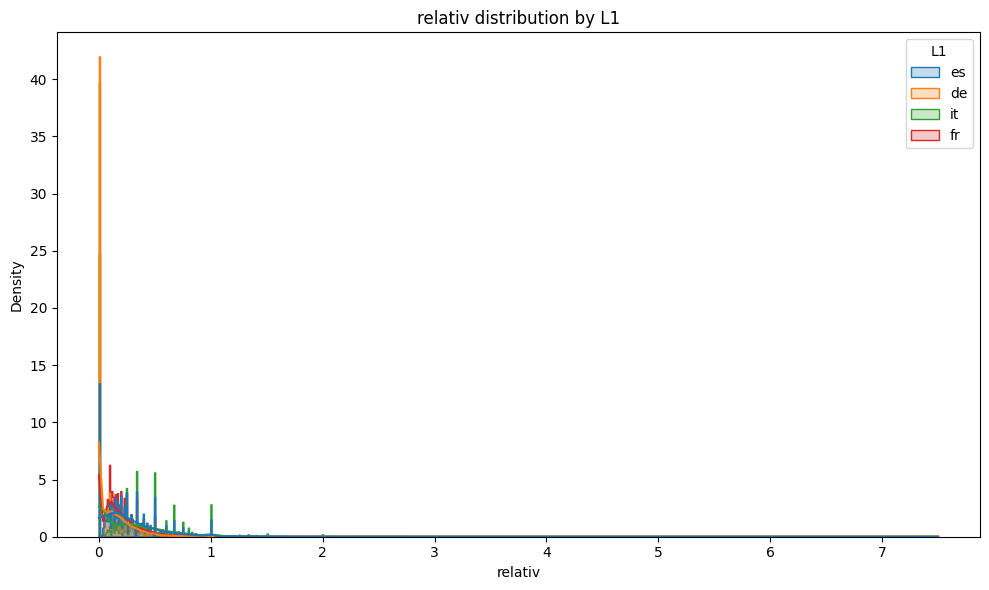

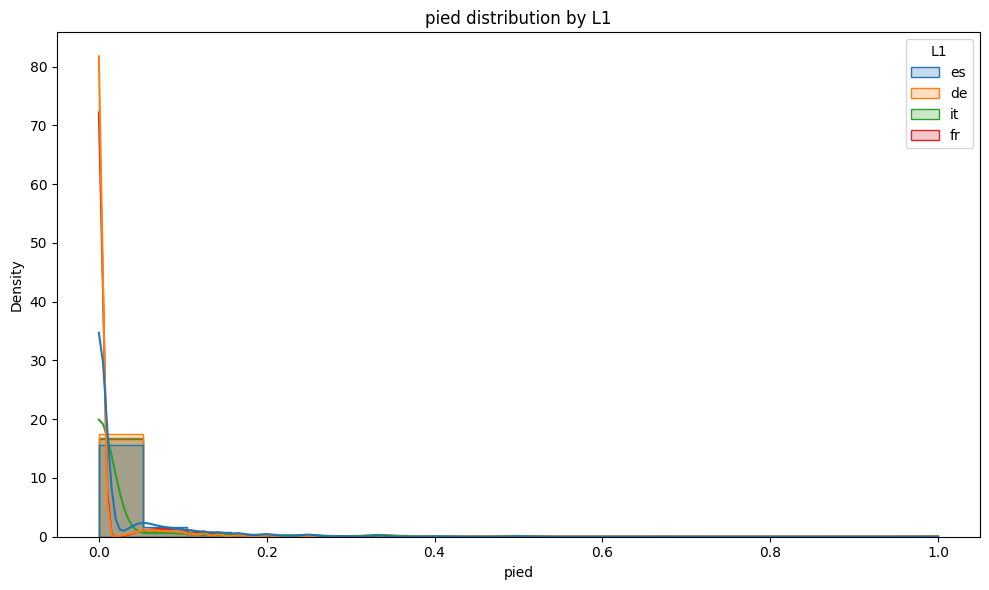

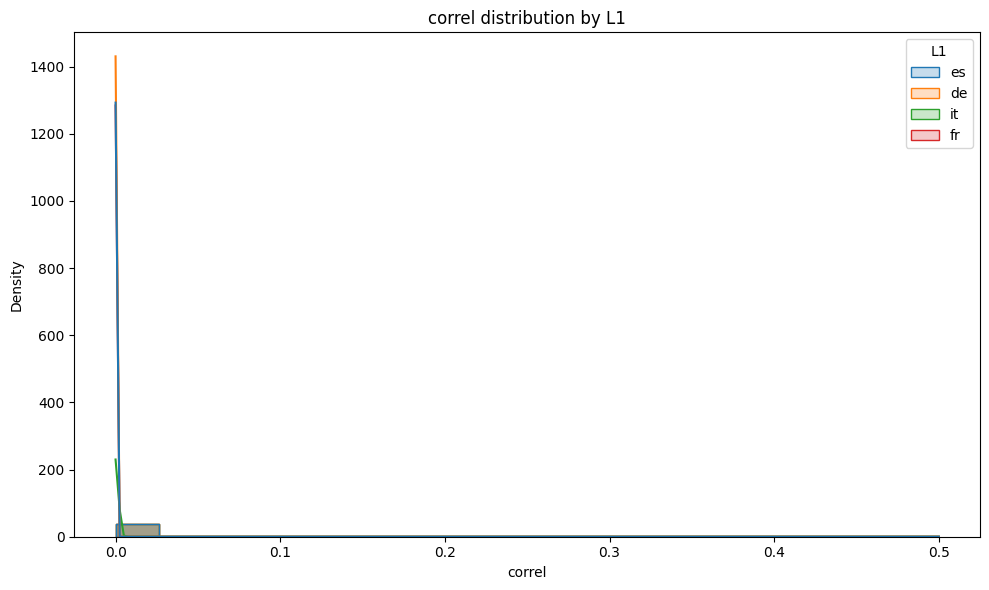

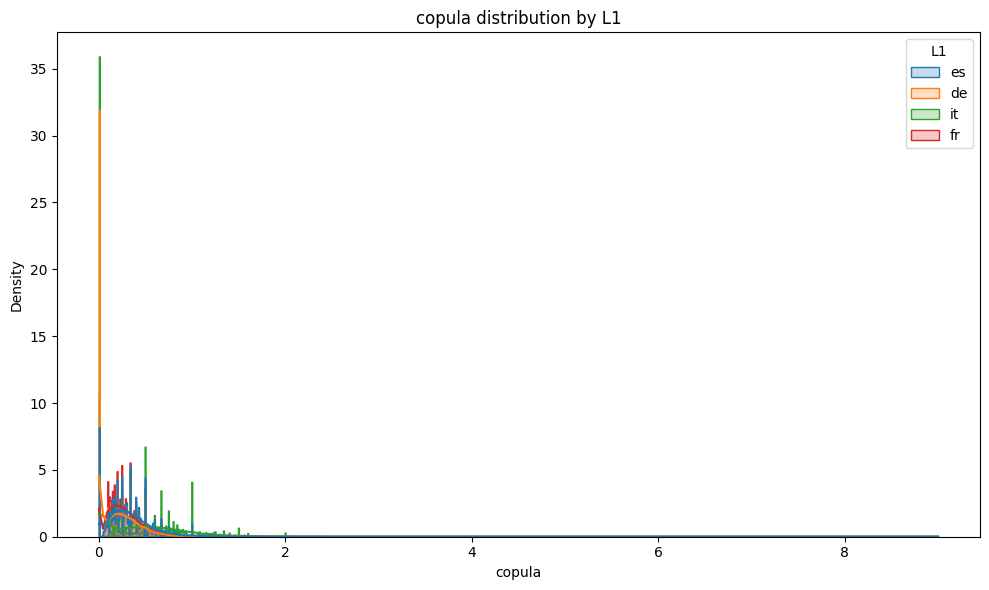

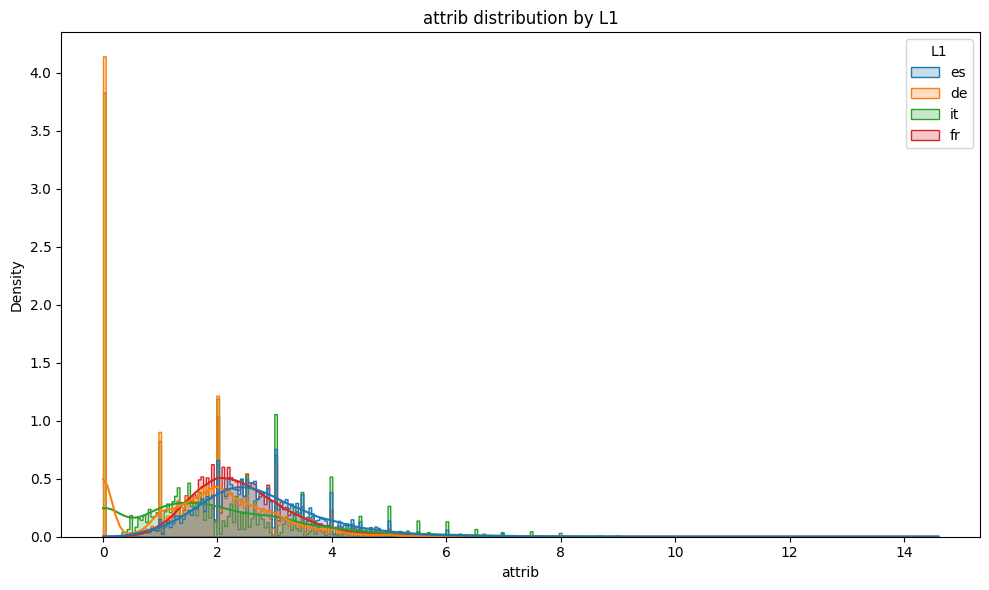

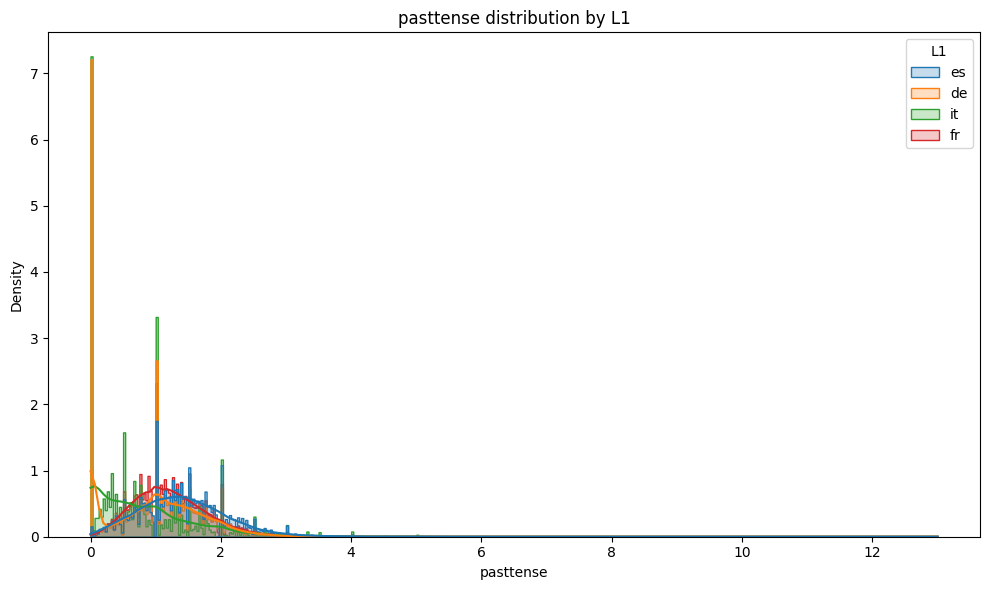

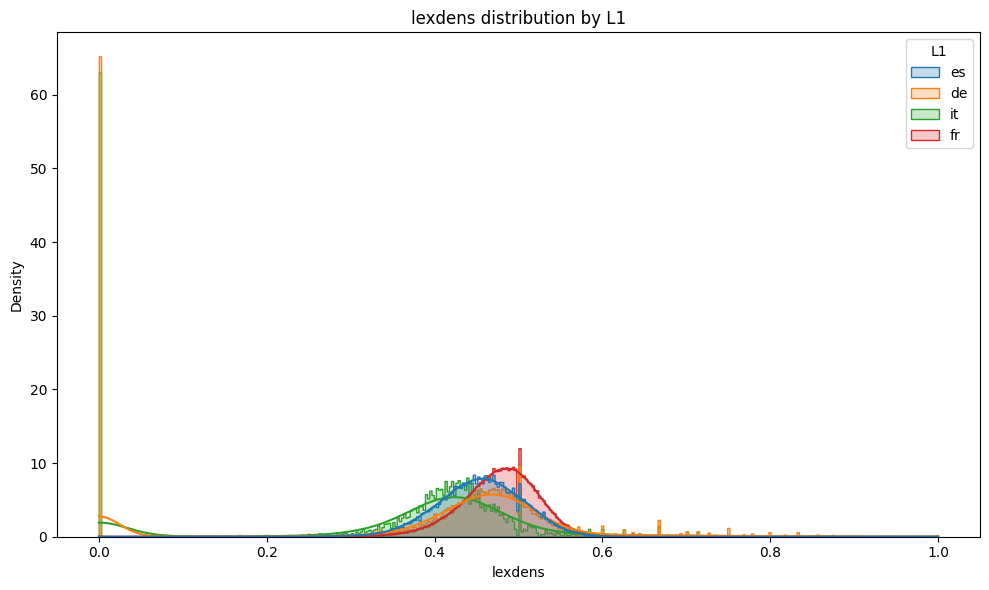

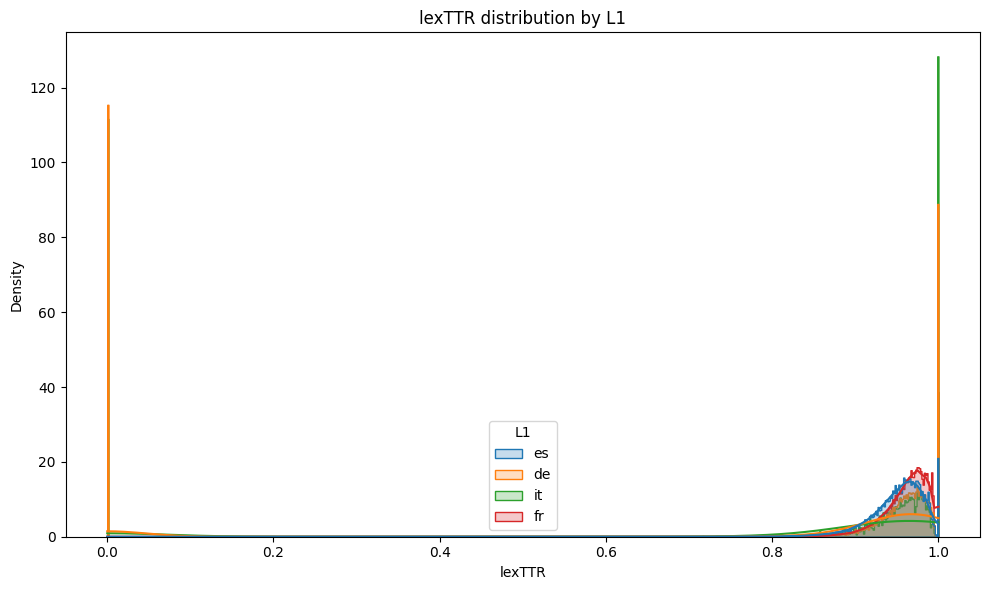

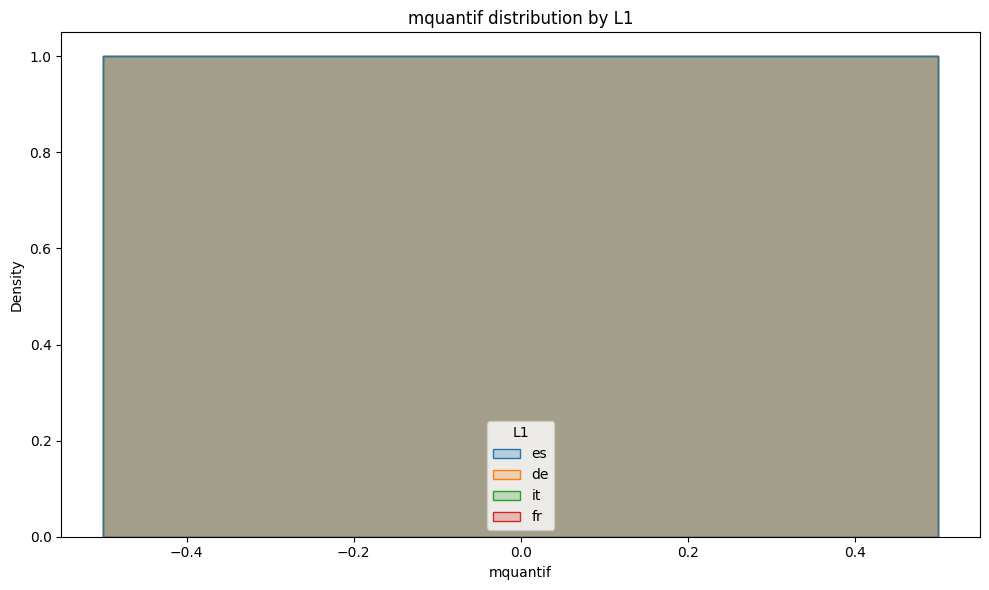

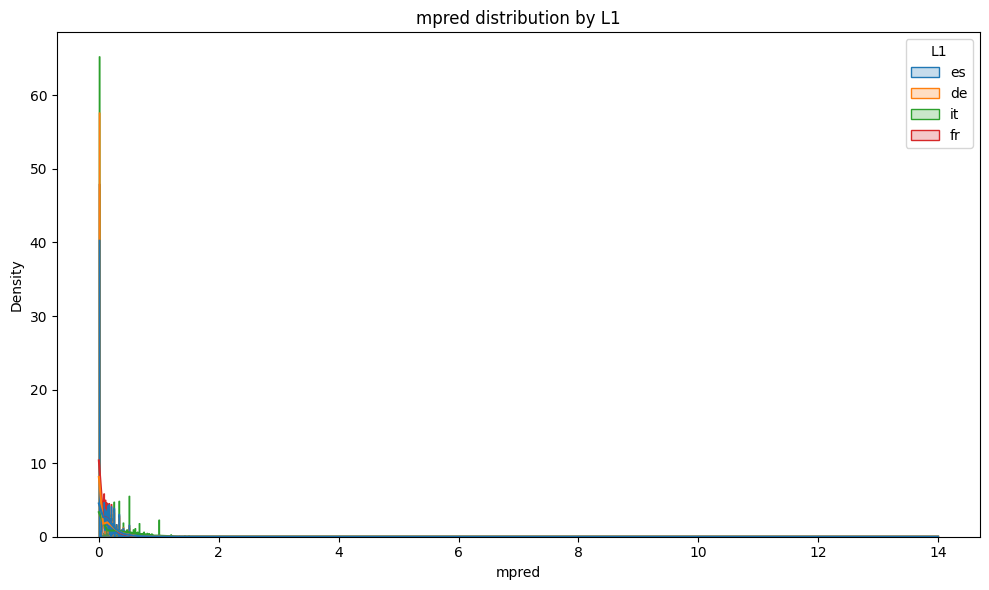

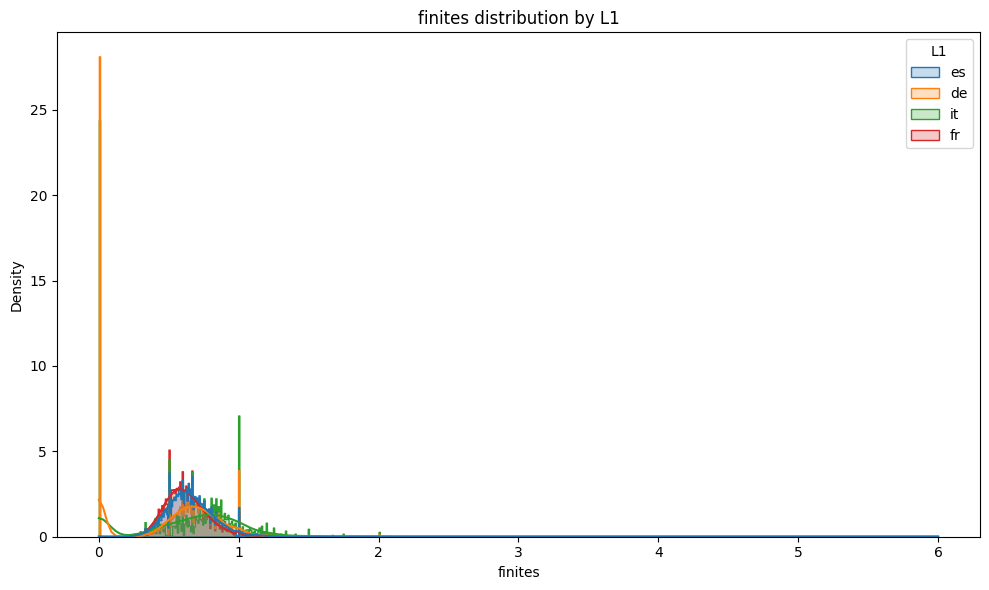

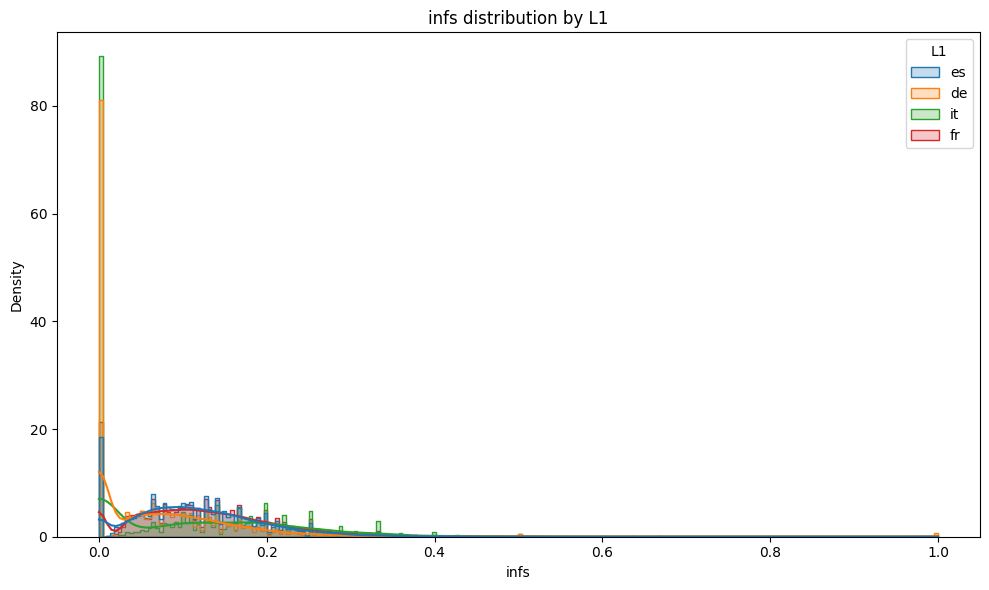

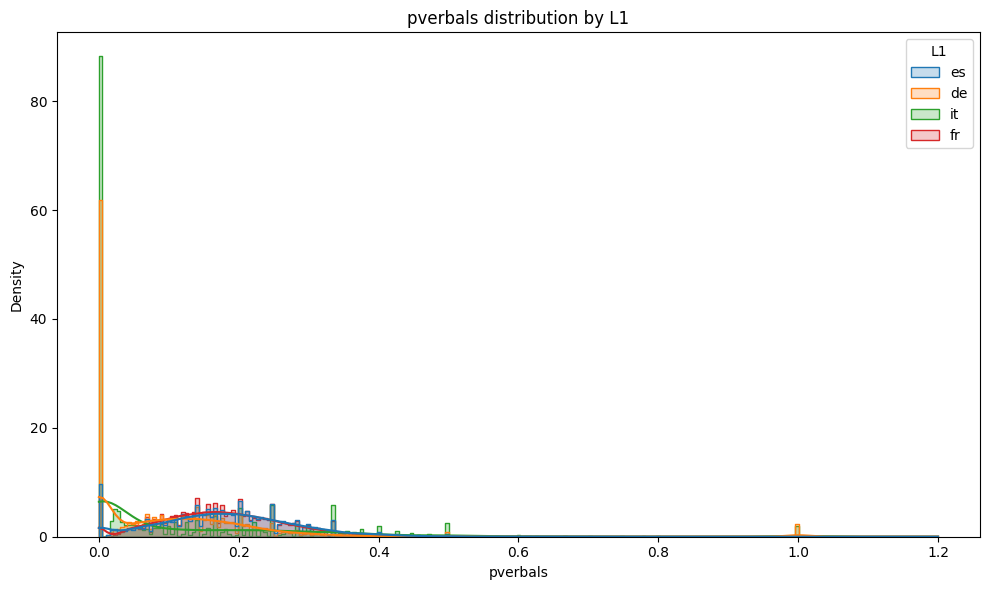

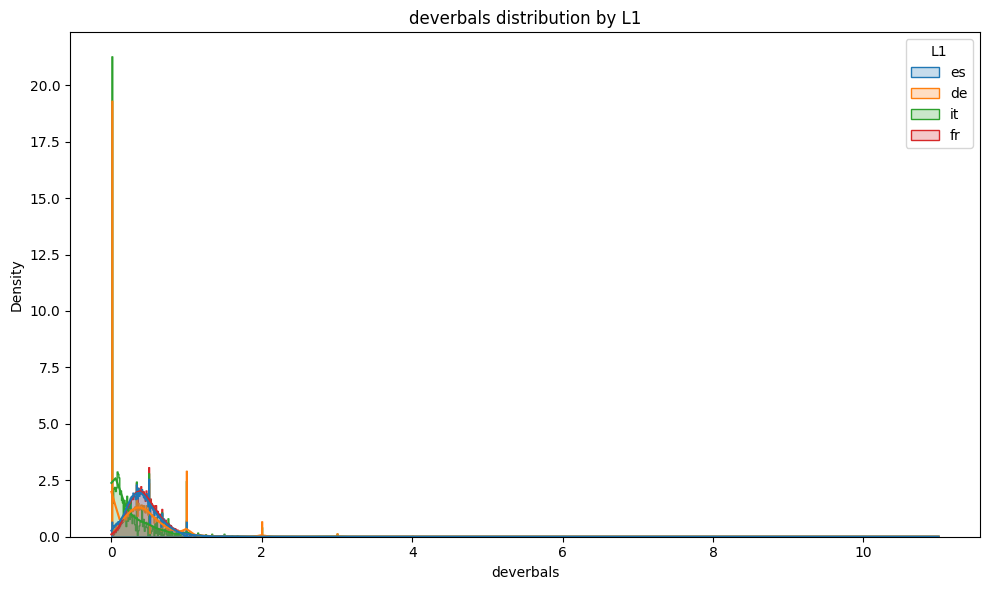

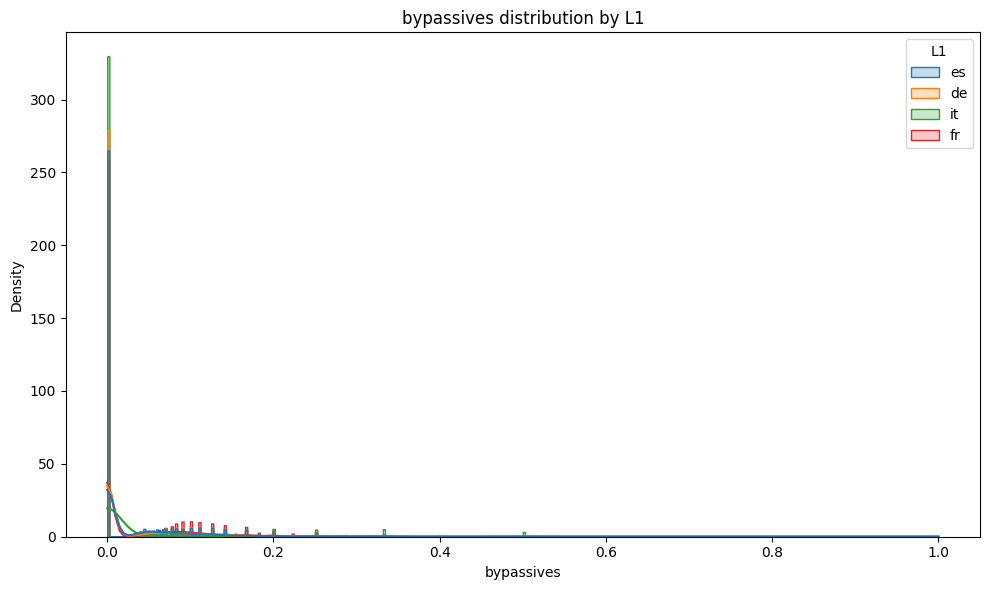

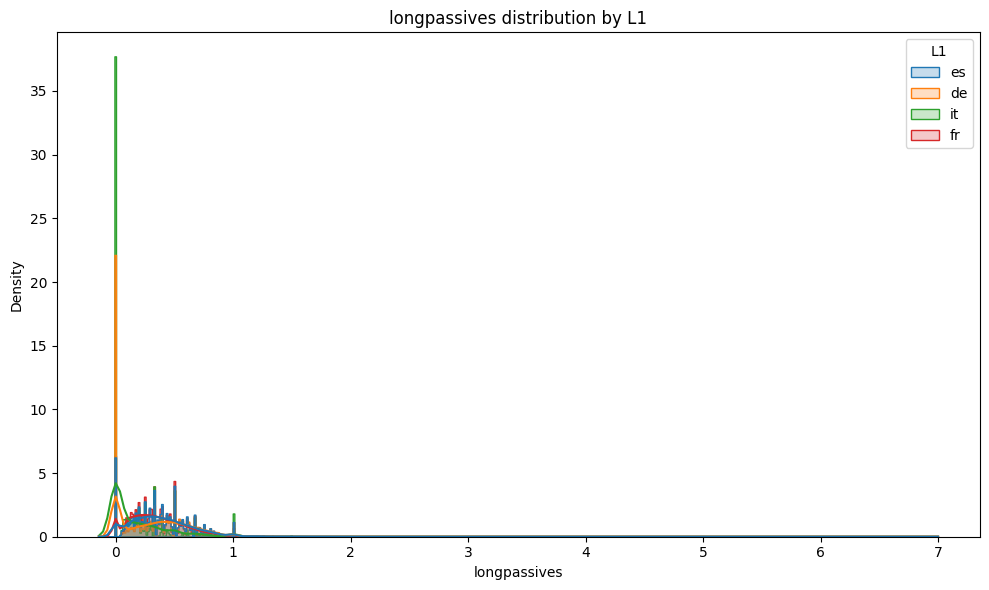

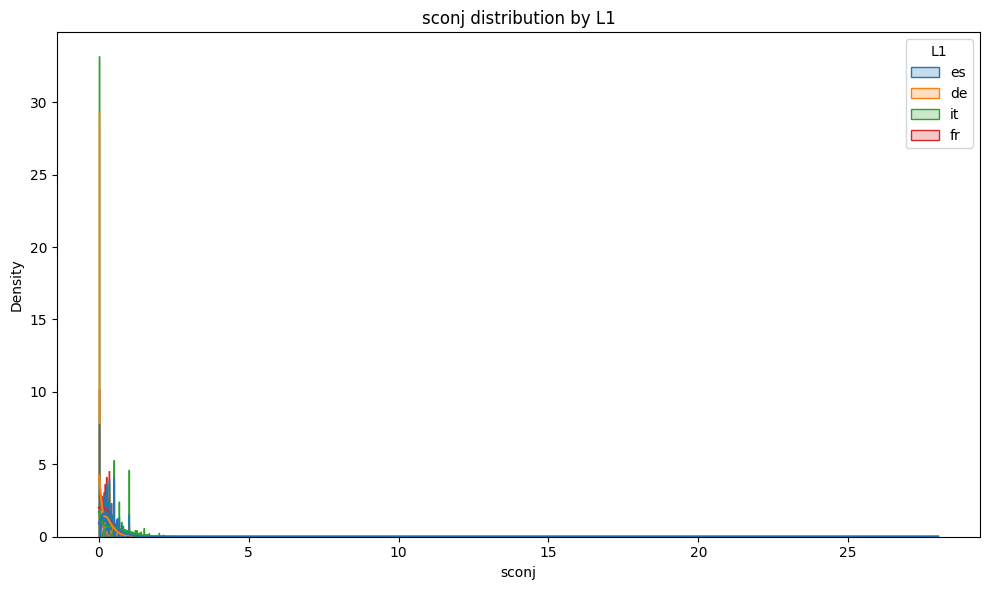

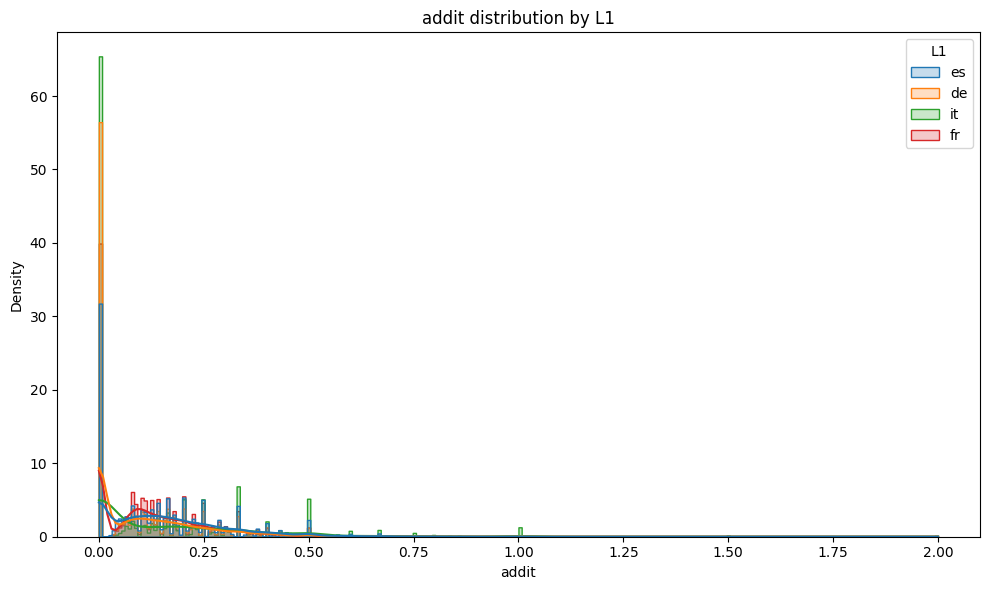

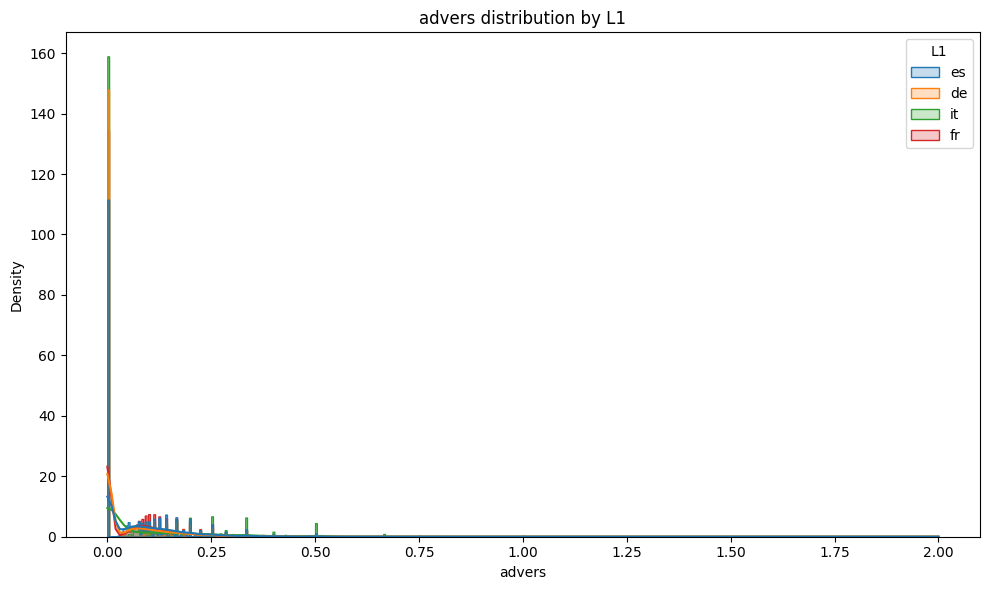

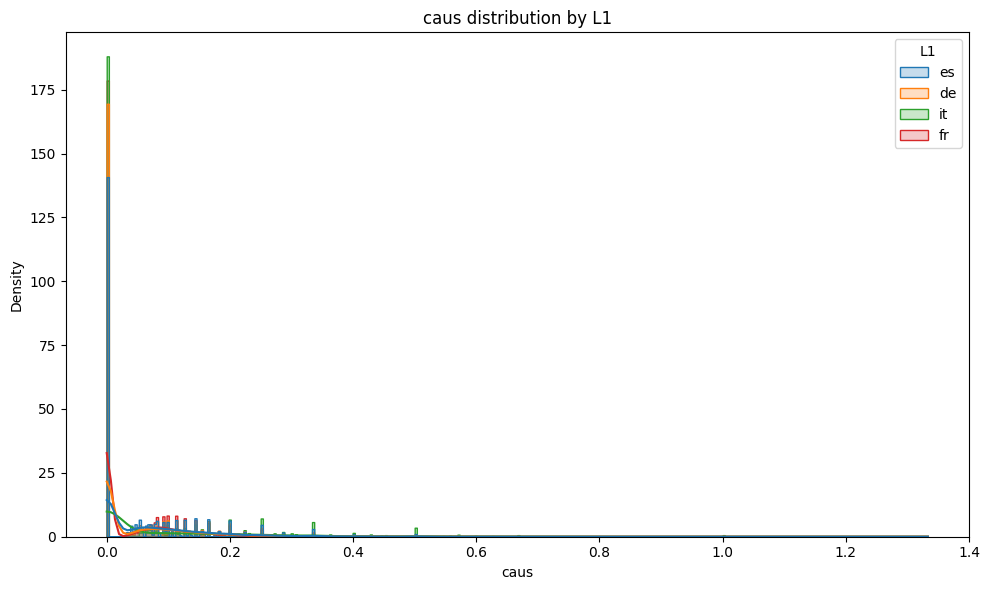

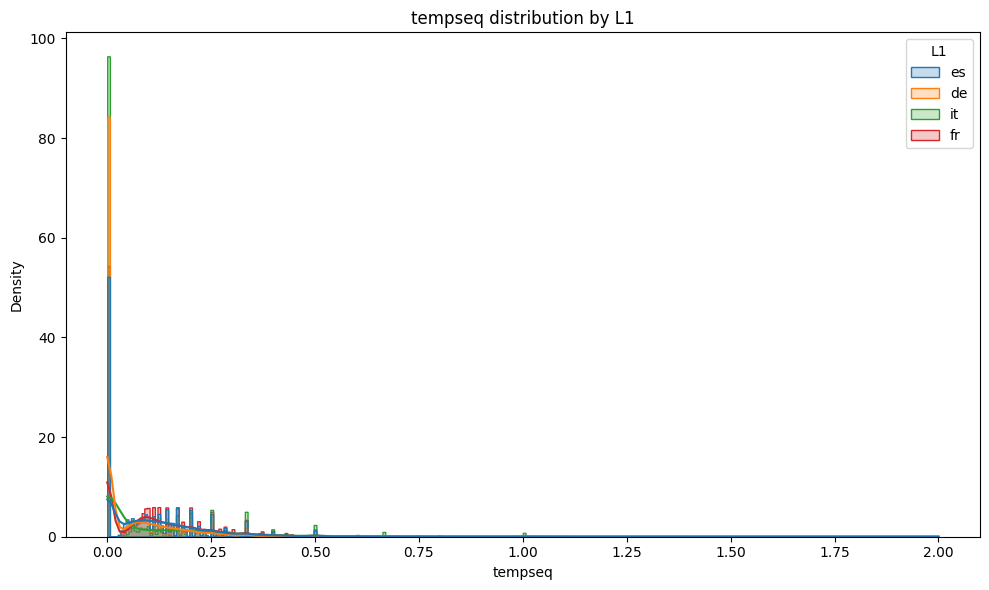

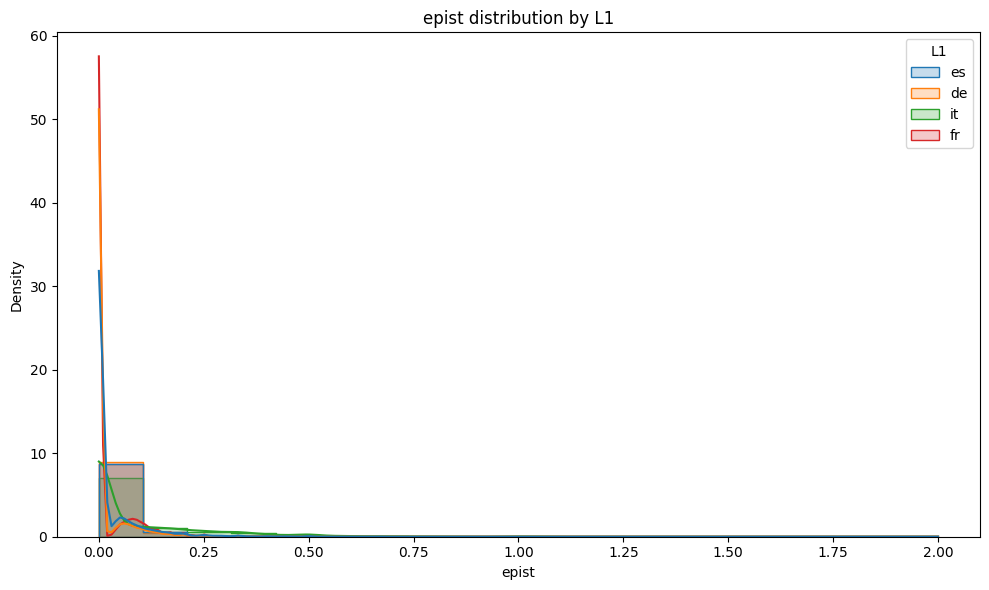

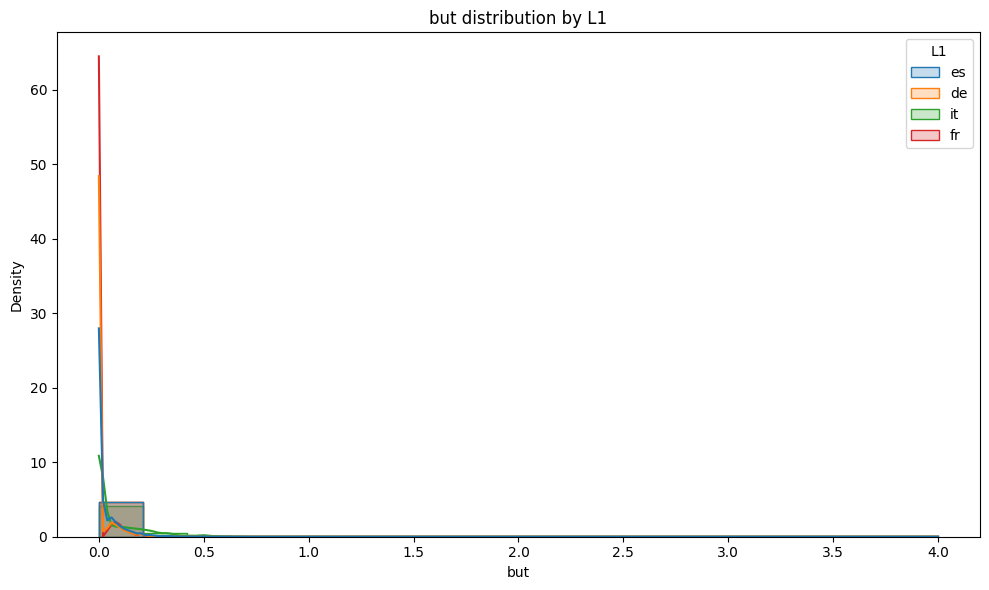

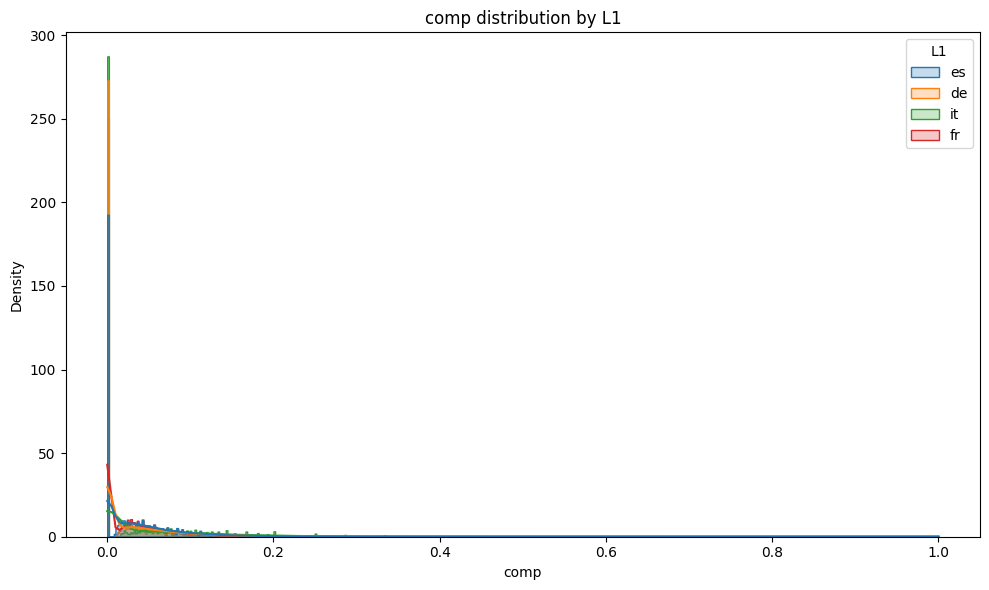

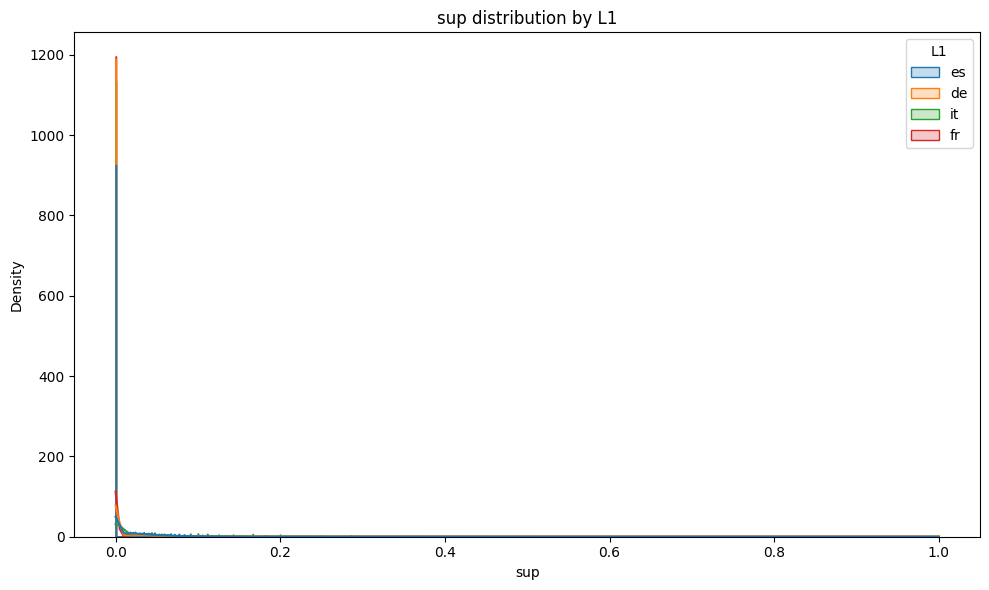

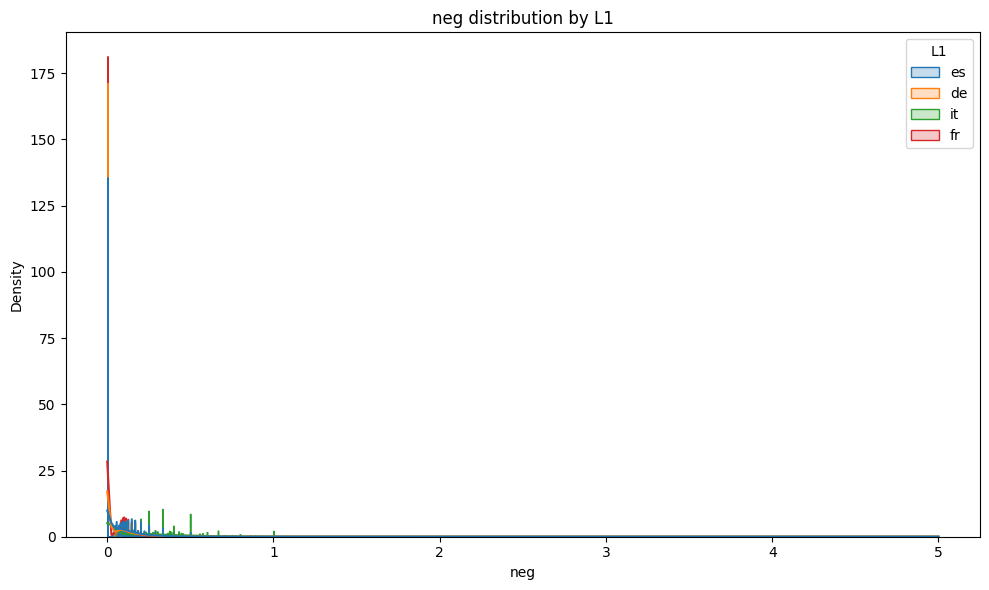

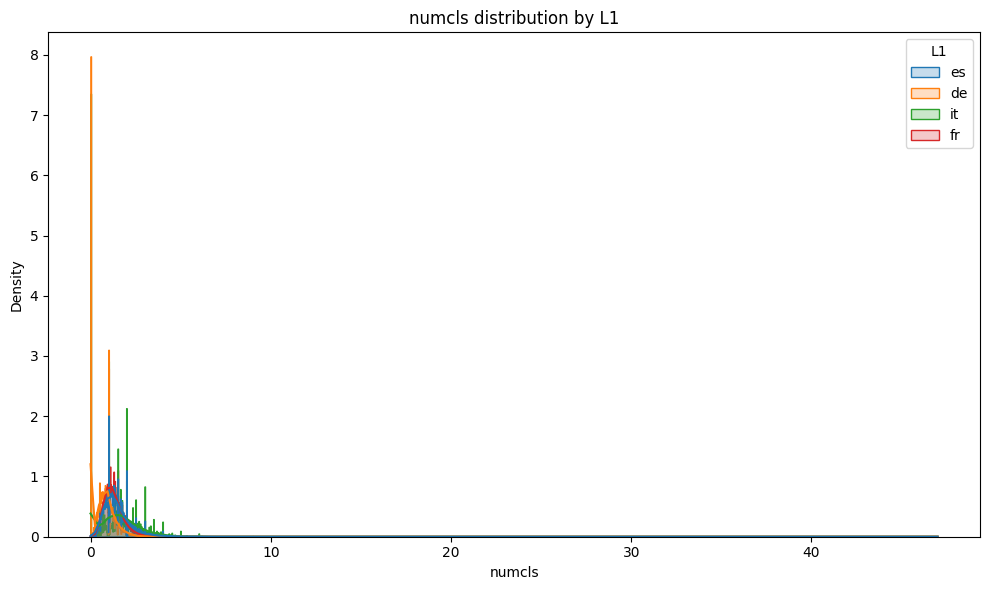

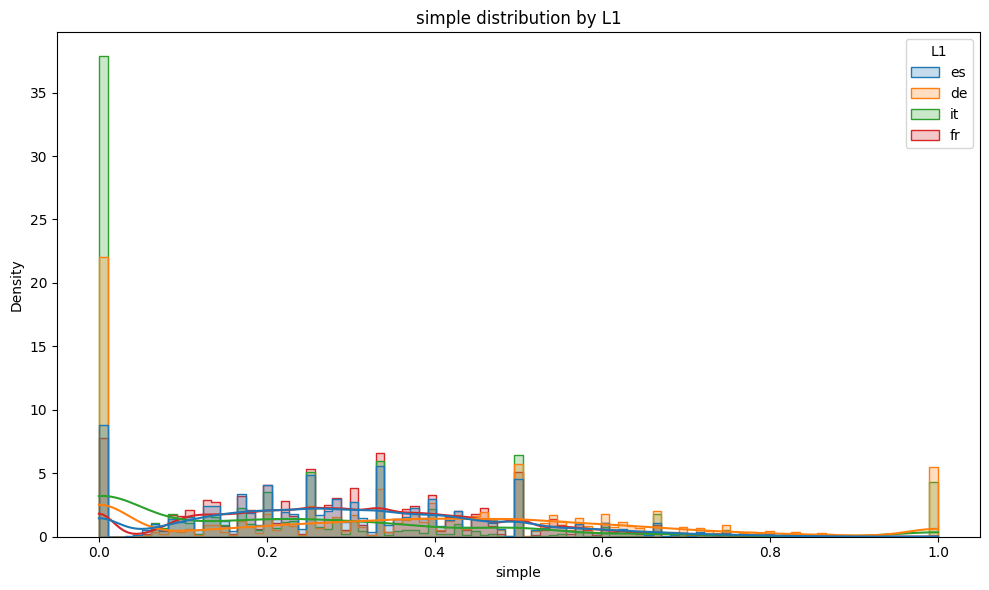

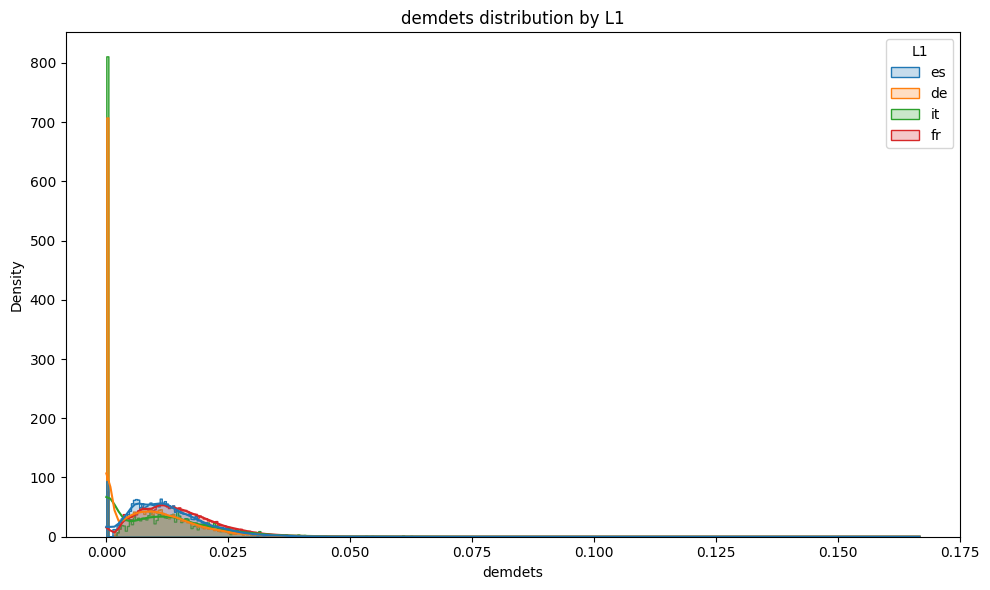

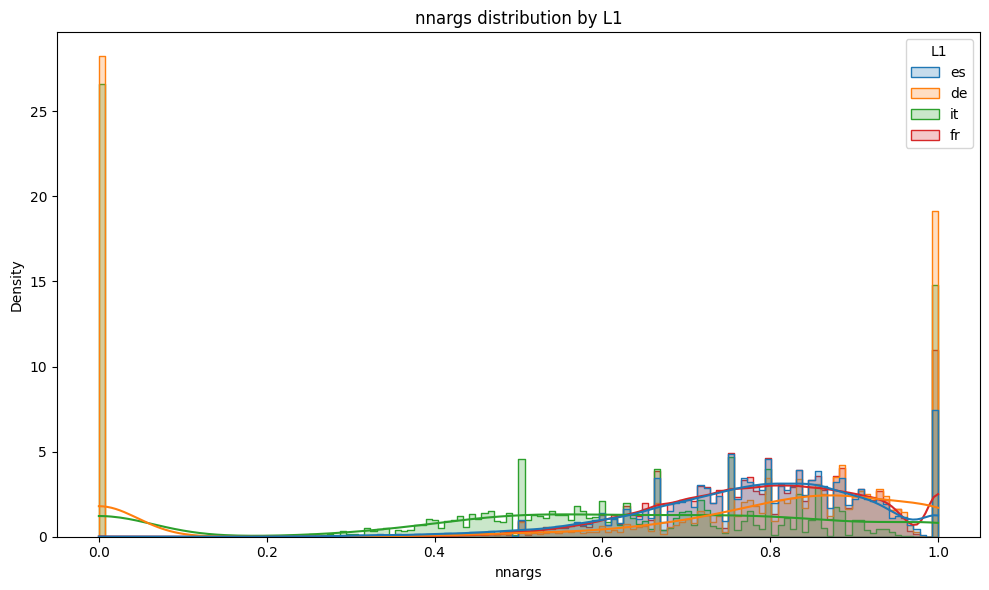

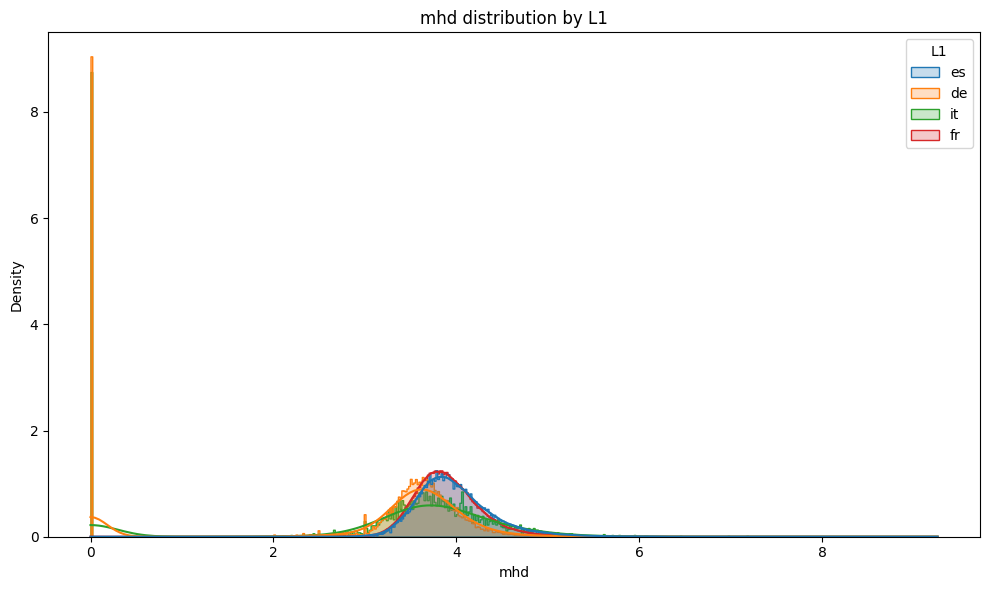

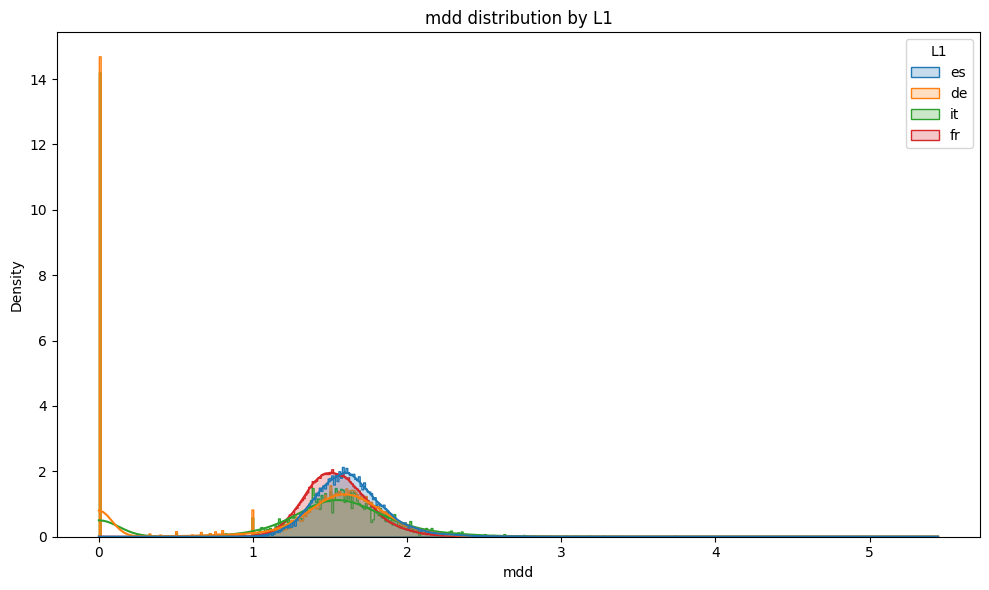

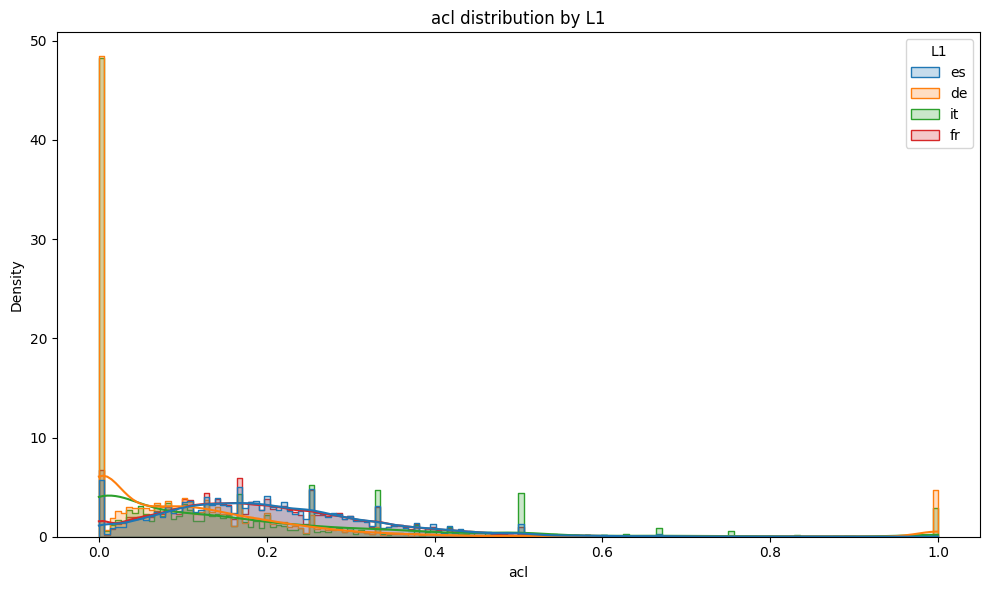

KeyboardInterrupt: 

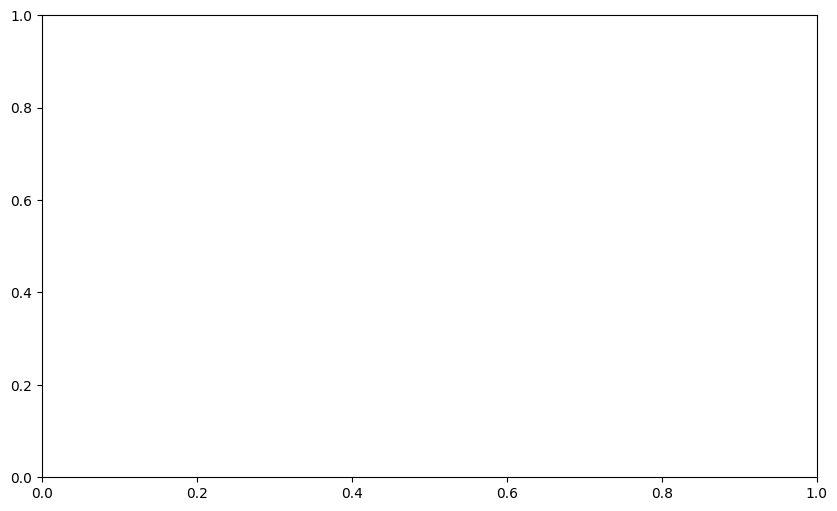

In [102]:
l1_groups = ["es", "de", "fr", "it"]

plot_dir = "plots_L1"
os.makedirs(plot_dir, exist_ok=True)

for col in num_cols:
    plt.figure(figsize=(10, 6))
    try:
      sns.histplot(
          data=df[df["L1"].isin(l1_groups)],
          x=col,
          hue="L1",
          kde=True,
          element="step",
          stat="density",
          common_norm=False,
          label = l1_groups
      )
    except:
      sns.histplot(
          data=df[df["L1"].isin(l1_groups)],
          x=col,
          hue="L1",
          element="step",
          stat="density",
          common_norm=False,
          label = l1_groups
      )

    plt.title(f"{col} distribution by L1")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{col}.png"))
    plt.show()

df = df.drop('L1',axis = 'columns')




# 4️⃣ Create a ZIP file containing all plots
zip_filename = "plots_languages.zip"
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for root, dirs, files in os.walk(plot_dir):
        for file in files:
            zipf.write(os.path.join(root, file), arcname=file)

print(f"All plots saved and zipped as {zip_filename}")

#PCA

##PCA by L2 vs TR

#t-SNE / UMAP (Uniform Manifold Approximation and Projection), a non-linear dimensionality reduction technique.
reveal fine-grained clusters not visible with PCA.

In [ ]:
#t-SNE / UMAP for non-linear embedding
#Goal: reveal fine-grained clusters not visible with PCA.
import umap
embed = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X)
sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=df['L1'],  palette='muted',s=8)


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# embed is your UMAP output (n_samples, 4)
kmeans = KMeans(n_clusters=4, random_state=42)  # k=2
labels = kmeans.fit_predict(embed)  # perform clustering

# Add KMeans labels to your dataframe (optional)
df['kmeans_labels'] = labels

# Visualize clusters on the UMAP embedding
sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=df['kmeans_labels'], palette='muted', s=8)
plt.title("KMeans clusters on Languages")
plt.show()


In [ ]:

import numpy as np
from sklearn.metrics import accuracy_score
import pandas as pd

y_true = df['L1'].values
y_pred = df['kmeans_labels'].values

# Map each cluster to the majority true label inside that cluster
mapped_pred = np.empty_like(y_pred, dtype=object)

for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    true_subset = y_true[mask]

    unique_labels, counts = np.unique(true_subset, return_counts=True)
    majority_label = unique_labels[np.argmax(counts)]

    mapped_pred[mask] = majority_label

accuracy = accuracy_score(y_true, mapped_pred)
print("Clustering Accuracy:", accuracy)
conf_mat = pd.crosstab(y_true, mapped_pred, rownames=['True'], colnames=['Predicted'])
print(conf_mat)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering (k=4)')
plt.show()


<Axes: >

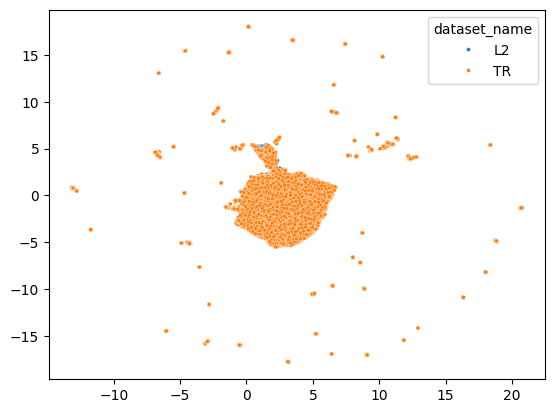

In [52]:
#t-SNE / UMAP for non-linear embedding
#Goal: reveal fine-grained clusters not visible with PCA.
import umap
embed = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X)
sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=df['dataset_name'], s=8)


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# embed is your UMAP output (n_samples, 2)
kmeans = KMeans(n_clusters=2, random_state=42)  # k=2
labels = kmeans.fit_predict(embed)  # perform clustering

# Add KMeans labels to your dataframe (optional)
df['kmeans_labels'] = labels

# Visualize clusters on the UMAP embedding
sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=df['kmeans_labels'], palette='viridis', s=8)
plt.title("KMeans clusters on L2 vs TR")
plt.show()


#Feature importance using a tree-based classifier

Text(0.5, 1.0, 'Top 20 Feature Importances')

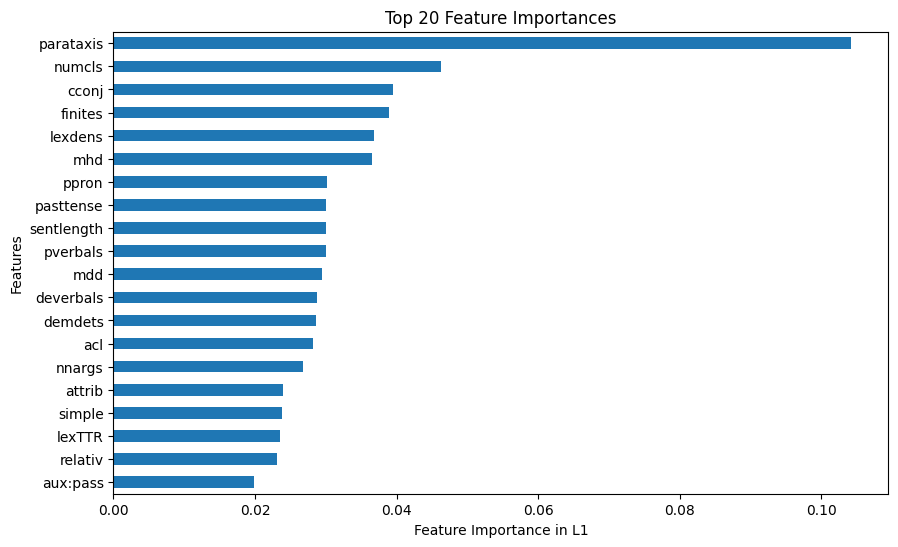

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[num_cols], df['L1'], stratify=df['L1'])
rf = RandomForestClassifier(n_estimators=200).fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
top_features = importances.head(20)[::-1]# reverses the top 20 features for correct horizontal orientation

ax = top_features.plot.barh(figsize=(10,6))
ax.set_xlabel("Feature Importance in L1")
ax.set_ylabel("Features")
ax.set_title("Top 20 Feature Importances")

Text(0.5, 1.0, 'Top 20 Feature Importances')

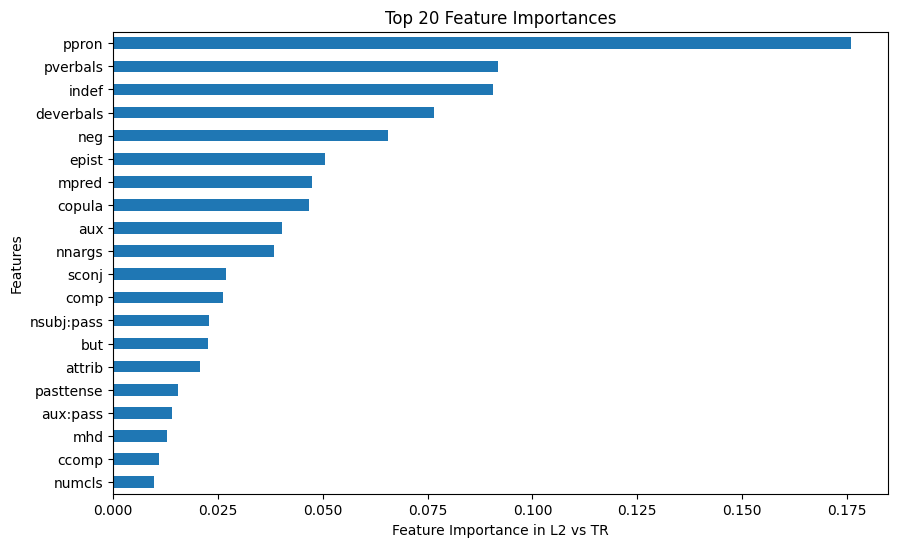

In [57]:
#NEW

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[num_cols], df['dataset_name'], stratify=df['dataset_name'])
rf = RandomForestClassifier(n_estimators=200).fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
top_features = importances.head(20)[::-1]# reverses the top 20 features for correct horizontal orientation

ax = top_features.plot.barh(figsize=(10,6))
ax.set_xlabel("Feature Importance in L2 vs TR")   # X-axis label
ax.set_ylabel("Features")             # Y-axis label
ax.set_title("Top 20 Feature Importances")  # Optional: title


#Outlier Detection


In [58]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.01).fit(X)
df['anomaly'] = iso.predict(X)  # -1 is anomaly
df[df['anomaly']==-1]


,dataset_name,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,...,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,kmeans_labels,anomaly
0,L2,51.875000,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.000000,0.0,...,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,0,-1
3,L2,34.916667,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.000000,0.0,...,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,0,-1
5,L2,29.416667,0.073654,0.002833,0.000000,1.083333,0.166667,0.250000,0.083333,0.0,...,0.106481,0.340278,0.013889,0.115741,0.013889,0.009259,0.317130,it,0,-1
11,L2,21.117647,0.066852,0.013928,0.005571,0.647059,0.000000,0.529412,0.000000,0.0,...,0.041176,0.366667,0.000000,0.139216,0.000000,0.078431,0.198039,fr,0,-1
14,L2,39.571429,0.064982,0.003610,0.018051,0.714286,0.285714,1.428571,0.000000,0.0,...,0.064286,0.471429,0.100000,0.028571,0.071429,0.071429,0.192857,es,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142293,TR,63.666667,0.013089,0.002618,0.000000,2.333333,0.000000,0.500000,0.000000,0.0,...,0.234921,0.079365,0.112698,0.000000,0.051587,0.055556,0.299206,it,0,-1
142468,TR,32.500000,0.015385,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.083333,0.083333,0.083333,0.250000,0.500000,it,0,-1
142472,TR,39.000000,0.008547,0.008547,0.000000,1.333333,0.000000,1.000000,0.000000,0.0,...,0.000000,0.150000,0.216667,0.000000,0.216667,0.000000,0.083333,it,0,-1
142475,TR,73.500000,0.006803,0.000000,0.000000,2.500000,0.000000,2.000000,0.500000,0.0,...,0.416667,0.333333,0.000000,0.000000,0.000000,0.000000,0.250000,it,0,-1


In [59]:
num=num_cols

In [60]:
#Multicollinearity check: VIF (variance inflation factor)
#Goal: quantify redundancy for regression models.
#Insight: drop or combine high-VIF features.
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[num].fillna(0)
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns)
vif.sort_values(ascending=False).head(20)


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,0
lexTTR,450.108899
mhd,262.659818
lexdens,135.966065
mdd,78.788545
sentlength,67.397033
nnargs,56.783924
aux:pass,38.696872
finites,33.378845
numcls,31.784220
nsubj:pass,27.246055


#Finding Optimal K


Text(0, 0.5, 'inertia')

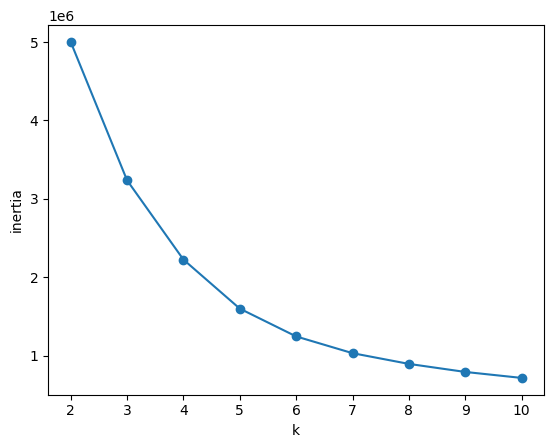

In [61]:
from sklearn.cluster import KMeans
inertia=[]
for k in range(2,11):
    inertia.append(KMeans(k, random_state=0).fit(X).inertia_)
plt.plot(range(2,11), inertia, '-o'); plt.xlabel('k'); plt.ylabel('inertia')


#K-means

In [ ]:
X


In [ ]:
df

##K-means for 2 classes (L2 vs TR)

In [73]:
# define mapping
l1_map = {
    "de": 0,
    "es": 1,
    "fr": 2,
    "it": 3
}

# apply mapping
df["L1_num"] = df["L1"].map(l1_map)



In [74]:
df

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,L1_num
0,L2,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.0,0.0,2.250000,...,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,1
1,L2,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.0,0.0,0.384615,...,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de,0
2,L2,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.0,0.0,0.200000,...,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de,0
3,L2,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.0,0.0,1.750000,...,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,1
4,L2,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.0,0.0,0.500000,...,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142535,TR,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,1.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,3
142536,TR,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,3
142537,TR,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,3.272727,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,3
142538,TR,0.000000,0.025641,0.000000,0.500000,0.000000,1.000000,0.0,0.0,1.000000,...,2.013636,0.875000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,it,3


### DATA IMBALANCE!!

In [75]:
df_temp = df.drop(['dataset_name','L1'],axis = 'columns')
X = df_temp.values

# Apply KMeans with k=2
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

Clustering Accuracy: 0.969131471867546
Cluster      TR
True           
L2         4400
TR       138140


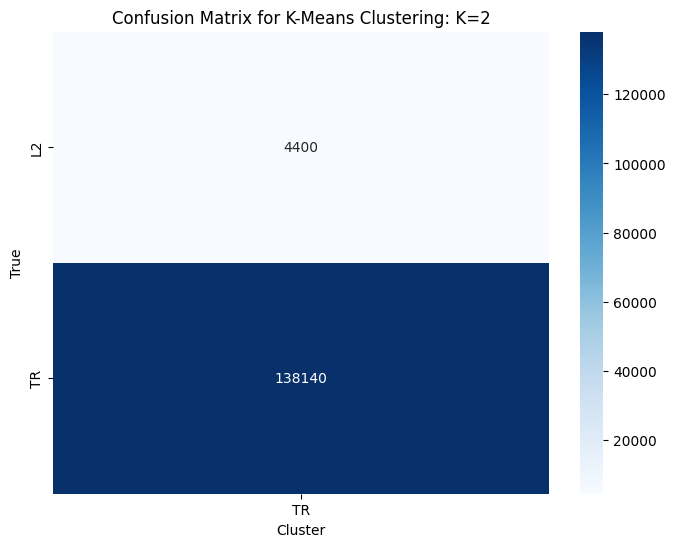

In [76]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Map boolean to string for readability
y_true = df['dataset_name']
y_pred = df['cluster'].values

# Map clusters to majority true label
labels = np.empty_like(y_pred, dtype=object)
for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    unique_labels, counts = np.unique(y_true[mask], return_counts=True)
    majority_label = unique_labels[np.argmax(counts)]
    labels[mask] = majority_label

# Compute accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", accuracy)

# Confusion matrix
confusion_matrix = pd.crosstab(y_true, labels, rownames=['True'], colnames=['Cluster'])
print(confusion_matrix)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering: K=2')
plt.show()
df = df.drop('cluster',axis = 'columns')

In [79]:
df_balanced

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,L1_num
0,L2,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.000000,0.0,2.250000,...,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,1
1,L2,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.000000,0.0,0.384615,...,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de,0
2,L2,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.000000,0.0,0.200000,...,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de,0
3,L2,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.000000,0.0,1.750000,...,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,1
4,L2,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.000000,0.0,0.500000,...,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8795,TR,0.019737,0.004386,0.002193,2.090909,0.090909,1.090909,0.181818,0.0,0.454545,...,1.631134,0.268182,0.053030,0.174242,0.000000,0.174242,0.000000,0.148485,es,1
8796,TR,0.014535,0.005814,0.000000,0.791667,0.208333,0.208333,0.083333,0.0,0.458333,...,1.714083,0.326389,0.162500,0.070833,0.062500,0.084722,0.052083,0.032639,es,1
8797,TR,0.005291,0.013228,0.000000,1.000000,0.083333,0.500000,0.000000,0.0,0.166667,...,1.669443,0.375000,0.020833,0.104167,0.041667,0.062500,0.041667,0.020833,fr,2
8798,TR,0.007692,0.000000,0.000000,1.285714,0.142857,0.000000,0.000000,0.0,0.000000,...,1.417046,0.000000,0.190476,0.190476,0.000000,0.190476,0.142857,0.000000,fr,2


         ppron   possdet     indef     cconj    whconj   relativ      pied  \
0     0.060241  0.004819  0.002410  2.500000  0.375000  1.000000  0.000000   
1     0.064189  0.037162  0.003378  0.538462  0.230769  0.307692  0.000000   
2     0.054878  0.006098  0.006098  0.666667  0.133333  0.266667  0.000000   
3     0.124105  0.023866  0.004773  1.750000  0.500000  0.333333  0.000000   
4     0.039024  0.017073  0.000000  0.909091  0.000000  0.136364  0.000000   
...        ...       ...       ...       ...       ...       ...       ...   
8795  0.019737  0.004386  0.002193  2.090909  0.090909  1.090909  0.181818   
8796  0.014535  0.005814  0.000000  0.791667  0.208333  0.208333  0.083333   
8797  0.005291  0.013228  0.000000  1.000000  0.083333  0.500000  0.000000   
8798  0.007692  0.000000  0.000000  1.285714  0.142857  0.000000  0.000000   
8799  0.005013  0.002506  0.000000  1.250000  0.062500  0.000000  0.000000   

      correl    copula    attrib  ...       mhd       mdd      

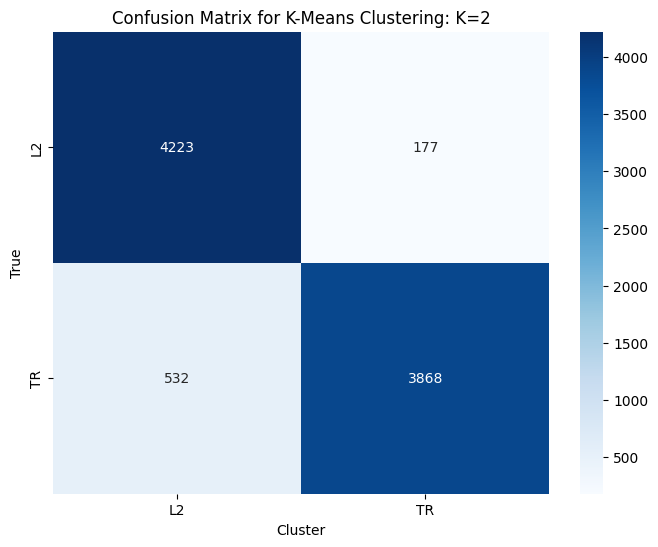

In [78]:
import pandas as pd
from sklearn.cluster import KMeans

df_L2 = df[df['dataset_name'] == 'L2']
df_TR = df[df['dataset_name'] == 'TR']

df_TR_downsampled = df_TR.sample(n=len(df_L2), random_state=42)

df_balanced = pd.concat([df_L2, df_TR_downsampled], ignore_index=True)

df_temp = df_balanced.drop(['dataset_name','L1'], axis='columns')
X = df_temp.values

kmeans = KMeans(n_clusters=2, random_state=42)
df_balanced['cluster'] = kmeans.fit_predict(X)

print(df_balanced['dataset_name'].value_counts())
print(df_balanced['cluster'].value_counts())

# Map boolean to string for readability
y_true = df_balanced['dataset_name']
y_pred = df_balanced['cluster'].values

# Map clusters to majority true label
labels = np.empty_like(y_pred, dtype=object)
for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    unique_labels, counts = np.unique(y_true[mask], return_counts=True)
    majority_label = unique_labels[np.argmax(counts)]
    labels[mask] = majority_label

# Compute accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", accuracy)

# Confusion matrix
confusion_matrix = pd.crosstab(y_true, labels, rownames=['True'], colnames=['Cluster'])
print(confusion_matrix)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering: K=2')
plt.show()
df_balanced = df_balanced.drop('cluster',axis = 'columns')

##K-means for 4 classes (Languages)

####Data Imbalance!

In [80]:
df

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,L1_num
0,L2,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.0,0.0,2.250000,...,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,1
1,L2,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.0,0.0,0.384615,...,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de,0
2,L2,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.0,0.0,0.200000,...,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de,0
3,L2,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.0,0.0,1.750000,...,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,1
4,L2,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.0,0.0,0.500000,...,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142535,TR,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,1.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,3
142536,TR,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,3
142537,TR,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,3.272727,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,3
142538,TR,0.000000,0.025641,0.000000,0.500000,0.000000,1.000000,0.0,0.0,1.000000,...,2.013636,0.875000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,it,3


In [82]:

df = df.drop(['L1_num'],axis = 'columns')


In [86]:
df_temp

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,cluster
0,1,0.000000,0.003115,0.000000,0.857143,0.00,0.071429,0.0,0.0,0.142857,...,3.405797,1.528169,0.023810,0.071429,0.184524,0.000000,0.220238,0.000000,0.000000,3
1,1,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.124581,0.098514,0.129547,0.027490,0.117948,0.018531,0.057606,2
2,1,0.004193,0.014675,0.000000,2.384615,0.00,0.153846,0.0,0.0,0.538462,...,4.181922,1.920791,0.207692,0.000000,0.133333,0.156410,0.117949,0.038462,0.115385,1
3,1,0.003484,0.000000,0.000000,1.142857,0.00,0.071429,0.0,0.0,0.142857,...,3.529186,1.799930,0.047619,0.085884,0.274660,0.000000,0.282313,0.000000,0.095238,0
4,1,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.0,0.0,0.000000,...,3.875000,1.125000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13063,0,0.055556,0.009259,0.000000,0.625000,0.00,0.000000,0.0,0.0,0.875000,...,3.901718,1.448716,0.208333,0.114583,0.000000,0.122917,0.000000,0.108333,0.320833,0
13064,1,0.000000,0.000000,0.000000,1.800000,0.20,0.000000,0.0,0.0,0.000000,...,4.437725,2.038693,0.306667,0.133333,0.140000,0.000000,0.180000,0.040000,0.000000,1
13065,1,0.000000,0.000000,0.000000,0.500000,0.00,0.000000,0.0,0.0,0.000000,...,3.416667,1.181818,0.100000,0.000000,0.350000,0.000000,0.450000,0.000000,0.100000,3
13066,0,0.038123,0.017595,0.002933,0.625000,0.25,0.125000,0.0,0.0,1.500000,...,4.277919,2.376249,0.041667,0.166667,0.239583,0.234375,0.177083,0.052083,0.088542,1


In [88]:
df_temp = df.drop(['L1','cluster'],axis = 'columns')


# mapping dictionary
l2_map = {
    "TR":1,
    "L2":0,
}
# replace L1 with mapped values
df_temp["dataset_name"] = df_temp["dataset_name"].map(l2_map)
X = df_temp.values
# Apply KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X)



In [89]:
import pandas as pd

print(df['L1'].value_counts())

min_count = df['L1'].value_counts().min()
print("Smallest group size:", min_count)

df_balanced = df.groupby('L1').apply(lambda x: x.sample(n=min_count, random_state=42)).reset_index(drop=True)

print(df_balanced['L1'].value_counts())

#df_temp = df_balanced.drop(['L1','L1_name'],axis = 'columns')
df_temp = df_balanced.drop(['L1'],axis = 'columns')
# mapping dictionary
l2_map = {
    "TR":1,
    "L2":0,
}
# replace L1 with mapped values
df_temp["dataset_name"] = df_temp["dataset_name"].map(l2_map)

X = df_temp.values

# Apply KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df_balanced['cluster'] = kmeans.fit_predict(X)



L1
fr    90726
de    28843
es    19704
it     3267
Name: count, dtype: int64
Smallest group size: 3267
L1
de    3267
es    3267
fr    3267
it    3267
Name: count, dtype: int64


/tmp/ipython-input-2779876756.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('L1').apply(lambda x: x.sample(n=min_count, random_state=42)).reset_index(drop=True)


In [90]:
df_balanced

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,cluster
0,TR,0.000000,0.003115,0.000000,0.857143,0.00,0.071429,0.0,0.0,0.142857,...,1.528169,0.023810,0.071429,0.184524,0.000000,0.220238,0.000000,0.000000,de,0
1,TR,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.0,0.0,0.000000,...,0.000000,0.124581,0.098514,0.129547,0.027490,0.117948,0.018531,0.057606,de,2
2,TR,0.004193,0.014675,0.000000,2.384615,0.00,0.153846,0.0,0.0,0.538462,...,1.920791,0.207692,0.000000,0.133333,0.156410,0.117949,0.038462,0.115385,de,0
3,TR,0.003484,0.000000,0.000000,1.142857,0.00,0.071429,0.0,0.0,0.142857,...,1.799930,0.047619,0.085884,0.274660,0.000000,0.282313,0.000000,0.095238,de,3
4,TR,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.0,0.0,0.000000,...,1.125000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13063,L2,0.055556,0.009259,0.000000,0.625000,0.00,0.000000,0.0,0.0,0.875000,...,1.448716,0.208333,0.114583,0.000000,0.122917,0.000000,0.108333,0.320833,it,1
13064,TR,0.000000,0.000000,0.000000,1.800000,0.20,0.000000,0.0,0.0,0.000000,...,2.038693,0.306667,0.133333,0.140000,0.000000,0.180000,0.040000,0.000000,it,0
13065,TR,0.000000,0.000000,0.000000,0.500000,0.00,0.000000,0.0,0.0,0.000000,...,1.181818,0.100000,0.000000,0.350000,0.000000,0.450000,0.000000,0.100000,it,0
13066,L2,0.038123,0.017595,0.002933,0.625000,0.25,0.125000,0.0,0.0,1.500000,...,2.376249,0.041667,0.166667,0.239583,0.234375,0.177083,0.052083,0.088542,it,0


Clustering Accuracy: 0.41199877563513926
Predicted    de    es   it
True                      
de         2059  1120   88
es          709  2397  161
fr         1261  1947   59
it         1122  1217  928


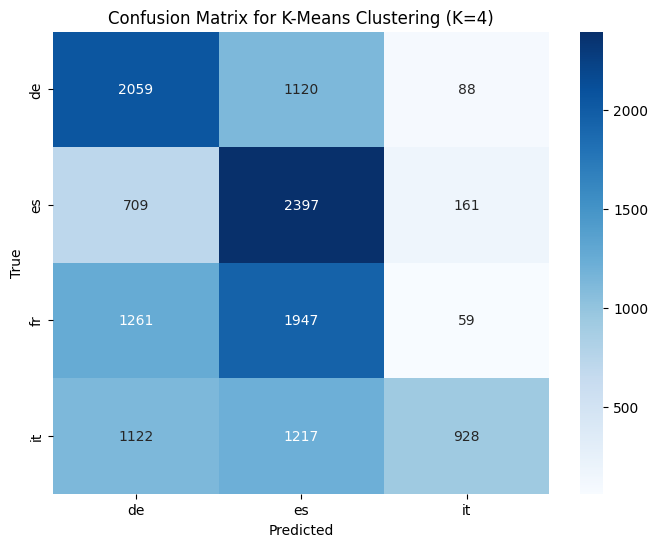

In [91]:

# True labels (as strings)
y_true = df_balanced["L1"].values
y_pred = df_balanced["cluster"].values

# Map clusters to majority true label (using string labels)
labels = np.empty_like(y_pred, dtype=object)
for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    true_labels_in_cluster = y_true[mask]
    uniq, counts = np.unique(true_labels_in_cluster, return_counts=True)
    majority_label = uniq[np.argmax(counts)]
    labels[mask] = majority_label

# Accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", accuracy)

# Confusion matrix
conf_mat = pd.crosstab(pd.Series(y_true, name='True'),
                       pd.Series(labels, name='Predicted'))
print(conf_mat)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering (K=4)')
plt.show()
#df = df.drop(['cluster'],axis = 'columns')

#Splitting datasets into L2 and TR

In [92]:

table = df.groupby("L1")["dataset_name"].value_counts().unstack(fill_value=0)
print(table)


dataset_name    L2     TR
L1                       
de            1100  27743
es            1100  18604
fr            1100  89626
it            1100   2167


In [93]:
import pandas as pd


df_L2 = df[df["dataset_name"] == "L2"].copy()
df_TR = df[df["dataset_name"] == "TR"].copy()


In [94]:
df_L2

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,cluster
0,L2,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.0,0.0,2.250000,...,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,3
1,L2,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.0,0.0,0.384615,...,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de,0
2,L2,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.0,0.0,0.200000,...,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de,0
3,L2,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.0,0.0,1.750000,...,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,0
4,L2,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.0,0.0,0.500000,...,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4395,L2,0.013514,0.013514,0.002703,0.529412,0.058824,0.000000,0.0,0.0,0.411765,...,1.673307,0.058824,0.460784,0.053922,0.093137,0.053922,0.056373,0.105392,de,0
4396,L2,0.020785,0.011547,0.000000,0.619048,0.047619,0.238095,0.0,0.0,0.428571,...,1.508645,0.015873,0.420408,0.120635,0.038549,0.049206,0.071429,0.141043,fr,0
4397,L2,0.042553,0.014184,0.000000,1.000000,0.000000,0.333333,0.0,0.0,0.555556,...,1.404791,0.129630,0.350000,0.000000,0.111111,0.000000,0.087037,0.211111,es,3
4398,L2,0.028653,0.008596,0.008596,1.000000,0.000000,0.125000,0.0,0.0,0.812500,...,1.651952,0.102679,0.202083,0.021429,0.073512,0.008929,0.125000,0.153869,it,0


### Without PCA (Splitting datasets into L2 and TR)

In [95]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


def run_clustering(df, features, label_col="L1", k=4, title="Clustering"):
    # -----------------------------
    # K-means clustering
    # -----------------------------
    X = df[features].values

    # -----------------------------
    # Standardize features
    # -----------------------------
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df["cluster"] = kmeans.fit_predict(X)

    # -----------------------------
    # True labels
    # -----------------------------
    y_true = df[label_col].values
    y_pred = df["cluster"].values

    # -----------------------------
    # Map cluster → majority true label
    # -----------------------------
    labels = np.empty_like(y_pred, dtype=object)

    for cluster in np.unique(y_pred):
        mask = (y_pred == cluster)
        unique_labels, counts = np.unique(y_true[mask], return_counts=True)
        majority_label = unique_labels[np.argmax(counts)]
        labels[mask] = majority_label

    # -----------------------------
    # Accuracy
    # -----------------------------
    accuracy = accuracy_score(y_true, labels)
    print(f"\n===== {title} =====")
    print("Accuracy:", accuracy)

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    cm = pd.crosstab(y_true, labels, rownames=["True"], colnames=["Predicted"])
    print(cm)

    # -----------------------------
    # Heatmap
    # -----------------------------
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {title}")
    plt.show()

    return df, accuracy, cm

features = df_L2.drop(columns=["L1", "dataset_name"]).select_dtypes(include=[np.number]).columns


####L2


===== L2 Dataset (k=4) =====
Accuracy: 0.3209090909090909
Predicted   de   es   it
True                    
de         540   10  550
es         279  179  642
fr         471   31  598
it         286  121  693


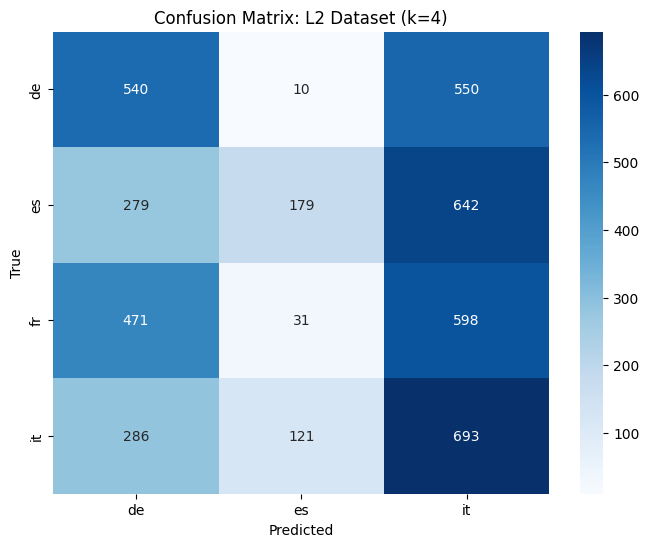

In [96]:

df_L2, acc_L2, cm_L2 = run_clustering(
    df_L2,
    features=features,
    label_col="L1",
    k=4,
    title="L2 Dataset (k=4)"
)


####TR

In [97]:
df_TR

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,cluster
4400,TR,0.010050,0.000000,0.0,0.700000,0.000000,0.200000,0.0,0.0,0.200000,...,1.568188,0.000000,0.150000,0.300000,0.0,0.300000,0.000000,0.050000,de,0
4401,TR,0.000000,0.000000,0.0,1.142857,0.000000,0.000000,0.0,0.0,0.142857,...,1.651344,0.000000,0.000000,0.309524,0.0,0.309524,0.000000,0.095238,de,0
4402,TR,0.000000,0.000000,0.0,0.818182,0.000000,0.000000,0.0,0.0,0.090909,...,1.932829,0.136364,0.075758,0.151515,0.0,0.181818,0.000000,0.000000,de,3
4403,TR,0.002809,0.002809,0.0,1.000000,0.000000,0.133333,0.0,0.0,0.266667,...,1.625988,0.138889,0.000000,0.305556,0.0,0.238889,0.000000,0.050000,de,0
4404,TR,0.005249,0.000000,0.0,1.000000,0.066667,0.000000,0.0,0.0,0.533333,...,1.669190,0.100000,0.133333,0.117460,0.0,0.126984,0.066667,0.055556,de,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142535,TR,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,1.166667,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,it,0
142536,TR,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,it,2
142537,TR,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,3.272727,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,it,3
142538,TR,0.000000,0.025641,0.0,0.500000,0.000000,1.000000,0.0,0.0,1.000000,...,2.013636,0.875000,0.125000,0.000000,0.0,0.000000,0.000000,0.000000,it,1


L1
de    2167
es    2167
fr    2167
it    2167
Name: count, dtype: int64

===== TR Dataset (k=4) =====
Accuracy: 0.3560221504383941
Predicted   de   es   fr   it
True                         
de         957  219  596  395
es         865  780  521    1
fr         896  458  812    1
it         328  649  653  537


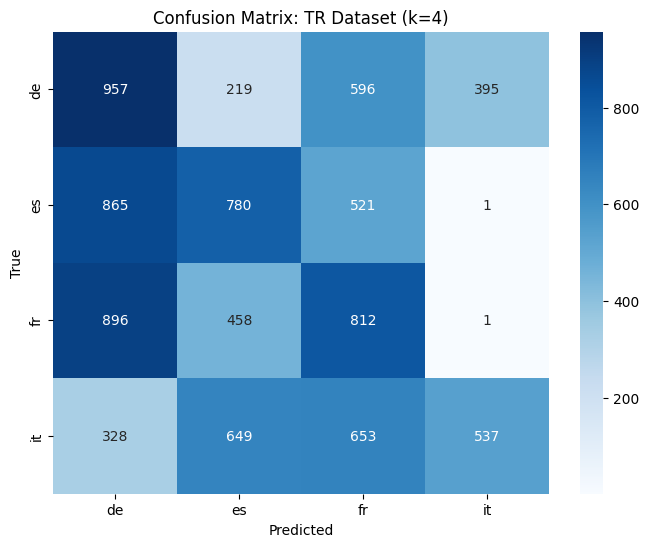

In [98]:

# Number of samples per class
n_samples = 2167

# Sample 2167 rows from each L1 class
df_TR_balanced = df_TR.groupby("L1").sample(n=n_samples, random_state=42)

# Check the new class counts
print(df_TR_balanced["L1"].value_counts())

features_tr = df_TR_balanced.drop(columns=["L1", "dataset_name"]).select_dtypes(include=[np.number]).columns


df_TR_balanced, acc_TR, cm_TR = run_clustering(
    df_TR_balanced,
    features=features_tr,
    label_col="L1",
    k=4,
    title="TR Dataset (k=4)"
)


### With PCA (Splitting datasets into L2 and TR)

In [99]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

random_state = 42

def clustering_with_pca_analysis(df, label_col="L1", k=4, title="Dataset"):
    # -----------------------------
    # Features
    # -----------------------------
    features = df.drop(columns=[label_col, "dataset_name"]).select_dtypes(include=[np.number]).columns
    X = df[features].values

    # -----------------------------
    # Standardize features
    # -----------------------------
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)

    # -----------------------------
    # PCA (retain 95% variance)
    # -----------------------------
    pca = PCA(n_components=0.95, random_state=random_state)
    X_pca = pca.fit_transform(X_s)
    print(f"\n{title} PCA retained variance:", pca.explained_variance_ratio_.sum())
    print(f"{title} PCA components shape:", X_pca.shape)

    # -----------------------------
    # K-means clustering
    # -----------------------------
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    df["cluster"] = kmeans.fit_predict(X_pca)

    # -----------------------------
    # Map cluster → majority label
    # -----------------------------
    y_true = df[label_col].values
    y_pred = df["cluster"].values
    labels = np.empty_like(y_pred, dtype=object)

    for cluster in np.unique(y_pred):
        mask = (y_pred == cluster)
        unique_labels, counts = np.unique(y_true[mask], return_counts=True)
        majority_label = unique_labels[np.argmax(counts)]
        labels[mask] = majority_label

    # -----------------------------
    # Accuracy
    # -----------------------------
    accuracy = accuracy_score(y_true, labels)
    print(f"{title} Clustering Accuracy:", accuracy)

    # -----------------------------
    # Confusion matrix
    # -----------------------------
    cm = pd.crosstab(y_true, labels, rownames=["True"], colnames=["Predicted"])
    print(cm)

    # -----------------------------
    # Heatmap
    # -----------------------------
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {title}")
    plt.show()

    return df, accuracy, cm, X_pca


#### L2


L2 Dataset PCA retained variance: 0.9513571011681301
L2 Dataset PCA components shape: (4400, 33)
L2 Dataset Clustering Accuracy: 0.3234090909090909
Predicted   de   es   it
True                    
de         544  305  251
es         281  594  225
fr         473  424  203
it         290  525  285


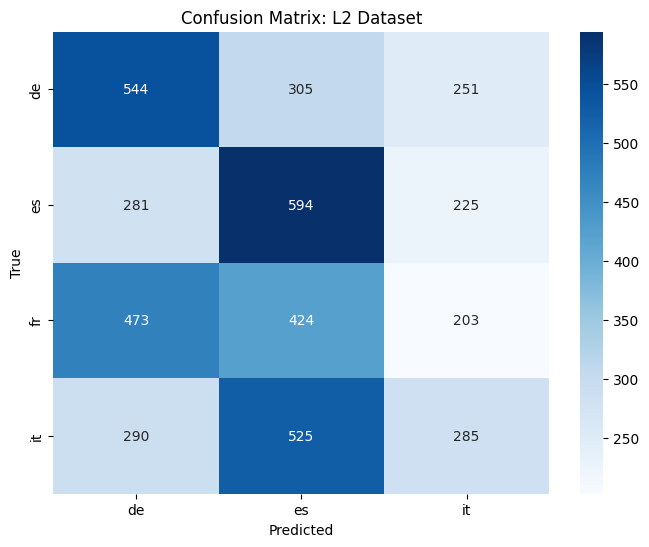

In [100]:
df_L2, acc_L2, cm_L2, X_L2_pca = clustering_with_pca_analysis(df_L2, label_col="L1", k=4, title="L2 Dataset")
#IN L2 WITHOUT PCA ITS EXACT SAME RESULT!

####TR


TR Dataset PCA retained variance: 0.9559260040758254
TR Dataset PCA components shape: (138140, 33)
TR Dataset Clustering Accuracy: 0.6840596496308093
Predicted    de     fr
True                  
de         4878  22865
es            2  18602
fr            8  89618
it          535   1632


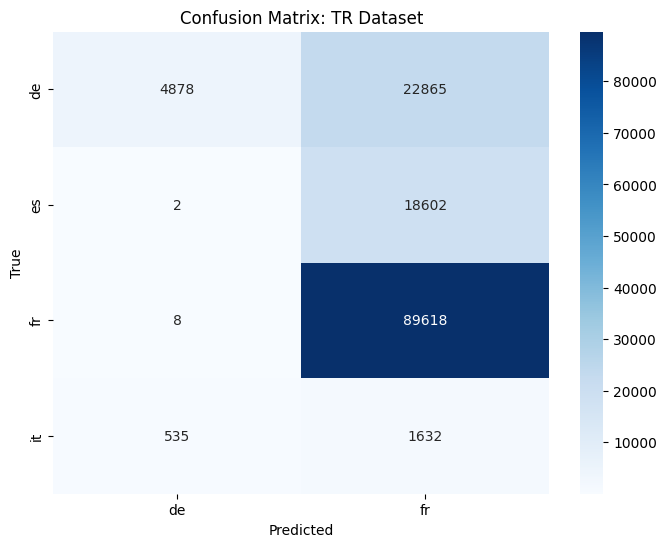

In [101]:
df_TR, acc_TR, cm_TR, X_TR_pca = clustering_with_pca_analysis(df_TR, label_col="L1", k=4, title="TR Dataset")


#### TR with balanced data (PCA)


```
OLD
dataset    L2    TR
L1                 
de       1100   926
es       1100   615
fr       1100  2888
it       1100    79

NEW!!
dataset_name    L2     TR
L1                       
de            1100  27743
es            1100  18604
fr            1100  89626
it            1100   2167
```




L1
de    2167
es    2167
fr    2167
it    2167
Name: count, dtype: int64

TR Dataset (Balanced, k=4, PCA) PCA retained variance: 0.9541863521128449
TR Dataset (Balanced, k=4, PCA) PCA components shape: (8668, 32)
TR Dataset (Balanced, k=4, PCA) Clustering Accuracy: 0.3673281033687125
Predicted   de   es   fr   it
True                         
de         869  283  620  395
es         726  893  547    1
fr         759  521  886    1
it         278  685  668  536


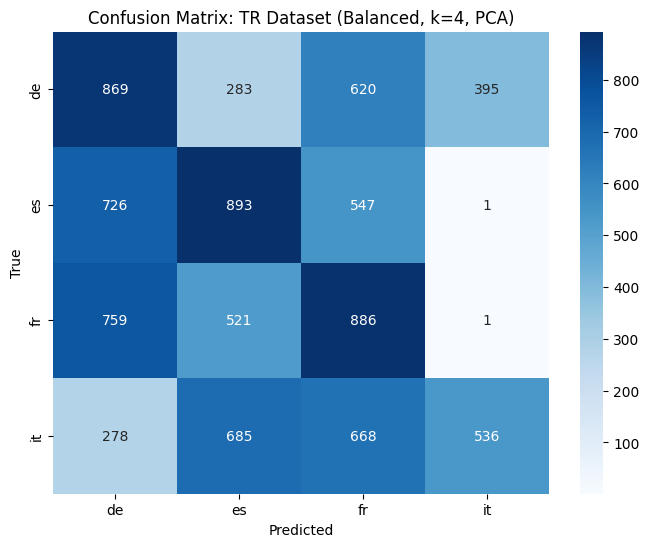

In [102]:
# Number of samples per class
n_samples = 2167

# Sample 2167 rows from each L1 class
df_TR_balanced = df_TR.groupby("L1").sample(n=n_samples, random_state=42)

# Check the new class counts
print(df_TR_balanced["L1"].value_counts())

df_TR_balanced, acc_TR, cm_TR, X_TR_pca = clustering_with_pca_analysis(
    df_TR_balanced,
    label_col="L1",
    k=4,
    title="TR Dataset (Balanced, k=4, PCA)"
)


In [103]:
df_L2

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,cluster
0,L2,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.0,0.0,2.250000,...,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,1
1,L2,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.0,0.0,0.384615,...,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de,0
2,L2,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.0,0.0,0.200000,...,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de,0
3,L2,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.0,0.0,1.750000,...,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,1
4,L2,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.0,0.0,0.500000,...,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4395,L2,0.013514,0.013514,0.002703,0.529412,0.058824,0.000000,0.0,0.0,0.411765,...,1.673307,0.058824,0.460784,0.053922,0.093137,0.053922,0.056373,0.105392,de,0
4396,L2,0.020785,0.011547,0.000000,0.619048,0.047619,0.238095,0.0,0.0,0.428571,...,1.508645,0.015873,0.420408,0.120635,0.038549,0.049206,0.071429,0.141043,fr,0
4397,L2,0.042553,0.014184,0.000000,1.000000,0.000000,0.333333,0.0,0.0,0.555556,...,1.404791,0.129630,0.350000,0.000000,0.111111,0.000000,0.087037,0.211111,es,3
4398,L2,0.028653,0.008596,0.008596,1.000000,0.000000,0.125000,0.0,0.0,0.812500,...,1.651952,0.102679,0.202083,0.021429,0.073512,0.008929,0.125000,0.153869,it,0


### Splitting data - NN



===== MLP Classification L2 =====
Test Accuracy: 0.43522727272727274

Confusion matrix:
[[111  26  52  31]
 [ 36 106  34  44]
 [ 61  45  74  40]
 [ 46  51  31  92]]


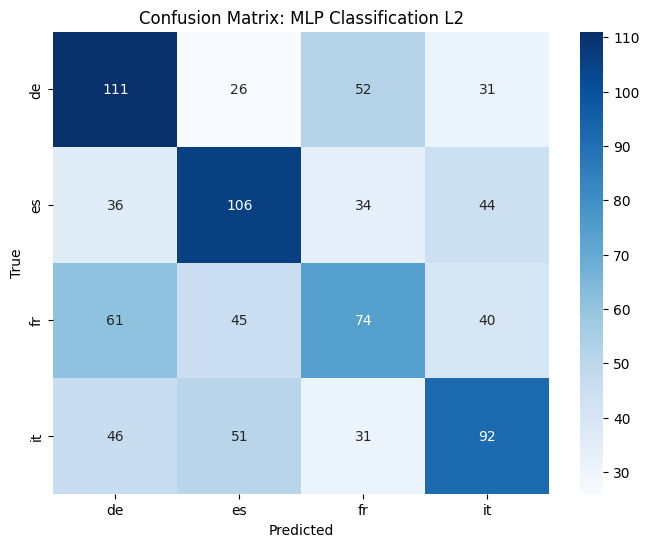

In [104]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

def run_nn(df, features, label_col="L1", title="Neural Network"):
    # -----------------------------
    # Prepare data
    # -----------------------------
    X = df[features].values
    y = df[label_col].values

    # -----------------------------
    # Label encode if needed
    # -----------------------------
    if y.dtype.kind in {'O', 'U', 'S'}:  # string/object
        le = LabelEncoder()
        y = le.fit_transform(y)

    # -----------------------------
    # Train-test split
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # -----------------------------
    # Scale features
    # -----------------------------
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # -----------------------------
    # Neural network
    # -----------------------------
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    mlp.fit(X_train_s, y_train)

    # -----------------------------
    # Predict on test set
    # -----------------------------
    y_pred = mlp.predict(X_test_s)

    # -----------------------------
    # Accuracy
    # -----------------------------
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
        # -----------------------------
    # Confusion Matrix with labels
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)

    # Map integer labels → language strings
    label_map = {0: "de", 1: "es", 2: "fr", 3: "it"}

    # The LabelEncoder may re-order classes, so use le.classes_
    # and convert them back to original coded labels
    classes = le.classes_                    # e.g. ["de","es","fr","it"]
    classes_int = le.transform(classes)      # e.g. [0,1,2,3]
    classes_str = [label_map[i] for i in classes_int]

    print("\nConfusion matrix:")
    print(cm)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes_str,
        yticklabels=classes_str
    )
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    return mlp, accuracy, cm

# Example usage:
features = df_L2.drop(columns=["L1", "dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_L2, features, label_col="L1", title="MLP Classification L2")



===== MLP Classification TR =====
Test Accuracy: 0.7891993629651078

Confusion matrix:
[[ 3839   309  1391    10]
 [  454  1366  1883    18]
 [  766   579 16570    10]
 [  197    52   155    29]]


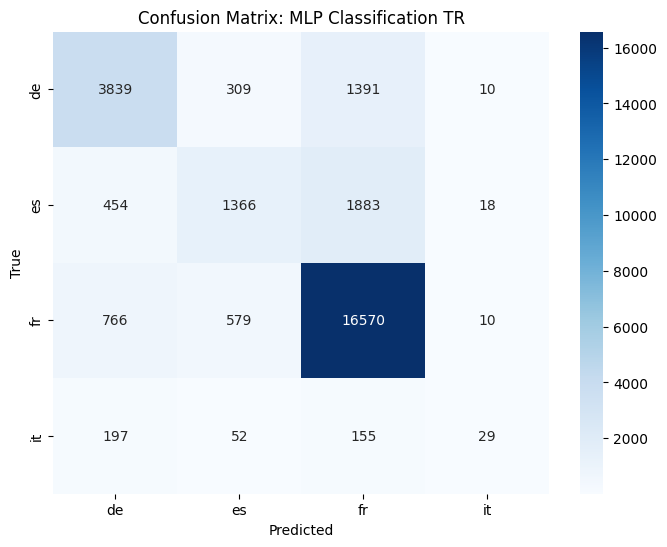

In [105]:

features_tr = df_TR.drop(columns=["L1", "dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_TR, features_tr, label_col="L1", title="MLP Classification TR")

### TR with Balanced data


===== MLP Classification TR =====
Test Accuracy: 0.6291810841983853

Confusion matrix:
[[198  65  52 119]
 [ 35 286  71  41]
 [ 29  78 295  32]
 [ 43  54  24 312]]


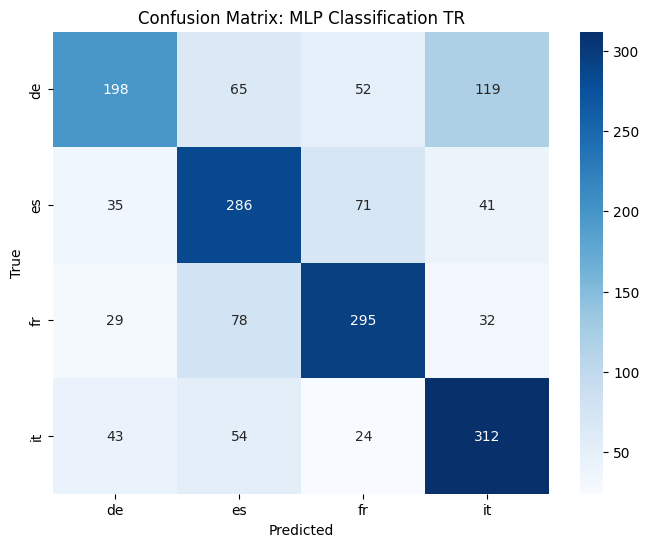

In [106]:

features_tr = df_TR_balanced.drop(columns=["L1", "dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_TR_balanced, features_tr, label_col="L1", title="MLP Classification TR")

## Kmeans with PCA

In [107]:
l2_map = {"TR":1, "L2":0}
df["dataset_name"] = df["dataset_name"].map(l2_map)


In [108]:
n_samples = 3267 #(1100 from L2, 2167 from TR - lowest value avaiable)

# Sample 2167 rows from each L1 class
df_balanced = df.groupby("L1").sample(n=n_samples, random_state=42)


to_drop = [c for c in ['L1','cluster','kmeans_labels'] if c in df_balanced.columns]
feature_cols = [c for c in df_balanced.columns if c not in to_drop]


X = df_balanced[feature_cols].values
y = df_balanced['L1'].values


scaler = StandardScaler()
X_s = scaler.fit_transform(X)


In [109]:
df_balanced

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,cluster
9804,1,0.000000,0.003115,0.0,0.857143,0.000000,0.071429,0.000000,0.0,0.142857,...,1.528169,0.023810,0.071429,0.184524,0.000000,0.220238,0.000000,0.000000,de,3
21491,1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.124581,0.098514,0.129547,0.027490,0.117948,0.018531,0.057606,de,2
12265,1,0.004193,0.014675,0.0,2.384615,0.000000,0.153846,0.000000,0.0,0.538462,...,1.920791,0.207692,0.000000,0.133333,0.156410,0.117949,0.038462,0.115385,de,1
5976,1,0.003484,0.000000,0.0,1.142857,0.000000,0.071429,0.000000,0.0,0.142857,...,1.799930,0.047619,0.085884,0.274660,0.000000,0.282313,0.000000,0.095238,de,0
16264,1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,1.125000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142326,1,0.005464,0.000000,0.0,0.571429,0.142857,0.285714,0.000000,0.0,0.428571,...,1.429625,0.071429,0.071429,0.142857,0.000000,0.107143,0.142857,0.178571,it,3
140746,1,0.014374,0.004107,0.0,0.428571,0.000000,0.500000,0.142857,0.0,0.357143,...,1.691200,0.178571,0.300000,0.050000,0.067857,0.050000,0.053571,0.085714,it,0
141084,1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,2
2301,0,0.043189,0.013289,0.0,1.333333,0.083333,0.666667,0.083333,0.0,1.250000,...,1.845675,0.194444,0.319444,0.125000,0.020833,0.055556,0.041667,0.159722,it,0


PCA variance retained: 0.9508706810742853

Cluster → Majority Label Mapping:
{np.int32(0): 'fr', np.int32(1): 'de', np.int32(2): 'it', np.int32(3): 'de'}

Overall accuracy (same data used for clustering): 0.39600550964187325

Classification Report:
              precision    recall  f1-score   support

          de     0.3607    0.6532    0.4648      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3376    0.5883    0.4290      3267
          it     0.7670    0.3425    0.4736      3267

    accuracy                         0.3960     13068
   macro avg     0.3663    0.3960    0.3418     13068
weighted avg     0.3663    0.3960    0.3418     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


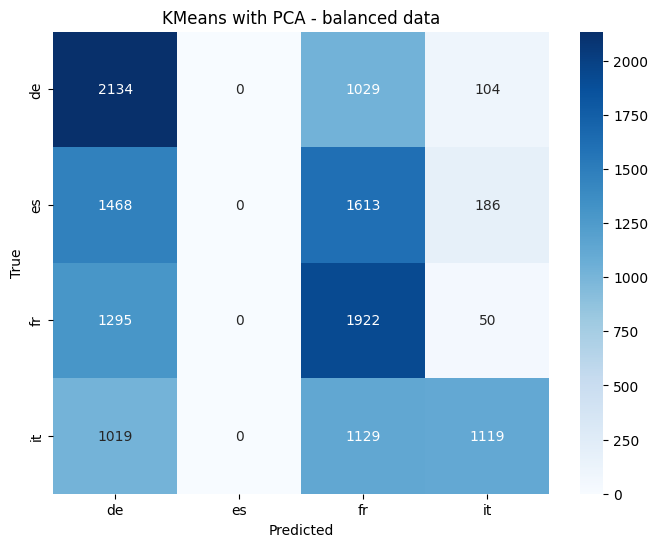


TP and FP per class:

      TP    FP
de  2134  3782
es     0     0
fr  1922  3771
it  1119   340


In [110]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# PCA
pca = PCA(n_components=0.95) #variance high keep only those features
X_p = pca.fit_transform(X_s)
print("PCA variance retained:", pca.explained_variance_ratio_.sum())

# KMeans on full PCA-transformed dataset
k = len(np.unique(y))
kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=20)
clusters = kmeans.fit_predict(X_p)

# Majority voting: cluster -> class label
cluster_to_label = {}
for cl in np.unique(clusters):
    mask = (clusters == cl)
    true_labels = y[mask]
    uniq, counts = np.unique(true_labels, return_counts=True)
    cluster_to_label[cl] = uniq[np.argmax(counts)]

print("\nCluster → Majority Label Mapping:")
print(cluster_to_label)

# Map clusters to predicted labels
y_pred = np.array([cluster_to_label[c] for c in clusters])

# 8) Evaluation
acc = np.mean(y_pred == y)
print("\nOverall accuracy (same data used for clustering):", acc)
print("\nClassification Report:")
print(classification_report(y, y_pred, digits=4))

# Confusion Matrix
labels_order = np.unique(y)
conf_mat = pd.crosstab(pd.Series(y, name='True'),
                       pd.Series(y_pred, name='Predicted'))
conf_mat = conf_mat.reindex(index=labels_order,
                            columns=labels_order, fill_value=0)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('KMeans with PCA - balanced data')
plt.show()

# TP / FP per class
tp_fp_df = pd.DataFrame(index=labels_order, columns=['TP','FP'])
for cls in labels_order:
    tp = conf_mat.loc[cls, cls]
    fp = conf_mat.loc[:, cls].sum() - tp
    tp_fp_df.loc[cls] = [int(tp), int(fp)]

print("\nTP and FP per class:\n")
print(tp_fp_df)


### TOP 10 features - balanced dataset

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 10 features used for clustering: ['dataset_name' 'ppron' 'attrib' 'pasttense' 'lexdens' 'numcls' 'nnargs'
 'mhd' 'aux:pass' 'nsubj:pass']

========== KMeans ==========

Cluster → Majority Label Mapping:
  Cluster 0 → de
  Cluster 1 → de
  Cluster 2 → fr
  Cluster 3 → it

Classification Report:
              precision    recall  f1-score   support

          de     0.3514    0.6296    0.4511      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3228    0.5718    0.4127      3267
          it     0.7754    0.3391    0.4719      3267

    accuracy                         0.3851     13068
   macro avg     0.3624    0.3851    0.3339     13068
weighted avg     0.3624    0.3851    0.3339     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


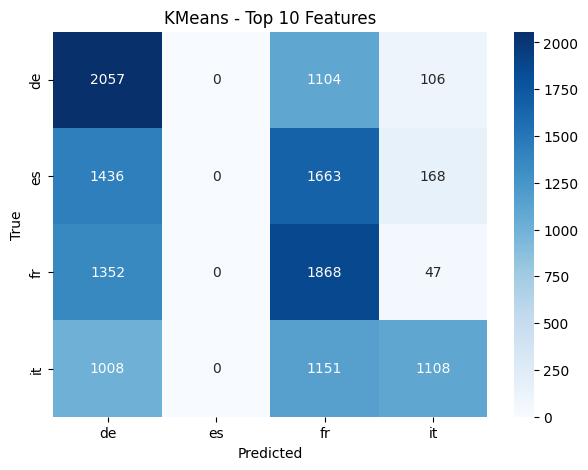


TP and FP per class:
       TP    FP
de  2057  3796
es     0     0
fr  1868  3918
it  1108   321

========== GMM ==========

Cluster → Majority Label Mapping:
  Cluster 0 → it
  Cluster 1 → de
  Cluster 2 → es
  Cluster 3 → fr

Classification Report:
              precision    recall  f1-score   support

          de     0.5158    0.1748    0.2611      3267
          es     0.3652    0.4530    0.4044      3267
          fr     0.3337    0.6636    0.4441      3267
          it     0.7790    0.3367    0.4702      3267

    accuracy                         0.4070     13068
   macro avg     0.4984    0.4070    0.3949     13068
weighted avg     0.4984    0.4070    0.3949     13068



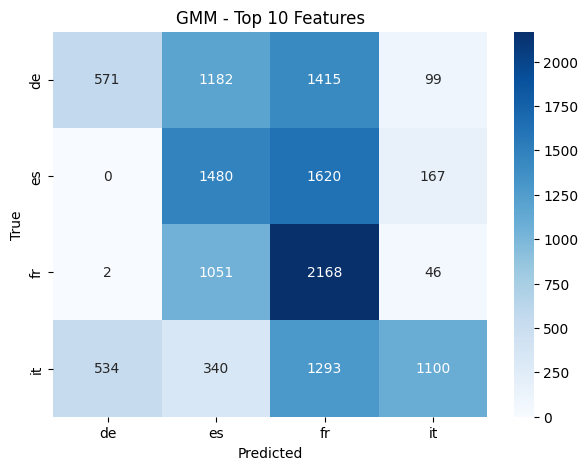


TP and FP per class:
       TP    FP
de   571   536
es  1480  2573
fr  2168  4328
it  1100   312


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



========== Spectral Clustering ==========

Cluster → Majority Label Mapping:
  Cluster 0 → de
  Cluster 1 → fr
  Cluster 2 → it
  Cluster 3 → de

Classification Report:
              precision    recall  f1-score   support

          de     0.5158    0.1748    0.2611      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3052    0.9853    0.4660      3267
          it     0.7779    0.3367    0.4700      3267

    accuracy                         0.3742     13068
   macro avg     0.3997    0.3742    0.2993     13068
weighted avg     0.3997    0.3742    0.2993     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


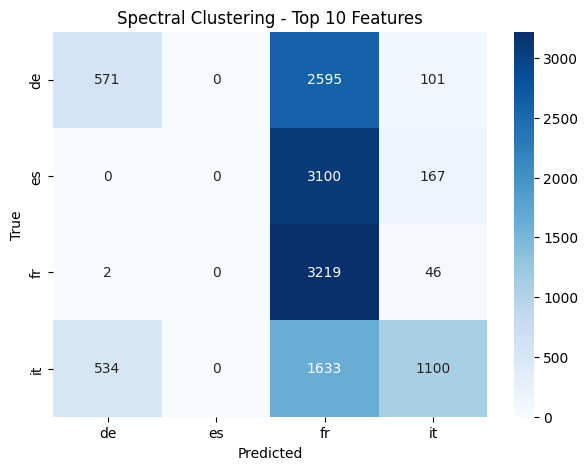


TP and FP per class:
       TP    FP
de   571   536
es     0     0
fr  3219  7328
it  1100   314


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



========== HDBSCAN ==========

Cluster → Majority Label Mapping:
  Cluster -1 → it
  Cluster 0 → it
  Cluster 1 → de
  Cluster 2 → fr
  Cluster 3 → de

Classification Report:
              precision    recall  f1-score   support

          de     0.5216    0.2029    0.2922      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3178    0.9755    0.4794      3267
          it     0.7179    0.3887    0.5044      3267

    accuracy                         0.3918     13068
   macro avg     0.3893    0.3918    0.3190     13068
weighted avg     0.3893    0.3918    0.3190     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


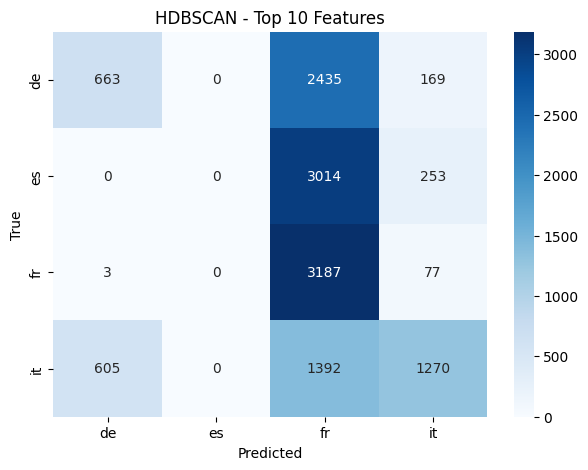


TP and FP per class:
       TP    FP
de   663   608
es     0     0
fr  3187  6841
it  1270   499


Predicted,de,es,fr,it
True,,,,
de,663,0,2435,169
es,0,0,3014,253
fr,3,0,3187,77
it,605,0,1392,1270


In [111]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
import hdbscan
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 0) Utility: evaluate clustering
# ------------------------------
def evaluate_clustering(y_true, clusters, method_name):
    labels = np.unique(y_true)
    # Map cluster -> majority label
    cluster_to_label = {}
    for c in np.unique(clusters):
        idx = np.where(clusters == c)[0]
        assigned_true = y_true[idx]
        if len(assigned_true) == 0:
            cluster_to_label[c] = labels[0]
        else:
            uniq, counts = np.unique(assigned_true, return_counts=True)
            cluster_to_label[c] = uniq[np.argmax(counts)]
    # Map clusters -> predicted labels
    y_pred = np.array([cluster_to_label[c] for c in clusters])
    # Confusion matrix
    conf_mat = pd.crosstab(pd.Series(y_true, name="True"),
                           pd.Series(y_pred, name="Predicted"))
    conf_mat = conf_mat.reindex(index=labels, columns=labels, fill_value=0)
    # Print results
    print(f"\n========== {method_name} ==========")
    print("\nCluster → Majority Label Mapping:")
    for c, lab in cluster_to_label.items():
        print(f"  Cluster {c} → {lab}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    # Plot confusion matrix
    plt.figure(figsize=(7,5))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{method_name} - Top 10 Features")
    plt.show()
    # TP / FP per class
    tp_fp_df = pd.DataFrame(index=labels, columns=['TP','FP'])
    for cls in labels:
        tp = conf_mat.loc[cls, cls]
        fp = conf_mat.loc[:, cls].sum() - tp
        tp_fp_df.loc[cls] = [int(tp), int(fp)]
    print("\nTP and FP per class:\n", tp_fp_df)
    return conf_mat

# ------------------------------
# 1) Scale full dataset
# ------------------------------
scaler = StandardScaler()
X_s = scaler.fit_transform(df_balanced[feature_cols].values)
y_balanced = df_balanced['L1'].values

# ------------------------------
# 2) Select Top 10 features (ANOVA F-test)
# ------------------------------
selector = SelectKBest(f_classif, k=10)
X_top10 = selector.fit_transform(X_s, y_balanced)
top_features = np.array(feature_cols)[selector.get_support()]
print("Top 10 features used for clustering:", top_features)

# ------------------------------
# 3) KMeans
# ------------------------------
k = len(np.unique(y_balanced))
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters_km = kmeans.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_km, "KMeans")

# ------------------------------
# 4) Gaussian Mixture Model (GMM)
# ------------------------------
gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
clusters_gmm = gmm.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_gmm, "GMM")

# ------------------------------
# 5) Spectral Clustering
# ------------------------------
spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
clusters_spectral = spectral.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_spectral, "Spectral Clustering")

# ------------------------------
# 6) HDBSCAN Clustering
# ------------------------------
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom')
clusters_hdb = clusterer.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_hdb, "HDBSCAN")


### Top 20 features Balanced Dataset

Top 20 features used for clustering: ['dataset_name' 'ppron' 'cconj' 'relativ' 'copula' 'attrib' 'pasttense'
 'lexdens' 'lexTTR' 'pverbals' 'longpassives' 'epist' 'neg' 'numcls'
 'nnargs' 'mhd' 'mdd' 'aux:pass' 'nsubj:pass' 'L1_num']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



========== KMeans ==========

Cluster → Majority Label Mapping:
  Cluster 0 → fr
  Cluster 1 → de
  Cluster 2 → it
  Cluster 3 → de

Classification Report:
              precision    recall  f1-score   support

          de     0.3601    0.6593    0.4658      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3403    0.5859    0.4305      3267
          it     0.7818    0.3499    0.4834      3267

    accuracy                         0.3988     13068
   macro avg     0.3706    0.3988    0.3449     13068
weighted avg     0.3706    0.3988    0.3449     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


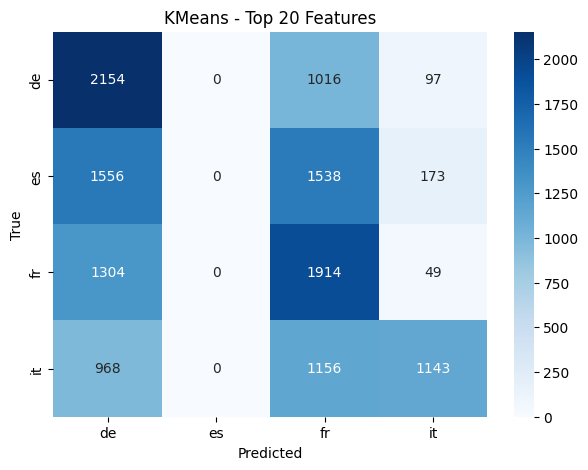


TP and FP per class:
       TP    FP
de  2154  3828
es     0     0
fr  1914  3710
it  1143   319

========== GMM ==========

Cluster → Majority Label Mapping:
  Cluster 0 → it
  Cluster 1 → fr
  Cluster 2 → de
  Cluster 3 → it

Classification Report:
              precision    recall  f1-score   support

          de     0.5158    0.1748    0.2611      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3494    0.8672    0.4981      3267
          it     0.5472    0.6452    0.5922      3267

    accuracy                         0.4218     13068
   macro avg     0.3531    0.4218    0.3378     13068
weighted avg     0.3531    0.4218    0.3378     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


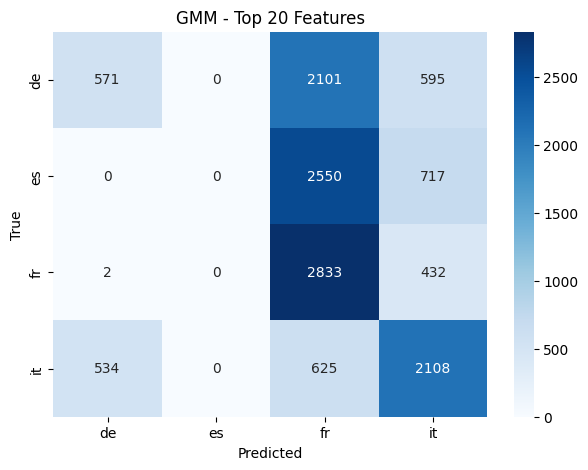


TP and FP per class:
       TP    FP
de   571   536
es     0     0
fr  2833  5276
it  2108  1744


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



========== Spectral Clustering ==========

Cluster → Majority Label Mapping:
  Cluster 0 → it
  Cluster 1 → es
  Cluster 2 → de
  Cluster 3 → de

Classification Report:
              precision    recall  f1-score   support

          de     1.0000    0.1748    0.2976      3267
          es     0.2731    1.0000    0.4291      3267
          fr     0.0000    0.0000    0.0000      3267
          it     0.9963    0.1635    0.2808      3267

    accuracy                         0.3346     13068
   macro avg     0.5674    0.3346    0.2519     13068
weighted avg     0.5674    0.3346    0.2519     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


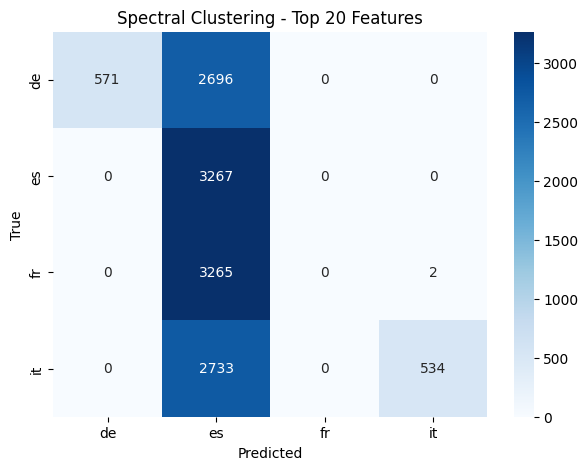


TP and FP per class:
       TP    FP
de   571     0
es  3267  8694
fr     0     0
it   534     2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



========== HDBSCAN ==========

Cluster → Majority Label Mapping:
  Cluster -1 → it
  Cluster 0 → de
  Cluster 1 → it
  Cluster 2 → it
  Cluster 3 → fr
  Cluster 4 → de

Classification Report:
              precision    recall  f1-score   support

          de     1.0000    0.1843    0.3112      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3482    0.9213    0.5054      3267
          it     0.6723    0.7863    0.7249      3267

    accuracy                         0.4730     13068
   macro avg     0.5051    0.4730    0.3854     13068
weighted avg     0.5051    0.4730    0.3854     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


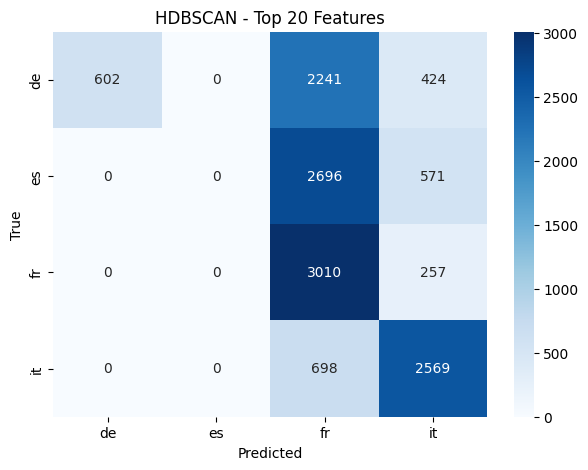


TP and FP per class:
       TP    FP
de   602     0
es     0     0
fr  3010  5635
it  2569  1252


Predicted,de,es,fr,it
True,,,,
de,602,0,2241,424
es,0,0,2696,571
fr,0,0,3010,257
it,0,0,698,2569


In [46]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
import hdbscan
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 0) Utility: evaluate clustering
# ------------------------------
def evaluate_clustering(y_true, clusters, method_name):
    labels = np.unique(y_true)
    # Map cluster -> majority label
    cluster_to_label = {}
    for c in np.unique(clusters):
        idx = np.where(clusters == c)[0]
        assigned_true = y_true[idx]
        if len(assigned_true) == 0:
            cluster_to_label[c] = labels[0]
        else:
            uniq, counts = np.unique(assigned_true, return_counts=True)
            cluster_to_label[c] = uniq[np.argmax(counts)]
    # Map clusters -> predicted labels
    y_pred = np.array([cluster_to_label[c] for c in clusters])
    # Confusion matrix
    conf_mat = pd.crosstab(pd.Series(y_true, name="True"),
                           pd.Series(y_pred, name="Predicted"))
    conf_mat = conf_mat.reindex(index=labels, columns=labels, fill_value=0)
    # Print results
    print(f"\n========== {method_name} ==========")
    print("\nCluster → Majority Label Mapping:")
    for c, lab in cluster_to_label.items():
        print(f"  Cluster {c} → {lab}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    # Plot confusion matrix
    plt.figure(figsize=(7,5))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{method_name} - Top 20 Features")
    plt.show()
    # TP / FP per class
    tp_fp_df = pd.DataFrame(index=labels, columns=['TP','FP'])
    for cls in labels:
        tp = conf_mat.loc[cls, cls]
        fp = conf_mat.loc[:, cls].sum() - tp
        tp_fp_df.loc[cls] = [int(tp), int(fp)]
    print("\nTP and FP per class:\n", tp_fp_df)
    return conf_mat

# ------------------------------
# 1) Scale full dataset
# ------------------------------
scaler = StandardScaler()
X_s = scaler.fit_transform(df_balanced[feature_cols].values)
y_balanced = df_balanced['L1'].values


# ------------------------------
# 2) Select Top 20 features (ANOVA F-test)
# ------------------------------
selector = SelectKBest(f_classif, k=20)
X_top20 = selector.fit_transform(X_s, y_balanced)
top_features = np.array(feature_cols)[selector.get_support()]
print("Top 20 features used for clustering:", top_features)

# ------------------------------
# 3) KMeans
# ------------------------------
k = len(np.unique(y_balanced))
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters_km = kmeans.fit_predict(X_top20)
evaluate_clustering(y_balanced, clusters_km, "KMeans")

# ------------------------------
# 4) Gaussian Mixture Model (GMM)
# ------------------------------
gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
clusters_gmm = gmm.fit_predict(X_top20)
evaluate_clustering(y_balanced, clusters_gmm, "GMM")

# ------------------------------
# 5) Spectral Clustering
# ------------------------------
spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
clusters_spectral = spectral.fit_predict(X_top20)
evaluate_clustering(y_balanced, clusters_spectral, "Spectral Clustering")

# ------------------------------
# 6) HDBSCAN Clustering
# ------------------------------
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom')
clusters_hdb = clusterer.fit_predict(X_top20)
evaluate_clustering(y_balanced, clusters_hdb, "HDBSCAN")


## Top feature selection with random forest

Text(0.5, 1.0, 'Top 20 Feature Importances')

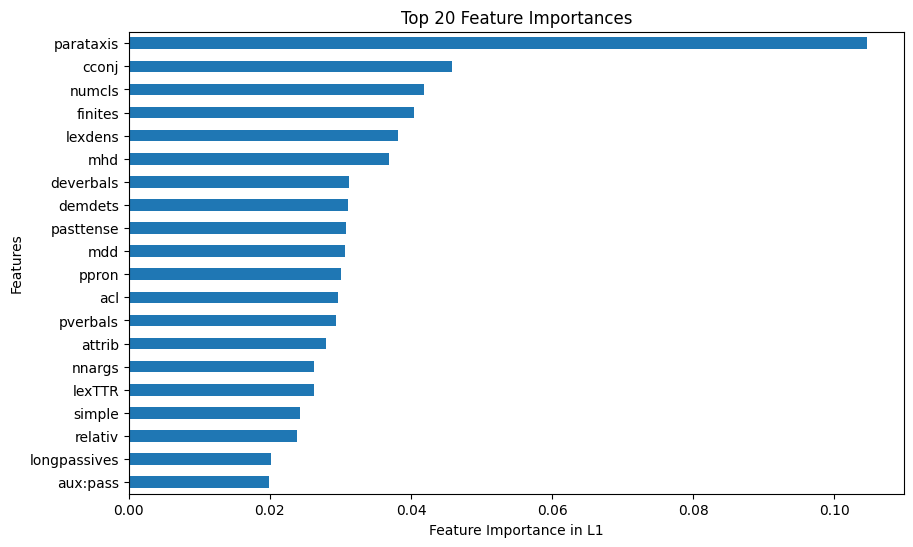

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[num_cols], df['L1'], stratify=df['L1'])
rf = RandomForestClassifier(n_estimators=200).fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
top_features = importances.head(20)[::-1]# reverses the top 20 features for correct horizontal orientation

ax = top_features.plot.barh(figsize=(10,6))
ax.set_xlabel("Feature Importance in L1")
ax.set_ylabel("Features")
ax.set_title("Top 20 Feature Importances")

#### Top 10 features

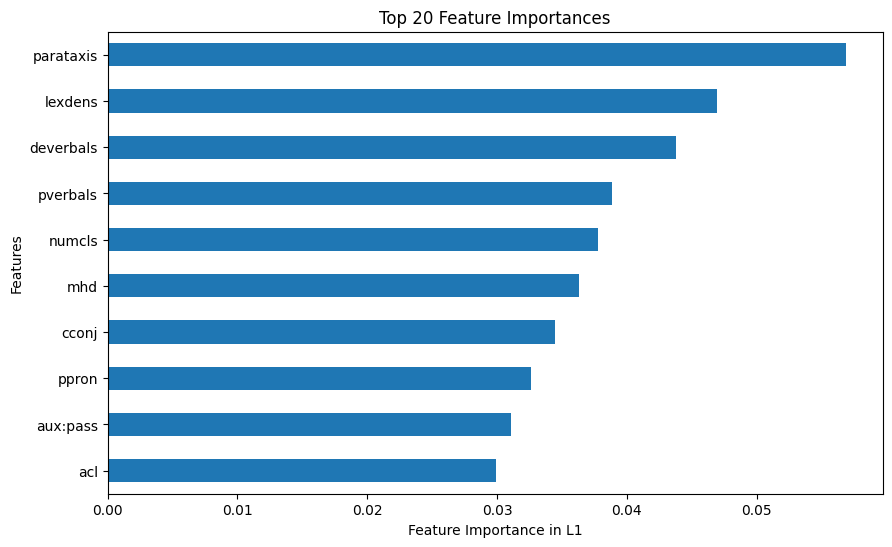

Clustering Accuracy: 0.0990205081114172


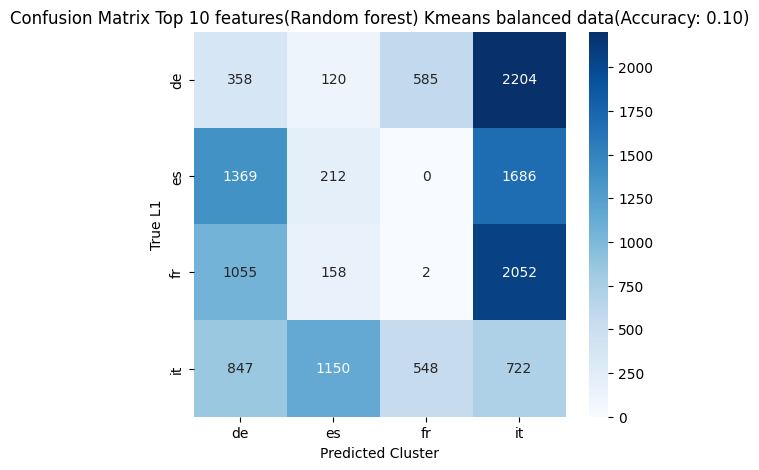

In [49]:
# Features and target
X = df_balanced[num_cols]
y = df_balanced['L1']

# Train-test split (stratified to keep balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
top_features = importances.head(10)[::-1]  # reversed for horizontal bar plot

# Plot
ax = top_features.plot.barh(figsize=(10,6))
ax.set_xlabel("Feature Importance in L1")
ax.set_ylabel("Features")
ax.set_title("Top 20 Feature Importances")
plt.show()

selected_features = top_features.index.tolist()
X_kmeans = df_balanced[selected_features].values

# Standardize features before clustering
X_scaled = StandardScaler().fit_transform(X_kmeans)

# KMeans (for example, k=4 for 4 languages)
kmeans = KMeans(n_clusters=4, random_state=42)
df_balanced['cluster'] = kmeans.fit_predict(X_scaled)


# Map L1 to integers if not done already
l1_map = {"de":0, "es":1, "fr":2, "it":3}
df_balanced['L1_num'] = df_balanced['L1'].map(l1_map)

y_true = df_balanced['L1_num'].values
y_pred = df_balanced['cluster'].values

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Clustering Accuracy:", acc)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['de','es','fr','it'],
            yticklabels=['de','es','fr','it'])
plt.xlabel('Predicted Cluster')
plt.ylabel('True L1')
plt.title(f'Confusion Matrix Top 10 features(Random forest) Kmeans balanced data(Accuracy: {acc:.2f})')
plt.show()



##### Top 20 features

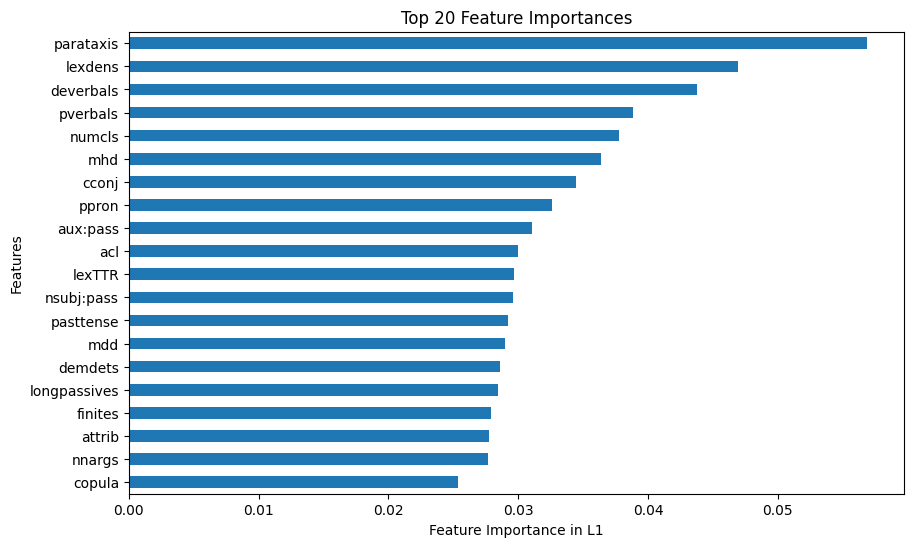

Clustering Accuracy: 0.2369146005509642


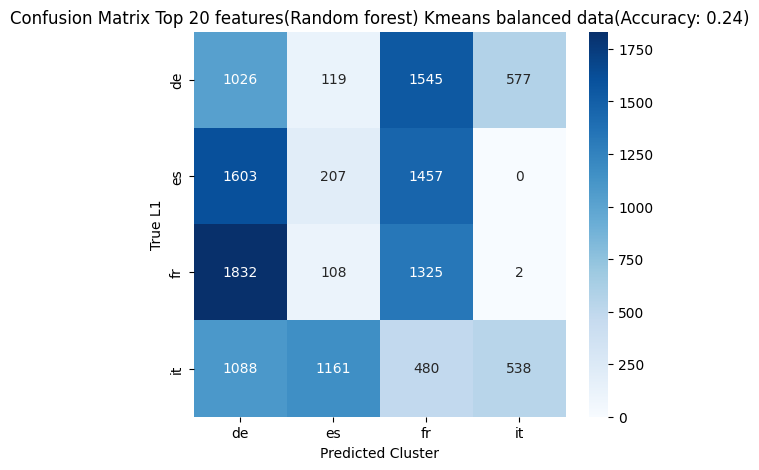

In [50]:
# Features and target
X = df_balanced[num_cols]
y = df_balanced['L1']

# Train-test split (stratified to keep balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
top_features = importances.head(20)[::-1]  # reversed for horizontal bar plot

# Plot
ax = top_features.plot.barh(figsize=(10,6))
ax.set_xlabel("Feature Importance in L1")
ax.set_ylabel("Features")
ax.set_title("Top 20 Feature Importances")
plt.show()

selected_features = top_features.index.tolist()
X_kmeans = df_balanced[selected_features].values

# Standardize features before clustering
X_scaled = StandardScaler().fit_transform(X_kmeans)

# KMeans (for example, k=4 for 4 languages)
kmeans = KMeans(n_clusters=4, random_state=42)
df_balanced['cluster'] = kmeans.fit_predict(X_scaled)


# Map L1 to integers if not done already
l1_map = {"de":0, "es":1, "fr":2, "it":3}
df_balanced['L1_num'] = df_balanced['L1'].map(l1_map)

y_true = df_balanced['L1_num'].values
y_pred = df_balanced['cluster'].values

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Clustering Accuracy:", acc)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['de','es','fr','it'],
            yticklabels=['de','es','fr','it'])
plt.xlabel('Predicted Cluster')
plt.ylabel('True L1')
plt.title(f'Confusion Matrix Top 20 features(Random forest) Kmeans balanced data(Accuracy: {acc:.2f})')
plt.show()



PCA variance retained: 0.9522427906133222

Cluster → Majority Label Mapping:
{np.int32(0): 'de', np.int32(1): 'de', np.int32(2): 'it', np.int32(3): 'fr'}

Overall accuracy (same data used for clustering): 0.42500765228037957

Classification Report:
              precision    recall  f1-score   support

          de     0.4040    0.8212    0.5416      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3510    0.5344    0.4237      3267
          it     0.7748    0.3444    0.4768      3267

    accuracy                         0.4250     13068
   macro avg     0.3824    0.4250    0.3605     13068
weighted avg     0.3824    0.4250    0.3605     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


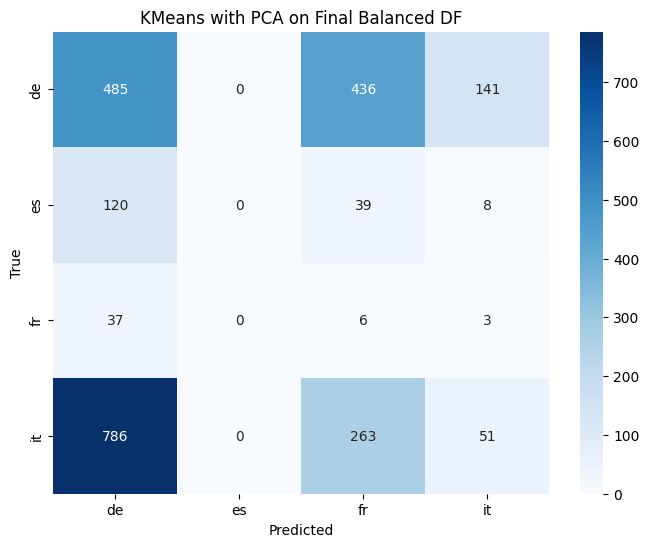


TP and FP per class:

     TP   FP
de  485  943
es    0    0
fr    6  738
it   51  152


In [51]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=0.95)  # retain 95% variance
X_p = pca.fit_transform(X_s)
print("PCA variance retained:", pca.explained_variance_ratio_.sum())

# -----------------------------
# KMeans on PCA-transformed data
# -----------------------------
k = len(np.unique(y))
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_p)

# -----------------------------
# Map clusters to majority class label
# -----------------------------
cluster_to_label = {}
for cl in np.unique(clusters):
    mask = (clusters == cl)
    true_labels = y[mask]
    uniq, counts = np.unique(true_labels, return_counts=True)
    cluster_to_label[cl] = uniq[np.argmax(counts)]

print("\nCluster → Majority Label Mapping:")
print(cluster_to_label)

# Map clusters to predicted labels
y_pred = np.array([cluster_to_label[c] for c in clusters])

# -----------------------------
# Evaluation
# -----------------------------
acc = np.mean(y_pred == y)
print("\nOverall accuracy (same data used for clustering):", acc)
print("\nClassification Report:")
print(classification_report(y, y_pred, digits=4))

# -----------------------------
# Confusion Matrix
# -----------------------------
labels_order = np.unique(y)
conf_mat = pd.crosstab(pd.Series(y, name='True'),
                       pd.Series(y_pred, name='Predicted'))
conf_mat = conf_mat.reindex(index=labels_order, columns=labels_order, fill_value=0)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('KMeans with PCA on Final Balanced DF')
plt.show()

# -----------------------------
# TP / FP per class
# -----------------------------
tp_fp_df = pd.DataFrame(index=labels_order, columns=['TP','FP'])
for cls in labels_order:
    tp = conf_mat.loc[cls, cls]
    fp = conf_mat.loc[:, cls].sum() - tp
    tp_fp_df.loc[cls] = [int(tp), int(fp)]

print("\nTP and FP per class:\n")
print(tp_fp_df)


### PCA

Top 10 features used for clustering: ['dataset_name' 'ppron' 'pasttense' 'lexdens' 'numcls' 'nnargs' 'mhd'
 'aux:pass' 'nsubj:pass' 'L1_num']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



========== KMeans ==========

Cluster → Majority Label Mapping:
  Cluster 0 → de
  Cluster 1 → fr
  Cluster 2 → de
  Cluster 3 → it

Classification Report:
              precision    recall  f1-score   support

          de     0.3792    0.6860    0.4884      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3418    0.5996    0.4354      3267
          it     0.7791    0.3401    0.4735      3267

    accuracy                         0.4064     13068
   macro avg     0.3750    0.4064    0.3493     13068
weighted avg     0.3750    0.4064    0.3493     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


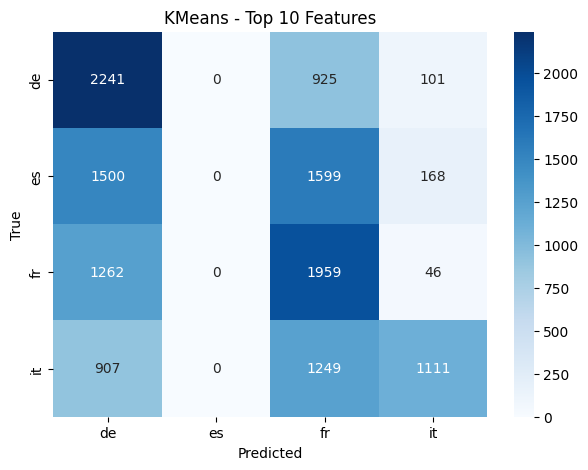


TP and FP per class:
       TP    FP
de  2241  3669
es     0     0
fr  1959  3773
it  1111   315

========== GMM ==========

Cluster → Majority Label Mapping:
  Cluster 0 → es
  Cluster 1 → fr
  Cluster 2 → de
  Cluster 3 → it

Classification Report:
              precision    recall  f1-score   support

          de     0.5158    0.1748    0.2611      3267
          es     0.3652    0.4530    0.4044      3267
          fr     0.3337    0.6636    0.4441      3267
          it     0.7790    0.3367    0.4702      3267

    accuracy                         0.4070     13068
   macro avg     0.4984    0.4070    0.3949     13068
weighted avg     0.4984    0.4070    0.3949     13068



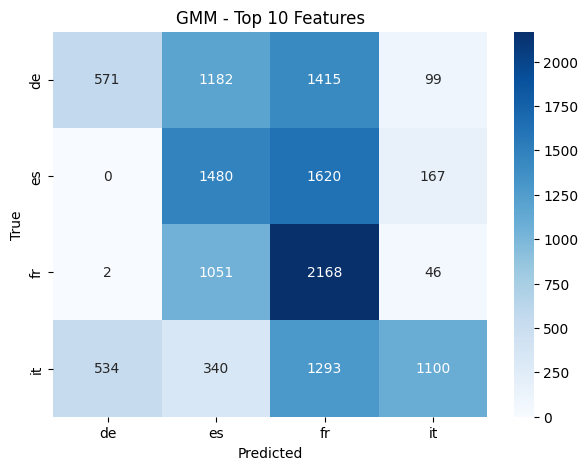


TP and FP per class:
       TP    FP
de   571   536
es  1480  2573
fr  2168  4328
it  1100   312


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



========== Spectral Clustering ==========

Cluster → Majority Label Mapping:
  Cluster 0 → it
  Cluster 1 → fr
  Cluster 2 → it
  Cluster 3 → de

Classification Report:
              precision    recall  f1-score   support

          de     1.0000    0.2039    0.3387      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3080    0.9853    0.4693      3267
          it     0.8379    0.5002    0.6264      3267

    accuracy                         0.4223     13068
   macro avg     0.5365    0.4223    0.3586     13068
weighted avg     0.5365    0.4223    0.3586     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


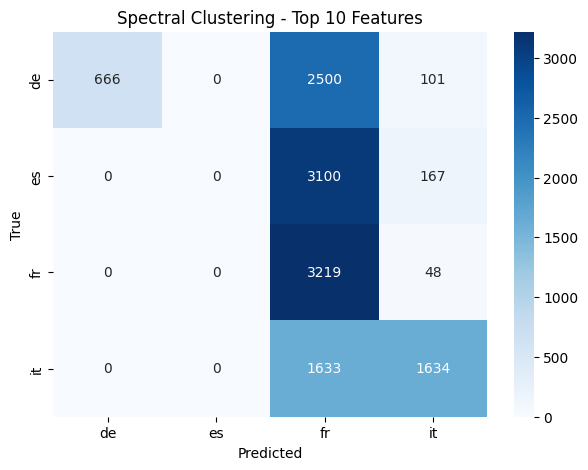


TP and FP per class:
       TP    FP
de   666     0
es     0     0
fr  3219  7233
it  1634   316


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



========== HDBSCAN ==========

Cluster → Majority Label Mapping:
  Cluster -1 → it
  Cluster 0 → it
  Cluster 1 → de
  Cluster 2 → it
  Cluster 3 → fr
  Cluster 4 → de
  Cluster 5 → it

Classification Report:
              precision    recall  f1-score   support

          de     1.0000    0.1974    0.3298      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3159    0.9819    0.4780      3267
          it     0.8073    0.5605    0.6616      3267

    accuracy                         0.4350     13068
   macro avg     0.5308    0.4350    0.3673     13068
weighted avg     0.5308    0.4350    0.3673     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


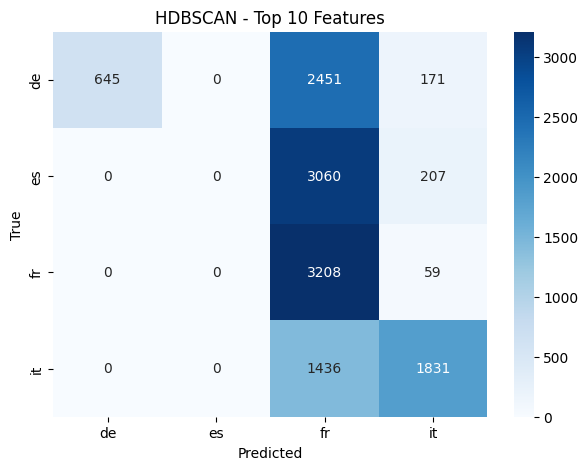


TP and FP per class:
       TP    FP
de   645     0
es     0     0
fr  3208  6947
it  1831   437


Predicted,de,es,fr,it
True,,,,
de,645,0,2451,171
es,0,0,3060,207
fr,0,0,3208,59
it,0,0,1436,1831


In [52]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
import hdbscan
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 0) Utility: evaluate clustering
# ------------------------------
def evaluate_clustering(y_true, clusters, method_name):
    labels = np.unique(y_true)
    # Map cluster -> majority label
    cluster_to_label = {}
    for c in np.unique(clusters):
        idx = np.where(clusters == c)[0]
        assigned_true = y_true[idx]
        if len(assigned_true) == 0:
            cluster_to_label[c] = labels[0]
        else:
            uniq, counts = np.unique(assigned_true, return_counts=True)
            cluster_to_label[c] = uniq[np.argmax(counts)]
    # Map clusters -> predicted labels
    y_pred = np.array([cluster_to_label[c] for c in clusters])
    # Confusion matrix
    conf_mat = pd.crosstab(pd.Series(y_true, name="True"),
                           pd.Series(y_pred, name="Predicted"))
    conf_mat = conf_mat.reindex(index=labels, columns=labels, fill_value=0)
    # Print results
    print(f"\n========== {method_name} ==========")
    print("\nCluster → Majority Label Mapping:")
    for c, lab in cluster_to_label.items():
        print(f"  Cluster {c} → {lab}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    # Plot confusion matrix
    plt.figure(figsize=(7,5))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{method_name} - Top 10 Features")
    plt.show()
    # TP / FP per class
    tp_fp_df = pd.DataFrame(index=labels, columns=['TP','FP'])
    for cls in labels:
        tp = conf_mat.loc[cls, cls]
        fp = conf_mat.loc[:, cls].sum() - tp
        tp_fp_df.loc[cls] = [int(tp), int(fp)]
    print("\nTP and FP per class:\n", tp_fp_df)
    return conf_mat

# ------------------------------
# 2) Select Top 10 features (ANOVA F-test)
# ------------------------------
selector = SelectKBest(f_classif, k=10)
X_top10 = selector.fit_transform(X_s, y_balanced)
top_features = np.array(feature_cols)[selector.get_support()]
print("Top 10 features used for clustering:", top_features)

# ------------------------------
# 3) KMeans
# ------------------------------
k = len(np.unique(y_balanced))
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters_km = kmeans.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_km, "KMeans")

# ------------------------------
# 4) Gaussian Mixture Model (GMM)
# ------------------------------
gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
clusters_gmm = gmm.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_gmm, "GMM")

# ------------------------------
# 5) Spectral Clustering
# ------------------------------
spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
clusters_spectral = spectral.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_spectral, "Spectral Clustering")

# ------------------------------
# 6) HDBSCAN Clustering
# ------------------------------
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom')
clusters_hdb = clusterer.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_hdb, "HDBSCAN")


#

# Trying other clustering methods

##NN

#### NN - K=4

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Neural Network Test Accuracy: 0.613618974751339

Classification Report:
               precision    recall  f1-score   support

          de     0.5685    0.6407    0.6024       654
          es     0.5318    0.5375    0.5347       653
          fr     0.6794    0.6804    0.6799       654
          it     0.6922    0.5957    0.6403       653

    accuracy                         0.6136      2614
   macro avg     0.6180    0.6136    0.6143      2614
weighted avg     0.6180    0.6136    0.6144      2614



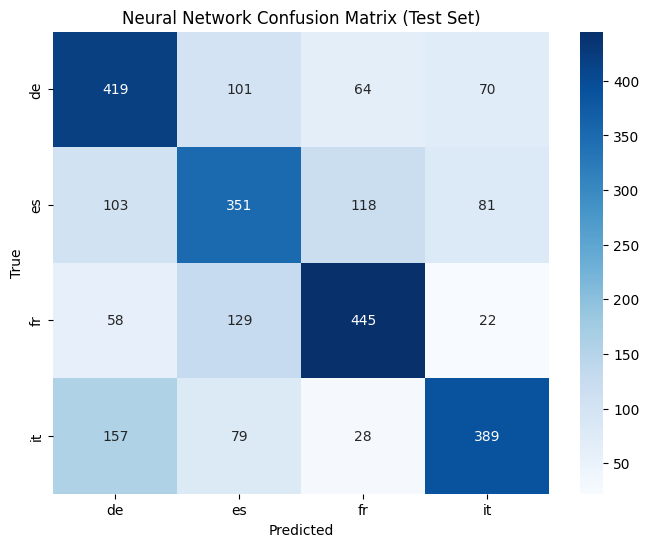

In [112]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp


# Train-test split (stratify ensures class balance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (fit on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


# Ensure X is dense float64
def to_dense_float(a):
    if sp.issparse(a):
        a = a.toarray()
    return np.asarray(a, dtype=np.float64)

X_train_s = to_dense_float(X_train_s)
X_test_s  = to_dense_float(X_test_s)

# Ensure y is a plain 1D array (not sparse, not weird dtype)
y_train = np.asarray(y_train)
y_test  = np.asarray(y_test)

# Neural network
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    early_stopping=False, validation_fraction=0.1,
    activation='relu',
    solver='adam',
    max_iter=200,  # can increase for convergence
    random_state=42
)
mlp.fit(X_train_s, y_train)

# Predict on test set
y_pred = mlp.predict(X_test_s)

# Evaluation
acc = np.mean(y_pred == y_test)
print("\nNeural Network Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion matrix
labels_order = np.unique(y_test)
conf_mat = confusion_matrix(y_test, y_pred, labels=labels_order)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title("Neural Network Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


#### NN - K=2

In [54]:
df_balanced

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,L1_num,cluster
9804,1,0.000000,0.003115,0.0,0.857143,0.000000,0.071429,0.000000,0.0,0.142857,...,0.023810,0.071429,0.184524,0.000000,0.220238,0.000000,0.000000,de,0,2
21491,1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.124581,0.098514,0.129547,0.027490,0.117948,0.018531,0.057606,de,0,3
12265,1,0.004193,0.014675,0.0,2.384615,0.000000,0.153846,0.000000,0.0,0.538462,...,0.207692,0.000000,0.133333,0.156410,0.117949,0.038462,0.115385,de,0,0
5976,1,0.003484,0.000000,0.0,1.142857,0.000000,0.071429,0.000000,0.0,0.142857,...,0.047619,0.085884,0.274660,0.000000,0.282313,0.000000,0.095238,de,0,2
16264,1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142326,1,0.005464,0.000000,0.0,0.571429,0.142857,0.285714,0.000000,0.0,0.428571,...,0.071429,0.071429,0.142857,0.000000,0.107143,0.142857,0.178571,it,3,0
140746,1,0.014374,0.004107,0.0,0.428571,0.000000,0.500000,0.142857,0.0,0.357143,...,0.178571,0.300000,0.050000,0.067857,0.050000,0.053571,0.085714,it,3,0
141084,1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,3,3
2301,0,0.043189,0.013289,0.0,1.333333,0.083333,0.666667,0.083333,0.0,1.250000,...,0.194444,0.319444,0.125000,0.020833,0.055556,0.041667,0.159722,it,3,1


#balanced data NN2

In [113]:
import pandas as pd

df_L2 = df[df['dataset_name'] == 0]
df_other = df[df['dataset_name'] != 0]

df_other_downsampled = df_other.sample(n=len(df_L2), random_state=42)

df_balanced = pd.concat([df_L2, df_other_downsampled], ignore_index=True)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['dataset_name'].value_counts())

# define mapping
l1_map = {
    "de": 0,
    "es": 1,
    "fr": 2,
    "it": 3
}

# apply mapping
df_balanced["L1_num"] = df_balanced["L1"].map(l1_map)



dataset_name
0    4400
1    4400
Name: count, dtype: int64


In [114]:
df_balanced

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,cluster,L1_num
0,0,0.019544,0.009772,0.003257,0.615385,0.076923,0.307692,0.000000,0.0,0.692308,...,0.217949,0.230769,0.076923,0.089744,0.051282,0.000000,0.179487,es,0,1
1,0,0.065934,0.013736,0.000000,0.666667,0.000000,0.277778,0.000000,0.0,0.666667,...,0.013889,0.370370,0.009259,0.120370,0.009259,0.055556,0.254630,it,0,3
2,1,0.032258,0.012903,0.000000,0.285714,0.142857,0.000000,0.000000,0.0,0.142857,...,0.285714,0.047619,0.047619,0.000000,0.047619,0.238095,0.047619,fr,0,2
3,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de,2,0
4,0,0.059783,0.013587,0.005435,0.454545,0.136364,0.272727,0.000000,0.0,0.500000,...,0.136364,0.413636,0.000000,0.054545,0.000000,0.037879,0.266667,fr,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8795,1,0.016393,0.010929,0.000000,1.500000,0.000000,0.000000,0.000000,0.0,0.333333,...,0.000000,0.055556,0.277778,0.166667,0.277778,0.000000,0.055556,es,3,1
8796,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de,2,0
8797,1,0.020906,0.006969,0.000000,0.400000,0.000000,0.000000,0.000000,0.0,0.400000,...,0.316667,0.115000,0.075000,0.100000,0.058333,0.025000,0.110000,fr,3,2
8798,0,0.030726,0.005587,0.002793,0.450000,0.000000,0.200000,0.000000,0.0,0.250000,...,0.145833,0.261667,0.065833,0.041667,0.055833,0.008333,0.220833,es,0,1



Neural Network Test Accuracy: 0.9897727272727272

Classification Report:
               precision    recall  f1-score   support

           0     0.9865    0.9932    0.9898       880
           1     0.9931    0.9864    0.9897       880

    accuracy                         0.9898      1760
   macro avg     0.9898    0.9898    0.9898      1760
weighted avg     0.9898    0.9898    0.9898      1760



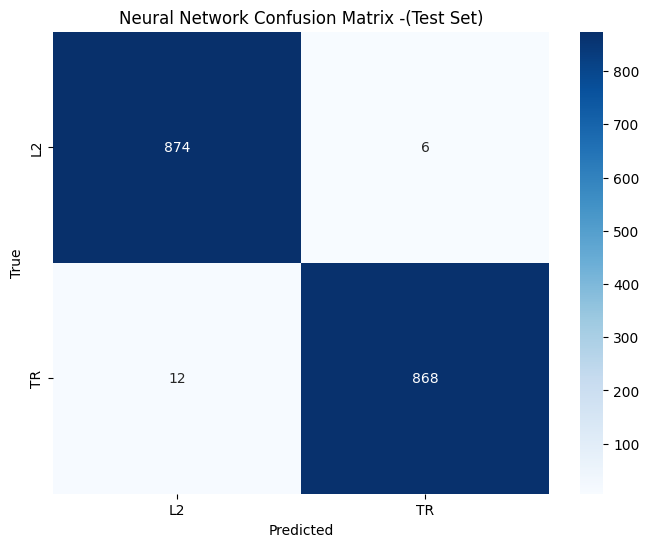

In [115]:
# Features and target
to_drop = [c for c in ['dataset_name','cluster','kmeans_labels','L1'] if c in df.columns]
feature_cols = [c for c in df.columns if c not in to_drop]

# Features and target
X = df_balanced[feature_cols]
y = df_balanced['dataset_name']

# Train-test split (stratified to keep balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Train-test split (stratify ensures class balance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (fit on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Neural network
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    early_stopping=True, validation_fraction=0.1,
    activation='relu',
    solver='adam',
    max_iter=200,  # can increase for convergence
    random_state=42
)
mlp.fit(X_train_s, y_train)

# Predict on test set
y_pred = mlp.predict(X_test_s)

# Evaluation
acc = np.mean(y_pred == y_test)
print("\nNeural Network Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion matrix
labels_order = np.unique(y_test)
conf_mat = confusion_matrix(y_test, y_pred, labels=labels_order)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=["L2", "TR"],
            yticklabels=["L2", "TR"])
plt.title("Neural Network Confusion Matrix -(Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
